# Final Paper Plots

In [1]:
import glob
import matplotlib.pyplot as plt
import sys
import xarray as xr
import numpy as np
import pandas as pd
import re
from matplotlib.lines import Line2D
import os
from matplotlib import cm
import matplotlib.patches as mpatches
from matplotlib import ticker
from matplotlib.path import Path
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
import matplotlib.gridspec as gridspec
import csv

sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/LRT/')
import LRT_fxnlib as LRTlib

plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams['font.family'] = 'FreeSerif'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'FreeSerif'
plt.rcParams['mathtext.it'] = 'FreeSerif:italic'
plt.rcParams['mathtext.bf'] = 'FreeSerif:bold'

temp_groups = ['205', '218', '225']
color_map = {
    '205': 'gray',
    '218': 'red',
    '225': 'green'
}

rho_ice = 917.0  # kg/m^3, used for CoCiP mass calculation
model_colors = {"APCEMM": "tab:blue", "LES": "tab:orange", "CoCiP": "tab:green"}
rh_styles = {110: "--", 130: "-"}

In [2]:
def get_apcemm_sauter_reff_um(ds, idx):
    n = np.asarray(ds["Overall size distribution"][idx]).squeeze().astype(float)
    r_e = np.asarray(ds["r_e"][idx]).squeeze().astype(float)

    if r_e.size == n.size + 1:
        r_mid = 0.5 * (r_e[:-1] + r_e[1:])
    else:
        r_mid = r_e[:n.size]

    den = np.sum(n * r_mid**2)
    if den <= 0:
        return np.nan
    return (np.sum(n * r_mid**3) / den) * 1e6  # um

# Import LES, APCEMM, and CoCiP datasets

In [3]:
test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']
hours = [0, 12]
habits = ['ghm', 'solid-column', 'rough-aggregate']
base_dir = '/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results'

# APCEMM
apcemm_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/APCEMM/ef_final/{tid}/APCEMM_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

apcemm_default_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/APCEMM/default_settings/{tid}/APCEMM_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# CoCiP
cocip_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/CoCiP/{tid}/CoCiP_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

# LES
les_data = {
    (tid, hour, habit): xr.open_dataset(f'{base_dir}/LES/ef_final/{tid}/LES_{tid}_{hour}h_{habit}.nc', decode_times=False)
    for tid in test_ids
    for hour in hours
    for habit in habits
}

In [4]:
apcemm_data[('110T225L25', 0, 'ghm')]["Energy Forcing AI"].values

array([1.53180000e+03, 1.72573043e+06, 4.81120043e+06, 8.80666043e+06,
       1.35247484e+07, 1.92477644e+07, 2.72613644e+07, 3.95929004e+07,
       5.44485254e+07, 7.11277034e+07, 8.88700514e+07, 1.07382541e+08,
       1.27023991e+08, 1.47147541e+08, 1.67805871e+08, 1.88691382e+08,
       2.09749780e+08, 2.31105763e+08, 2.52624403e+08, 2.74115395e+08,
       2.95464349e+08, 3.16565623e+08, 3.37106323e+08, 3.57427222e+08,
       3.77481382e+08, 3.96985888e+08, 4.15769878e+08, 4.34041510e+08,
       4.51329808e+08, 4.68116110e+08, 4.83876469e+08, 4.98746335e+08,
       5.13018976e+08, 5.26456408e+08, 5.38832443e+08, 5.50400677e+08,
       5.61204799e+08, 5.71207363e+08, 5.80355866e+08, 5.88503317e+08,
       5.95872217e+08, 6.02353027e+08, 6.08153437e+08, 6.13271701e+08,
       6.17604901e+08, 6.21366079e+08, 6.24609424e+08, 6.27388327e+08,
       6.29696539e+08, 6.31642447e+08, 6.33250987e+08, 6.34577002e+08,
       6.35658184e+08, 6.36514837e+08, 6.37202629e+08, 6.37747069e+08,
      

In [5]:
print(les_data[('110T225L25', 0, 'ghm')]["Energy Forcing AI"].values / les_data[('110T225L25', 0, 'ghm')]["Energy Forcing"].values)

[1.09260235 1.2179582  1.19708223 1.15414307 1.09668368 1.04280975
 0.99947292 0.96594392 0.93889601 0.91649776 0.89744267 0.88125131
 0.86690705 0.85368936 0.84193615 0.83143298 0.8218801  0.81307004
 0.80501455 0.79759541 0.79081802 0.78464757 0.77920696 0.77438401
 0.77006461 0.76613502 0.76259837 0.7593348  0.75623837 0.75326287
 0.75039293 0.74767854 0.74508355 0.74262598 0.74026671 0.73800163
 0.73584872 0.73378563 0.73182812 0.72999309 0.72824069 0.72661027
 0.72506786 0.72359852 0.72221605 0.72091648 0.71971928 0.71861111
 0.71755877 0.71656271 0.71562891 0.71479859 0.71405201 0.71337208
 0.71276813 0.71227155 0.71190516 0.71163951 0.71146021 0.71137377
 0.71135496 0.71141636 0.71149795]


# Model Optimization Parity Plot

In [ ]:
habit = 'ghm' # Independent of habit
tod = 0     # Independent of time of day
COMPUTE_NEW_MAXES = False

In [ ]:
STATS_CACHE_PATH = "apcemm_parity_data.nc"

def compute_dataset_stats(ds):
    """Compute all per-dataset quantities in a single pass."""
    n = len(ds['t'].values)  # adjust to however you index timesteps
    return {
        "lifetime":  n * 10,
        "width":     float(np.nanmax(ds['width'].values)),
        "depth":     float(np.nanmax(ds['depth'].values)),
        "iwc":       float(np.nanmax(ds['IWC'].values)),
        "reff":      float(np.nanmax([get_apcemm_sauter_reff_um(ds, i) for i in range(n)])),
        "EF":        float(ds['Energy Forcing'][-1].values),
        "EF_syn":    float(ds['Energy Forcing'][24].values),
    }


def save_stats_to_netcdf(default_stats, optimized_stats, test_ids, path=STATS_CACHE_PATH):
    """Save computed stats dicts to a NetCDF file keyed by test_id."""
    stat_keys = ["lifetime", "width", "depth", "iwc", "reff", "EF", "EF_syn"]
    coords = {"test_id": list(test_ids)}
    data_vars = {}

    for key in stat_keys:
        data_vars[f"default_{key}"]   = ("test_id", [default_stats[tid][key]   for tid in test_ids])
        data_vars[f"optimized_{key}"] = ("test_id", [optimized_stats[tid][key] for tid in test_ids])

    ds_out = xr.Dataset(
        {k: xr.DataArray(v[1], coords=coords, dims=v[0]) for k, v in data_vars.items()}
    )
    ds_out.to_netcdf(path)
    print(f"Stats saved to {path}")


def load_stats_from_netcdf(test_ids, path=STATS_CACHE_PATH):
    """Load stats from NetCDF and reconstruct the default_stats / optimized_stats dicts."""
    stat_keys = ["lifetime", "width", "depth", "iwc", "reff", "EF", "EF_syn"]
    ds = xr.open_dataset(path)

    default_stats   = {tid: {key: float(ds[f"default_{key}"].sel(test_id=tid))   for key in stat_keys} for tid in test_ids}
    optimized_stats = {tid: {key: float(ds[f"optimized_{key}"].sel(test_id=tid)) for key in stat_keys} for tid in test_ids}

    ds.close()
    return default_stats, optimized_stats


# --- Pass 1 & 2 combined: compute stats once per dataset (or load from cache) ---
if os.path.exists(STATS_CACHE_PATH):
    print(f"Loading stats from cache: {STATS_CACHE_PATH}")
    default_stats, optimized_stats = load_stats_from_netcdf(test_ids)
else:
    print("Computing stats from scratch...")
    default_stats   = {tid: compute_dataset_stats(apcemm_default_data[(tid, tod, habit)]) for tid in test_ids}
    optimized_stats = {tid: compute_dataset_stats(apcemm_data[(tid, tod, habit)])         for tid in test_ids}
    save_stats_to_netcdf(default_stats, optimized_stats, test_ids)

all_life_def  = [default_stats[tid]["lifetime"] for tid in test_ids]
all_life_opt  = [optimized_stats[tid]["lifetime"] for tid in test_ids]
all_width_def = [default_stats[tid]["width"]    for tid in test_ids]
all_width_opt = [optimized_stats[tid]["width"]  for tid in test_ids]
all_depth_def = [default_stats[tid]["depth"]    for tid in test_ids]
all_depth_opt = [optimized_stats[tid]["depth"]  for tid in test_ids]
all_iwc_def   = [default_stats[tid]["iwc"]      for tid in test_ids]
all_iwc_opt   = [optimized_stats[tid]["iwc"]    for tid in test_ids]
all_reff_def  = [default_stats[tid]["reff"]     for tid in test_ids]
all_reff_opt  = [optimized_stats[tid]["reff"]   for tid in test_ids]
all_EF_def    = [default_stats[tid]["EF"]       for tid in test_ids]
all_EF_opt    = [optimized_stats[tid]["EF"]     for tid in test_ids]
all_EF_syn_def = [default_stats[tid]["EF_syn"]  for tid in test_ids]
all_EF_syn_opt = [optimized_stats[tid]["EF_syn"] for tid in test_ids] 

global_life_max  = np.nanmax(all_life_def  + all_life_opt)
global_width_max = np.nanmax(all_width_def + all_width_opt)
global_depth_max = np.nanmax(all_depth_def + all_depth_opt)
global_iwc_max   = np.nanmax(all_iwc_def   + all_iwc_opt)
global_reff_max  = np.nanmax(all_reff_def  + all_reff_opt)
global_EF_max    = np.nanmax(all_EF_def    + all_EF_opt + all_EF_syn_def + all_EF_syn_opt)

In [ ]:
fig, ax = plt.subplots(figsize=(5,5), dpi=300)

# Custom marker for rectangles
rect_marker = Path(
    [(-1, -0.2), (1, -0.2), (1, 0.2), (-1, 0.2), (-1, -0.2)],
    [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
)

quantity_markers = {
    "Lifetime": "p",
    "Max Width": "s",
    "Max Depth": "^",
    "Max IWC": "X",
    "Max r$_{eff}$": "D",
    "EF": "*",
    "EF - Synoptic": "o",
}

def normalize(value, maximum):
    return np.nan if maximum == 0 else value / maximum


for i, test_id in enumerate(test_ids):
    color      = color_map[test_id[4:7]]
    is_110     = "110" in test_id
    face_color = "none" if is_110 else color

    d = default_stats[test_id]
    o = optimized_stats[test_id]
    first = (i == 0)

    for (x, y), qty in [
        ((normalize(d["lifetime"], global_life_max),  normalize(o["lifetime"], global_life_max)),  "Lifetime"),
        ((normalize(d["width"],    global_width_max), normalize(o["width"],    global_width_max)), "Max Width"),
        ((normalize(d["depth"],    global_depth_max), normalize(o["depth"],    global_depth_max)), "Max Depth"),
        ((normalize(d["iwc"],      global_iwc_max),   normalize(o["iwc"],      global_iwc_max)),   "Max IWC"),
        ((normalize(d["reff"],     global_reff_max),  normalize(o["reff"],     global_reff_max)),  "Max r$_{eff}$"),
        ((normalize(d["EF"],       global_EF_max),    normalize(o["EF"],       global_EF_max)),    "EF"),
        ((normalize(d["EF_syn"],   global_EF_max),    normalize(o["EF_syn"],   global_EF_max)),    "EF - Synoptic"),
    ]:
        sc = ax.scatter(x, y, marker=quantity_markers[qty],
                        facecolors=face_color, edgecolors=color, s=50,
                        label=qty if first else None)
        if not is_110:
            sc.set_facecolor([(*mcolors.to_rgb(color), 0.3)])

# --- Legend ---
quantity_handles = [
    Line2D([0], [0], marker=marker, color="black", linestyle="None",
           markersize=8, markerfacecolor="black", label=qty)
    for qty, marker in quantity_markers.items()
]
temp_handles = [
    Line2D([0], [0], marker=rect_marker, color=color_map[temp], linestyle="None",
           markersize=16, markerfacecolor=(*mcolors.to_rgb(color_map[temp]), 1),
           label=f"{temp} K")
    for temp in ["205", "218", "225"]
]
fill_handles = [
    Line2D([0], [0], marker=rect_marker, linestyle="None",
        markersize=16,
        markerfacecolor=(0, 0, 0, 0.3),
        markeredgecolor="black",
        markeredgewidth=1,
        label="RH$_{i}$ = 130%"),
    Line2D([0], [0], marker=rect_marker, linestyle="None",
           markersize=16, 
           color="black", 
           markerfacecolor="none",
           label="RH$_{i}$ = 110%"),
]

norm_handles = [
    Line2D([0], [0], linestyle="None", label=f"Lifetime norm: {global_life_max:.0f} s"),
    Line2D([0], [0], linestyle="None", label=f"Width norm:    {global_width_max:.0f} m"),
    Line2D([0], [0], linestyle="None", label=f"Depth norm:    {global_depth_max:.0f} m"),
    Line2D([0], [0], linestyle="None", label=f"IWC norm:      {global_iwc_max:.3f} g/m³"),
    Line2D([0], [0], linestyle="None", label=f"reff norm:     {global_reff_max:.3f} μm"),
    Line2D([0], [0], linestyle="None", label=f"EF norm:     {global_EF_max:.3f} μm"),
]

leg1 = ax.legend(
    handles=quantity_handles,
    loc="upper left",
    borderaxespad=0.2, fontsize=9,
    ncols=2,
    columnspacing=1.0,
)

ax.add_artist(leg1)  # re-add leg1 since the next call will overwrite it

leg2 = ax.legend(
    handles=temp_handles + fill_handles,
    loc="upper left",
    borderaxespad=0.2, fontsize=9,
    ncols=2,
    columnspacing=1.0,
    bbox_to_anchor=(0, 0.8)
    
)

# 1:1 reference line
ax.plot([-0.03, 1.03], [-0.03, 1.03], "k--", linewidth=1, alpha=0.7)
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.set_xlabel("APCEMM Default")
ax.set_ylabel("APCEMM Optimized")
# ax.grid(True, linestyle="--", alpha=0.3)
# ax.set_title("APCEMM Default vs Optimized Parity\n(Lifetime, Width, Depth, IWC — all normalized)")

plt.tight_layout()
plt.show()
print([h.get_label() for h in norm_handles])

# Figure X: Contrail Representation in LRT

In [ ]:
# load CSV and plot Net tau vs z [km]
path = '/home/chinahg/GCresearch/contrailuncertainty/LRT/vertical_tau_example_profile.csv'
df = pd.read_csv(path)

tau_col = df.columns[4]
z_col = df.columns[0]

z = df[z_col].astype(float).values
tau = df[tau_col].astype(float).values

plt.figure(figsize=(2,3), dpi=300)
plt.plot(tau, z, color='black', linewidth=1)
plt.xlabel(r'$\tau$')
plt.ylabel('z [km]')
plt.xscale('log')

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=6))
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(1,8), numticks=6))
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.set_ylim(0, 65)
ax.axhline(y=9, color='red', linestyle='-', linewidth=0.5)
ax.axhline(y=13, color='black', linestyle='--', linewidth=0.5)
ax.axhline(y=25, color='black', linestyle='--', linewidth=0.5)
ax.axhline(y=50, color='black', linestyle='--', linewidth=0.5)

plt.title('Vertical Optical Depth')
plt.show()

# Figure 1: RF evolution

In [ ]:
apcemm_output = lib.read_apcemm_data(
        f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/110T218L25/outputs',
    )
EVOL_PLOT_DS = apcemm_data[('110T218L25', 12, 'ghm')]

In [ ]:
idx = 2
time = idx*10/60 # hours
ds_frame = EVOL_PLOT_DS.sel(t=time, method="nearest")
ds_data = apcemm_output.ds_t[idx]

x_vals = ds_data["x"].values
y_vals = ds_data["y"].values
reff_plot = ds_data["Effective radius"].values * 1e6
iwc_plot = ds_data["IWC"].values * 1e3

data_radii = ds_frame['Effective radius slices'] * 1e-6
data_depth = ds_frame['Depth slices']
num_to_display = len(data_radii)

valid_mask = np.isfinite(reff_plot) & (reff_plot > 0)
valid_rows = np.where(np.any(valid_mask, axis=1))[0]
valid_cols = np.where(np.any(valid_mask, axis=0))[0]

x_min_valid = x_vals[valid_cols].min()
x_max_valid = x_vals[valid_cols].max()
y_min_valid = y_vals[valid_rows].min()
y_max_valid = y_vals[valid_rows].max()

x_grid_width = x_vals[1] - x_vals[0]
y_grid_width = y_vals[1] - y_vals[0]

shift_x = -x_vals[0]  # Shift x values so that the minimum valid x starts at 0
x_vals_slices = np.linspace(x_min_valid, x_max_valid, num_to_display)
x_edges = np.linspace(x_min_valid-x_grid_width/2, x_max_valid+x_grid_width/2, num_to_display + 1)

fig, axes = plt.subplots(
    3, 2, figsize=(6, 7), dpi=300,
    gridspec_kw={"width_ratios": [100, 3]},
    sharex="col"
)
axes[0, 0].set_title(f"110% RH$_i$, 218K Age {time*60:.0f} minutes")

axes[1, 1].remove()
axes[2, 1].remove()

masked_iwc_plot = np.where(valid_mask, iwc_plot, np.nan)
cmap = plt.cm.viridis.copy()  # Create a copy of the colormap to modify
cmap.set_bad(alpha=0)  # Make NaN values fully transparent
cmap.set_under(color='white', alpha=0)  # Make values below vmin fully transparent
im = axes[0, 0].pcolormesh(x_vals + shift_x, y_vals/1000 + 10.7, masked_iwc_plot, cmap=cmap)

cbar = fig.colorbar(im, cax=axes[0, 1], label="IWC [g/m³]")
cbar.formatter = ticker.ScalarFormatter(useMathText=True)
cbar.formatter.set_powerlimits((0, 0))
cbar.update_ticks()

axes[0, 0].set_ylabel("y [km]", fontsize=12)
axes[0, 0].set_ylim(10.4, 10.9)
axes[0, 0].set_xlim(x_min_valid + shift_x - 100, x_max_valid + shift_x + 100)

valid_d = np.isfinite(data_depth)
axes[1, 0].hist(x_vals_slices[valid_d]+shift_x, bins=x_edges + shift_x, weights=data_depth[valid_d], color="tab:blue", edgecolor="black", linewidth=0.5)
axes[1, 0].set_ylabel("Depth [m]", fontsize=12)

valid_r = np.isfinite(data_radii)
axes[2, 0].hist(x_vals_slices[valid_r]+shift_x, bins=x_edges + shift_x, weights=data_radii[valid_r] * 1e6, color="tab:blue", edgecolor="black", linewidth=0.5)
axes[2, 0].set_ylabel("Effective Radius [µm]", fontsize=12)
axes[2, 0].set_xlabel("x [m]", fontsize=12)

# Add vertical bin-edge lines to all plots
for ax in [axes[0, 0], axes[1, 0], axes[2, 0]]:
    for x_edge in x_edges:
        ax.axvline(x_edge+ shift_x, color="lightgray", linewidth=0.6, alpha=0.8, zorder=0)

plt.tight_layout()
plt.show()

In [ ]:
data_LW = ds_frame['LW RF slices midnight']
data_SW = ds_frame['SW RF slices noon']

fig, axes = plt.subplots(
    2, 1, figsize=(6, 7), dpi=300,
    sharex="col"
)
axes[0].set_title(f"110% RH$_i$, 218K Age {time*60:.0f} minutes")

valid_LW = np.isfinite(data_LW)
axes[0].hist(x_vals_slices[valid_LW]+shift_x, bins=x_edges + shift_x, weights=data_LW[valid_LW], color="tab:red", edgecolor="black", linewidth=0.5)
axes[0].set_ylabel("RF [W/m²]", fontsize=12)

valid_SW = np.isfinite(data_SW)
axes[1].hist(x_vals_slices[valid_SW]+shift_x, bins=x_edges + shift_x, weights=data_SW[valid_SW], color="tab:orange", edgecolor="black", linewidth=0.5)
axes[1].set_ylabel("RF [W/m²]", fontsize=12)
axes[1].set_xlabel("x [m]", fontsize=12)

# Add vertical bin-edge lines to all plots
for ax in [axes[0], axes[1]]:
    for x_edge in x_edges:
        ax.axvline(x_edge+ shift_x, color="lightgray", linewidth=0.6, alpha=0.8, zorder=0)

plt.tight_layout()
plt.show()

In [ ]:
idx_list = [6, 24, 96]  # 4h and 1h
fig, axes = plt.subplots(4, 3, figsize=(18, 10), dpi=300, sharex='col', sharey='row')

test_id = '110T205L25'
tod = 12
apcemm_color = 'blue'
cocip_color = 'green'
les_color = 'orange'
width = 0.33

for col, idx in enumerate(idx_list):
    time = idx * 10 / 60  # hours

    cocip_plot_data = cocip_data[(test_id, tod, 'ghm')].sel(t=idx, method="nearest")
    apcemm_plot_data = apcemm_data[(test_id, tod, 'ghm')].sel(t=time, method="nearest")
    les_plot_data = les_data[(test_id, tod, 'ghm')].sel(time=time, method="nearest")

    slice_indices = np.arange(len(cocip_plot_data['Effective radius slices']))

    c_data_radii = cocip_plot_data['Effective radius slices']
    c_data_depth = cocip_plot_data['Depth slices']
    c_data_iwc = cocip_plot_data['IWC slices']
    c_data_LW = cocip_plot_data['LW RF slices midnight']

    a_data_radii = apcemm_plot_data['Effective radius slices']
    a_data_depth = apcemm_plot_data['Depth slices']
    a_data_iwc = apcemm_plot_data['IWC slices']
    a_data_LW = apcemm_plot_data['LW RF slices midnight']

    l_data_radii = les_plot_data['Effective radius slices']
    l_data_depth = les_plot_data['Depth slices']
    l_data_iwc = les_plot_data['IWC slices']
    l_data_LW = les_plot_data['LW RF slices midnight']

    ax = axes[0, col]
    ax.bar(slice_indices - width, a_data_depth, width=width, color=apcemm_color, edgecolor='black', linewidth=0.5, label='APCEMM', alpha=0.7)
    ax.bar(slice_indices, c_data_depth, width=width, color=cocip_color, edgecolor='black', linewidth=0.5, label='CoCiP', alpha=0.7)
    ax.bar(slice_indices + width, l_data_depth, width=width, color='red', edgecolor='black', linewidth=0.5, label='LES', alpha=0.7)
    ax.set_ylabel('Depth [m]', fontsize=12)
    ax.set_title(f"idx={idx}, age={time:.1f} h")
    ax.legend(fontsize=9)

    ax = axes[1, col]
    ax.bar(slice_indices - width, a_data_radii, width=width, color=apcemm_color, edgecolor='black', linewidth=0.5, label='APCEMM', alpha=0.7)
    ax.bar(slice_indices, c_data_radii, width=width, color=cocip_color, edgecolor='black', linewidth=0.5, label='CoCiP', alpha=0.7)
    ax.bar(slice_indices + width, l_data_radii, width=width, color='red', edgecolor='black', linewidth=0.5, label='LES', alpha=0.7)
    ax.set_ylabel('Effective Radius [µm]', fontsize=12)

    ax = axes[2, col]
    ax.bar(slice_indices - width, a_data_iwc, width=width, color=apcemm_color, edgecolor='black', linewidth=0.5, label='APCEMM', alpha=0.7)
    ax.bar(slice_indices, c_data_iwc, width=width, color=cocip_color, edgecolor='black', linewidth=0.5, label='CoCiP', alpha=0.7)
    ax.bar(slice_indices + width, l_data_iwc, width=width, color='red', edgecolor='black', linewidth=0.5, label='LES', alpha=0.7)
    ax.set_ylabel('IWC [g/m³]', fontsize=12)

    ax = axes[3, col]
    ax.bar(slice_indices - width, a_data_LW, width=width, color=apcemm_color, edgecolor='black', linewidth=0.5, label='APCEMM', alpha=0.7)
    ax.bar(slice_indices, c_data_LW, width=width, color=cocip_color, edgecolor='black', linewidth=0.5, label='CoCiP', alpha=0.7)
    ax.bar(slice_indices + width, l_data_LW, width=width, color='red', edgecolor='black', linewidth=0.5, label='LES', alpha=0.7)
    ax.set_ylabel('LW RF [W/m²]', fontsize=12)
    ax.set_xlabel('Slice Index', fontsize=12)

for row in range(4):
    for col in range(3):
        axes[row, col].set_xlim(-1, len(slice_indices))
        if row == 3:
            axes[row, col].set_xlabel('Slice Index', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
t_life = [35.17, 16.17, 10.5] # hours
xmaxs = 0.25*4*0.61*60*60/1000 * np.array(t_life)
print(xmaxs)

## CoCiP internal LW/SW vs LRT LW/SW

In [ ]:
full_ds = cocip_data[('130T205L25', 12, 'ghm')]

idx_0 = 1
time_0 = idx_0*10 # hours
ds_frame = full_ds.sel(t=idx_0, method="nearest")
no_slice_ds = xr.open_dataset("/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results/CoCiP/no_slicing/130T205L25/CoCiP_130T205L25_12h_ghm.nc", decode_times=False).sel(t=idx_0, method="nearest")

idx_1 = 3
time_1 = idx_1*10 # hours
ds_frame_1 = full_ds.sel(t=idx_1, method="nearest")
no_slice_ds_1 = xr.open_dataset("/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results/CoCiP/no_slicing/130T205L25/CoCiP_130T205L25_12h_ghm.nc", decode_times=False).sel(t=idx_1, method="nearest")

num_slices = 25
slice_width_0 = ds_frame['width'] / num_slices 
slice_width_1 = ds_frame_1['width'] / num_slices
slice_indices_0 = np.arange(len(ds_frame['Effective radius slices']))
slice_indices_1 = np.arange(len(ds_frame_1['Effective radius slices']))
reff_plot_0 = ds_frame["r_ice_vol"].values * 1e6
reff_plot_1 = ds_frame_1["r_ice_vol"].values * 1e6
data_radii_0 = ds_frame['Effective radius slices'] * 1e-6
data_radii_1 = ds_frame_1['Effective radius slices'] * 1e-6
data_depth_0 = ds_frame['Depth slices']
data_depth_1 = ds_frame_1['Depth slices']

data_LW_0 = ds_frame['LW RF slices noon']
data_SW_0 = ds_frame['SW RF slices noon']
data_LW_ns_0 = no_slice_ds['LW RF slices noon'].values.mean()
data_SW_ns_0 = no_slice_ds['SW RF slices noon'].values.mean()

data_LW_1 = ds_frame_1['LW RF slices noon']
data_SW_1 = ds_frame_1['SW RF slices noon']
data_LW_ns_1 = no_slice_ds_1['LW RF slices noon'].values.mean()
data_SW_ns_1 = no_slice_ds_1['SW RF slices noon'].values.mean()

# Get the CoCiP internal LW and SW RF values
rf_lw_total_0 = ds_frame["rf_lw"].values
rf_sw_total_0 = ds_frame["rf_sw"].values 
rf_lw_total_1 = ds_frame_1["rf_lw"].values 
rf_sw_total_1 = ds_frame_1["rf_sw"].values 


fig = plt.figure(figsize=(12, 9), dpi=300)
gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 1.2])

axes = np.empty((3, 2), dtype=object)

for i in range(3):
    for j in range(2):
        axes[i, j] = fig.add_subplot(gs[i, j])

ax_bottom = fig.add_subplot(gs[3, :])  # span both columns

axes[0, 0].set_title(f"110% RH$_i$, 218K Age {time_0} minutes")
axes[0, 1].set_title(f"110% RH$_i$, 218K Age {time_1} minutes")

x_vals_slices = np.linspace(1, 25, 25)
x_edges = np.linspace(0, 26, num_to_display + 1)
shift_x = 0

# Column 0: idx = 10
# Only average over rf data that is finite and non-zero
valid_lw = np.isfinite(data_LW_0) & (data_LW_0 != 0)

axes[0, 0].hist(x_vals_slices[valid_lw]+shift_x, bins=x_edges + shift_x, weights=data_LW_0[valid_lw], color="tab:blue", edgecolor="black", linewidth=0.5, label="Sliced LRT")
axes[0, 0].axhline(y=data_LW_0[valid_lw].mean(), color="black", linestyle="-", linewidth=2, label=f"Sliced Average: {data_LW_0[valid_lw].mean():.2f}")
axes[0, 0].axhline(y=rf_lw_total_0, color="red", linestyle="-", linewidth=1.5, label=f"Internal CoCiP: {rf_lw_total_0:.2f}")
axes[0, 0].axhline(y=data_LW_ns_0, color="orange", linestyle="--", linewidth=1.5, label=f"Non-Sliced LRT: {data_LW_ns_0:.2f}")
axes[0, 0].set_ylabel("LRT LW RF [W/m²]", fontsize=12)
axes[0, 0].legend()

valid_sw = np.isfinite(data_SW_0) & (data_SW_0 != 0)
axes[1, 0].hist(x_vals_slices[valid_sw]+shift_x, bins=x_edges + shift_x, weights=data_SW_0[valid_sw], color="tab:blue", edgecolor="black", linewidth=0.5)
axes[1, 0].axhline(y=data_SW_0[valid_sw].mean(), color="black", linestyle="-", linewidth=2, label=f"Sliced Average: {data_SW_0[valid_sw].mean():.2f}")
axes[1, 0].axhline(y=rf_sw_total_0, color="red", linestyle="-", linewidth=1.5, label=f"Internal CoCiP: {rf_sw_total_0:.2f}")
axes[1, 0].axhline(y=data_SW_ns_0, color="orange", linestyle="--", linewidth=1.5, label=f"Non-Sliced LRT: {data_SW_ns_0:.2f}")
axes[1, 0].set_ylabel("LRT SW RF [W/m²]", fontsize=12)
axes[1, 0].legend()

valid_d = np.isfinite(data_depth_0) & (data_depth_0 != 0)
axes[2, 0].hist(x_vals_slices[valid_d]+shift_x, bins=x_edges + shift_x, weights=data_depth_0[valid_d], color="tab:blue", edgecolor="black", linewidth=0.5)
axes[2, 0].axhline(y=data_depth_0[valid_d].mean(), color="red", linestyle="--", linewidth=1.5, label=f"CoCiP Depth")
axes[2, 0].set_ylabel("Depth [m]", fontsize=12)
axes[2, 0].set_xlabel("Slice Index", fontsize=12)
axes[2, 0].legend()

# Column 1: idx = 12
valid_lw_1 = np.isfinite(data_LW_1) & (data_LW_1 != 0)
axes[0, 1].hist(x_vals_slices[valid_lw_1]+shift_x, bins=x_edges + shift_x, weights=data_LW_1[valid_lw_1], color="tab:blue", edgecolor="black", linewidth=0.5)
axes[0, 1].axhline(y=data_LW_1[valid_lw_1].mean(), color="black", linestyle="-", linewidth=2, label=f"Sliced Average: {data_LW_1[valid_lw_1].mean():.2f}")
axes[0, 1].axhline(y=rf_lw_total_1, color="red", linestyle="-", linewidth=1.5, label=f"Internal CoCiP: {rf_lw_total_1:.2f}")
axes[0, 1].axhline(y=data_LW_ns_1, color="orange", linestyle="--", linewidth=1.5, label=f"Non-Sliced LRT: {data_LW_ns_1:.2f}")
axes[0, 1].legend()

valid_sw_1 = np.isfinite(data_SW_1) & (data_SW_1 != 0)
axes[1, 1].hist(x_vals_slices[valid_sw_1]+shift_x, bins=x_edges + shift_x, weights=data_SW_1[valid_sw_1], color="tab:blue", edgecolor="black", linewidth=0.5)
axes[1, 1].axhline(y=data_SW_1[valid_sw_1].mean(), color="black", linestyle="-", linewidth=2, label=f"Sliced Average: {data_SW_1[valid_sw_1].mean():.2f}")
axes[1, 1].axhline(y=rf_sw_total_1, color="red", linestyle="-", linewidth=1.5, label=f"Internal CoCiP: {rf_sw_total_1:.3f}")
axes[1, 1].axhline(y=data_SW_ns_1, color="orange", linestyle="--", linewidth=1.5, label=f"Non-Sliced LRT: {data_SW_ns_1:.2f}")
axes[1, 1].legend()

valid_d_1 = np.isfinite(data_depth_1) & (data_depth_1 != 0)
axes[2, 1].hist(x_vals_slices[valid_d_1]+shift_x, bins=x_edges + shift_x, weights=data_depth_1[valid_d_1], color="tab:blue", edgecolor="black", linewidth=0.5)
axes[2, 1].axhline(y=data_depth_1[valid_d_1].mean(), color="red", linestyle="--", linewidth=1.5)
axes[2, 1].set_xlabel("Slice Index", fontsize=12)
axes[2, 1].legend()

ax_bottom.plot(full_ds["age_hours"], full_ds["tau_contrail"] * 1e6, color="red", linewidth=1)
ax_bottom.axvline(x=time_0/60, color="black", linestyle="--", linewidth=1)
ax_bottom.axvline(x=time_1/60, color="black", linestyle="--", linewidth=1)
ax_bottom.set_xlabel("Time [h]")
ax_bottom.set_ylabel("CoCiP Internal Optical Depth")

# Add vertical bin-edge lines to all plots
for ax in axes.flat:
    for x_edge in x_edges:
        ax.axvline(x_edge + shift_x, color="lightgray", linewidth=2, zorder=0)

plt.tight_layout()
plt.show()

In [ ]:
# Combined CoCiP internal vs LRT-sliced RF (single plot)
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)
ax.set_title("130% RH$_i$, 205K CoCiP Internal vs LRT-Sliced RF")

# Collect data for plotting lines
t_vals = full_ds["age_hours"].values
sw_int_vals = full_ds["rf_sw"].values
lw_int_vals = full_ds["rf_lw"].values
sw_s_vals = full_ds["SW RF noon"].values
lw_s_vals = full_ds["LW RF noon"].values

# Plot lines first (so they appear behind the markers)
ax.plot(t_vals, sw_int_vals, 'r-', alpha=0.5, linewidth=1)
ax.plot(t_vals, lw_int_vals, 'b-', alpha=0.5, linewidth=1)
ax.plot(t_vals, sw_int_vals + lw_int_vals, 'k-', alpha=0.5, linewidth=1)
ax.plot(t_vals, sw_s_vals, 'r--', alpha=0.5, linewidth=1)
ax.plot(t_vals, lw_s_vals, 'b--', alpha=0.5, linewidth=1)
ax.plot(t_vals, sw_s_vals + lw_s_vals, 'k--', alpha=0.5, linewidth=1)

# Plot markers
for idx in range(len(full_ds["age_hours"])):
    t = full_ds["age_hours"].values[idx]
    lw_s = full_ds["LW RF noon"].values[idx]
    sw_s = full_ds["SW RF noon"].values[idx]
    lw_int = full_ds["rf_lw"].values[idx]
    sw_int = full_ds["rf_sw"].values[idx]

    sum_s = lw_s + sw_s
    sum_int = lw_int + sw_int

    if idx == 0:
        ax.plot(t, sw_int, 'ro', label="SW Internal")
        ax.plot(t, lw_int, 'bo', label="LW Internal")
        ax.plot(t, sum_int, 'ko', label="SW+LW Internal")
        ax.plot(t, sw_s, 'rx', label="SW Sliced")
        ax.plot(t, lw_s, 'bx', label="LW Sliced")
        ax.plot(t, sum_s, 'kx', label="SW+LW Sliced")
    else:
        ax.plot(t, sw_int, 'ro')
        ax.plot(t, lw_int, 'bo')
        ax.plot(t, sum_int, 'ko')
        ax.plot(t, sw_s, 'rx')
        ax.plot(t, lw_s, 'bx')
        ax.plot(t, sum_s, 'kx')

ax.set_xlabel("Time [h]")
ax.set_ylabel("RF [W/m²]")
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# find full_ds["age_hours"] index where full_ds["r_ice_vol"] is maximum
max_r_ice_vol_index = full_ds["r_ice_vol"].argmax().values

print(f"Maximum r_ice_vol occurs at age_hours index {max_r_ice_vol_index}")

In [ ]:
# Stacked vertically + histogram style (like previous cell)
fig, axes = plt.subplots(2, 1, figsize=(6, 6), dpi=300, sharex=True)
fig.suptitle(f"110% RH$_i$, 218K Age {time*60:.0f} minutes", y=0.98)

# 0h (LW only)
y0 = ds_frame['LW RF slices midnight'].values

axes[0].hist(
    x_vals_slices+shift_x, bins=x_edges + shift_x, weights=y0,
    color="tab:red", edgecolor="black", linewidth=0.5
)

axes[0].set_title("LW Only")
axes[0].set_ylabel("RF [W/m²]")

# 12h (LW)

y12 = ds_frame['SW RF slices noon'].values

axes[1].hist(
    x_vals_slices+shift_x, bins=x_edges + shift_x, weights=y12,
    color="tab:orange", edgecolor="black", linewidth=0.5
)

axes[1].set_title("LW + SW")
axes[1].set_ylabel("RF [W/m²]")
axes[1].set_xlabel("x [m]")

# Add vertical bin-edge lines to both subplots (same style as previous cell)
for ax in axes:
    for x_edge in x_edges:
        ax.axvline(x_edge + shift_x, color="lightgray", linewidth=0.6, alpha=0.8, zorder=0)

plt.tight_layout()
plt.show()

# Figure 2: Contrail Properties

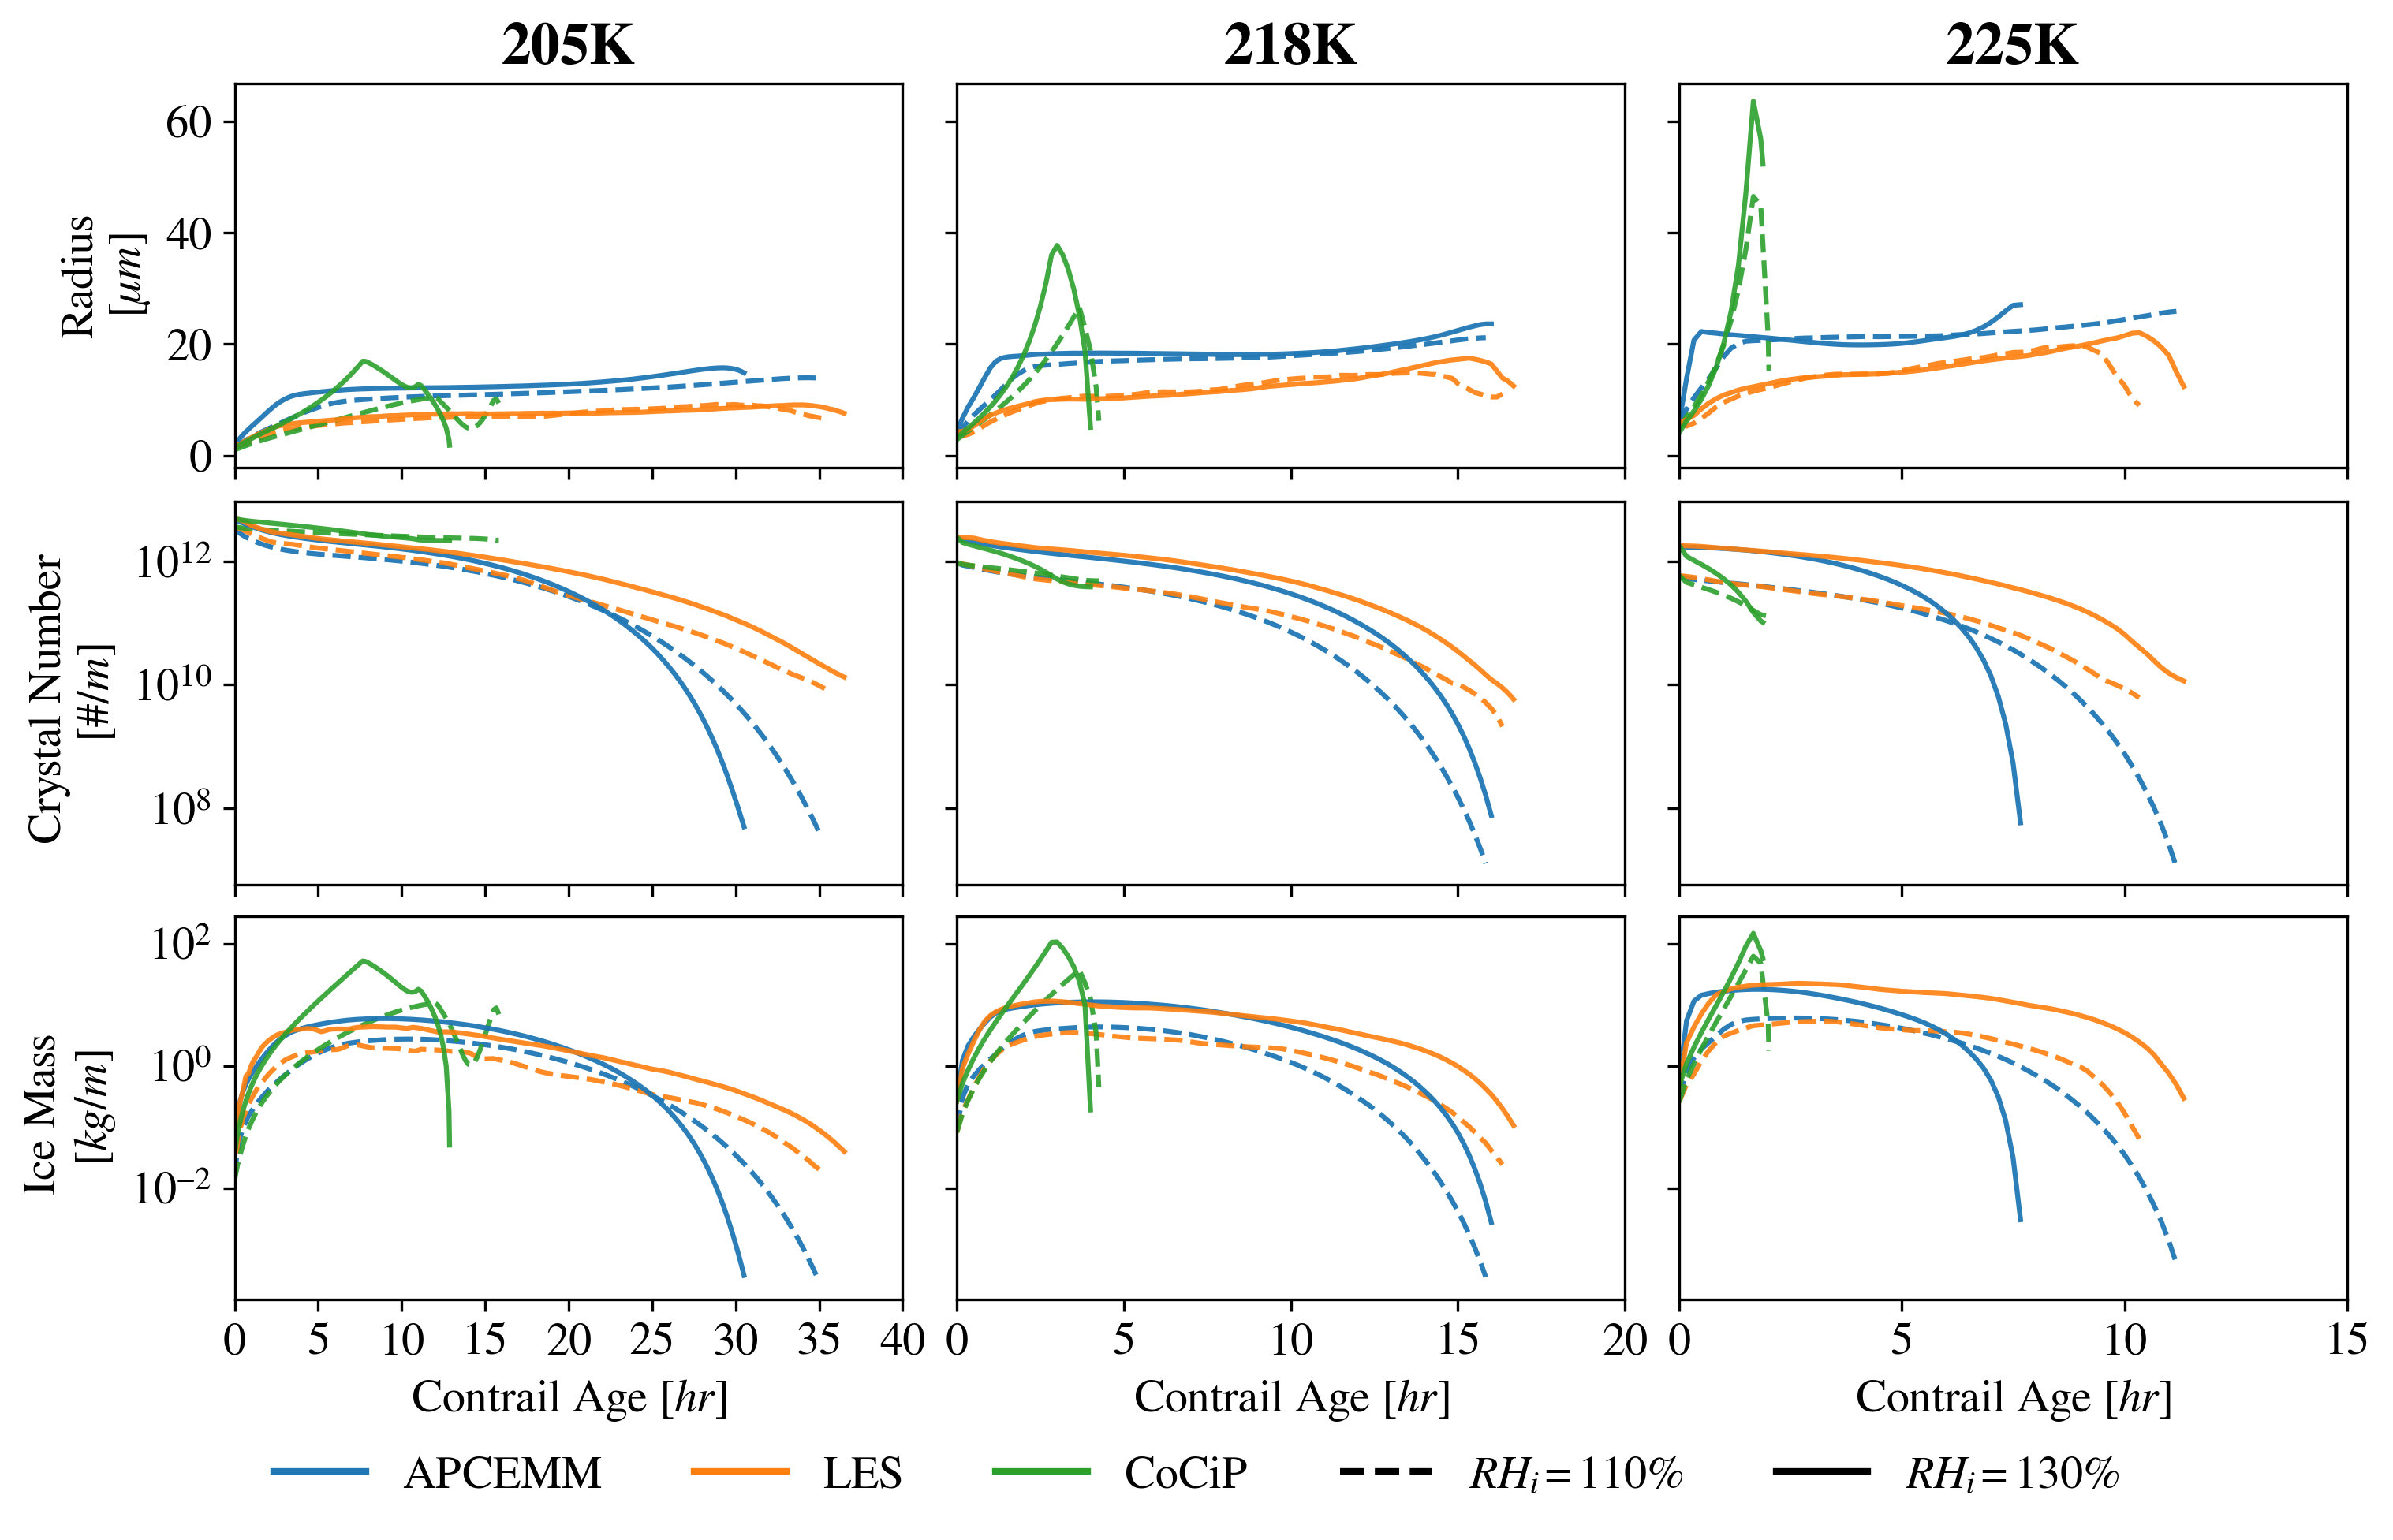

In [24]:
# 3 rows (reff, number, mass) x 3 cols (205K, 218K, 225K)
fig, axes = plt.subplots(
    3, 3, figsize=(10, 6), dpi=300,
    sharex='col', sharey='row', layout='constrained'
)

for j, temp in enumerate(temp_groups):
    ax_reff = axes[0, j]
    ax_num = axes[1, j]
    ax_mass = axes[2, j]

    ax_num.set_yscale("log")
    ax_mass.set_yscale("log")
    ax_reff.set_yscale("linear")
    ax_reff.set_title(f"{temp}K", fontsize=18, fontweight='bold')

    max_age = 0.0  # track max plotted age for this temperature column

    for rh in [110, 130]:
        tid = f"{rh}T{temp}L25"
        ls = rh_styles[rh]
        key = (tid, 0, 'ghm')  # Assuming we want to plot the 'ghm' habit at 0h for each test ID

        # APCEMM
        if key in apcemm_data:
            ds_list = apcemm_data[key]
            t_ap = ds_list['t'].values
            r_ap_um = np.array([get_apcemm_sauter_reff_um(ds_list, idx) for idx in range(len(t_ap))], dtype=float)
            n_ap = np.array(ds_list["Number Ice Particles"].values, dtype=float)
            m_ap = np.array(ds_list["Ice Mass"].values, dtype=float)

            ax_reff.plot(t_ap, r_ap_um, color=model_colors["APCEMM"], linestyle=ls, alpha=0.95)
            ax_num.plot(t_ap, n_ap, color=model_colors["APCEMM"], linestyle=ls, alpha=0.95)
            ax_mass.plot(t_ap, m_ap, color=model_colors["APCEMM"], linestyle=ls, alpha=0.95)

            if t_ap.size:
                max_age = max(max_age, float(np.nanmax(t_ap)))

        # LES
        if key in les_data:
            t_les = les_data[key]["Time_hours"]

            if "Effective_radius_um" in les_data[key]:
                ax_reff.plot(
                    t_les,
                    les_data[key]["Effective_radius_um"],
                    color=model_colors["LES"], linestyle=ls, alpha=0.9
                )

            ax_num.plot(
                t_les,
                les_data[key]["Ice_number"],
                color=model_colors["LES"], linestyle=ls, alpha=0.9
            )
            ax_mass.plot(
                t_les,
                les_data[key]["Ice_mass"],
                color=model_colors["LES"], linestyle=ls, alpha=0.9
            )

            t_les_arr = np.asarray(t_les, dtype=float)
            if t_les_arr.size:
                max_age = max(max_age, float(np.nanmax(t_les_arr)))

        # CoCiP
        if key in cocip_data:
            cds = cocip_data[key]
            t_co = cds["age_hours"].values
            r_co_um = cds["r_ice_vol"].values * 1e6
            n_co = cds["n_ice_per_m"].values
            m_co = (4.0 / 3.0) * np.pi * rho_ice * (cds["r_ice_vol"].values**3) * n_co

            ax_reff.plot(t_co, r_co_um, color=model_colors["CoCiP"], linestyle=ls, alpha=0.9)
            ax_num.plot(t_co, n_co, color=model_colors["CoCiP"], linestyle=ls, alpha=0.9)
            ax_mass.plot(t_co, m_co, color=model_colors["CoCiP"], linestyle=ls, alpha=0.9)

            if t_co.size:
                max_age = max(max_age, float(np.nanmax(t_co)))

    # Set x-limits/ticks for this temperature column: ceil to nearest 5 h
    x_max = int(5 * np.ceil(max_age / 5.0)) if max_age > 0 else 5
    for ax in axes[:, j]:
        ax.set_xlim(0, x_max)
        ax.tick_params(axis='both', labelsize=14)
        ax.set_xticks(np.arange(0, x_max + 1, 5))
        ax.minorticks_off()

# Axis labels
axes[0, 0].set_ylabel("Radius\n[$\\mu m$]", fontsize=14)
axes[1, 0].set_ylabel("Crystal Number \n[$\\#/m$]", fontsize=14)
axes[2, 0].set_ylabel("Ice Mass \n[$kg/m$]", fontsize=14)
for j in range(3):
    axes[2, j].set_xlabel("Contrail Age [$hr$]", fontsize=14)

# Legends: model=color, RH=linestyle
model_handles = [
    Line2D([0], [0], color=model_colors["APCEMM"], lw=2, linestyle="-", label="APCEMM"),
    Line2D([0], [0], color=model_colors["LES"], lw=2, linestyle="-", label="LES"),
    Line2D([0], [0], color=model_colors["CoCiP"], lw=2, linestyle="-", label="CoCiP"),
]
rh_handles = [
    Line2D([0], [0], color="k", lw=2, linestyle=rh_styles[110], label=r"$RH_i=110\%$"),
    Line2D([0], [0], color="k", lw=2, linestyle=rh_styles[130], label=r"$RH_i=130\%$"),
]

fig.legend(
    handles=model_handles + rh_handles,
    loc="lower center", bbox_to_anchor=(0.5, -0.075),
    ncol=5, frameon=False, fontsize=14
)

plt.show()

In [ ]:
# # Find the timestep at which the sauter effective radius slope changes from negative to positive for CoCiP at 110% RHi and 205K
# # Truncate the data to stop at that inflection point

# test_id = "130T205L25"

# for hour in hours:
#     for habit in habits:
#         key = (test_id, hour, habit)
#         if key in cocip_data:
#             ds = cocip_data[key]
#             reff = ds["r_ice_vol"].values * 1e6  # Convert to micrometers
#             age_hours = ds["age_hours"].values

#             # Calculate the slope of the effective radius
#             slope = np.gradient(reff, age_hours)

#             # Find the index where the slope changes from negative to positive
#             inflection_indices = np.where(np.diff(np.sign(slope)) > 0)[0]

#             if len(inflection_indices) > 0:
#                 inflection_index = inflection_indices[0] + 1  # +1 because diff reduces the array size by 1
#                 truncated_age_hours = age_hours[:inflection_index + 1]
#                 truncated_reff = reff[:inflection_index + 1]

#                 print(f"Inflection point for {key}: Age = {truncated_age_hours[-1]:.2f} hours, Effective Radius = {truncated_reff[-1]:.2f} µm")

#             # Update the associated .nc file to only include data up to the inflection point
#             with xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results/CoCiP/{test_id}/nontruncated/CoCiP_{test_id}_{hour}h_{habit}.nc", mode='r') as ds_nc:
#                 # Truncate the dataset to only include data up to the inflection point (time)
#                 ds_nc = ds_nc.isel(t=slice(None, inflection_index + 1))
#                 ds_nc.to_netcdf(f"/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results/CoCiP/{test_id}/CoCiP_{test_id}_{hour}h_{habit}.nc")

Inflection point for ('130T205L25', 0, 'ghm'): Age = 10.67 hours, Effective Radius = 12.17 µm


PermissionError: [Errno 13] Permission denied: b'/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results/CoCiP/130T205L25/CoCiP_130T205L25_0h_ghm.nc'

In [26]:
def _first_time_value(ds, preferred_coords=('time', 't')):
    for coord in preferred_coords:
        if coord in ds.coords:
            return float(ds[coord].values[0])
    return np.nan

def _parse_test_id(tid):
    rhi = int(tid[:3])
    temp = tid.split('T')[1].split('L')[0]
    return rhi, temp

for tid in test_ids:
    rhi, temp = _parse_test_id(tid)
    key = (tid, 0, 'ghm')

    # # APCEMM
    # ds_ap = apcemm_data[key]
    # t0_ap = _first_time_value(ds_ap, preferred_coords=('t',))
    # r_ap = float(get_apcemm_sauter_reff_um(ds_ap, 0))
    # n_ap = float(ds_ap["Number Ice Particles"].values[0])
    # m_ap = float(ds_ap["Ice Mass"].values[0])
    # print(f"{rhi}% {temp}K APCEMM Radius at t={t0_ap:.1f}: {r_ap:.3f} μm | Number/m: {n_ap:.3e} | Mass/m: {m_ap:.3e} kg/m")

    # LES
    ds_les = les_data[key]
    t0_les = _first_time_value(ds_les, preferred_coords=('time', 'Time_hours'))
    r_les = float(ds_les["Effective_radius_um"].values[0])
    n_les = float(ds_les["Ice_number"].values[0])
    m_les = float(ds_les["Ice_mass"].values[0])
    print(f"{rhi}% {temp}K LES Radius at t={t0_les:.1f}: {r_les:.3f} μm | Number/m: {n_les:.3e} | Mass/m: {m_les:.3e} kg/m")

    # CoCiP
    ds_co = cocip_data[key]
    t0_co = _first_time_value(ds_co, preferred_coords=('age_hours', 't'))
    r_co_um = float(ds_co["r_ice_vol"].values[0] * 1e6)
    n_co = float(ds_co["n_ice_per_m"].values[0])
    m_co = float((4.0 / 3.0) * np.pi * rho_ice * (ds_co["r_ice_vol"].values[0] ** 3) * n_co)
    print(f"{rhi}% {temp}K CoCiP Radius at t={t0_co:.1f}: {r_co_um:.3f} μm | Number/m: {n_co:.3e} | Mass/m: {m_co:.3e} kg/m")
    print("-" * 120)

110% 205K LES Radius at t=0.0: 1.200 μm | Number/m: 3.580e+12 | Mass/m: 1.370e-02 kg/m
110% 205K CoCiP Radius at t=0.0: 0.999 μm | Number/m: 3.580e+12 | Mass/m: 1.370e-02 kg/m
------------------------------------------------------------------------------------------------------------------------
110% 218K LES Radius at t=0.0: 3.343 μm | Number/m: 9.470e+11 | Mass/m: 8.200e-02 kg/m
110% 218K CoCiP Radius at t=0.0: 2.825 μm | Number/m: 9.470e+11 | Mass/m: 8.200e-02 kg/m
------------------------------------------------------------------------------------------------------------------------
110% 225K LES Radius at t=0.0: 5.800 μm | Number/m: 5.880e+11 | Mass/m: 2.546e-01 kg/m
110% 225K CoCiP Radius at t=0.0: 4.831 μm | Number/m: 5.880e+11 | Mass/m: 2.546e-01 kg/m
------------------------------------------------------------------------------------------------------------------------
130% 205K LES Radius at t=0.0: 1.792 μm | Number/m: 4.906e+12 | Mass/m: 3.700e-02 kg/m
130% 205K CoCiP Radius

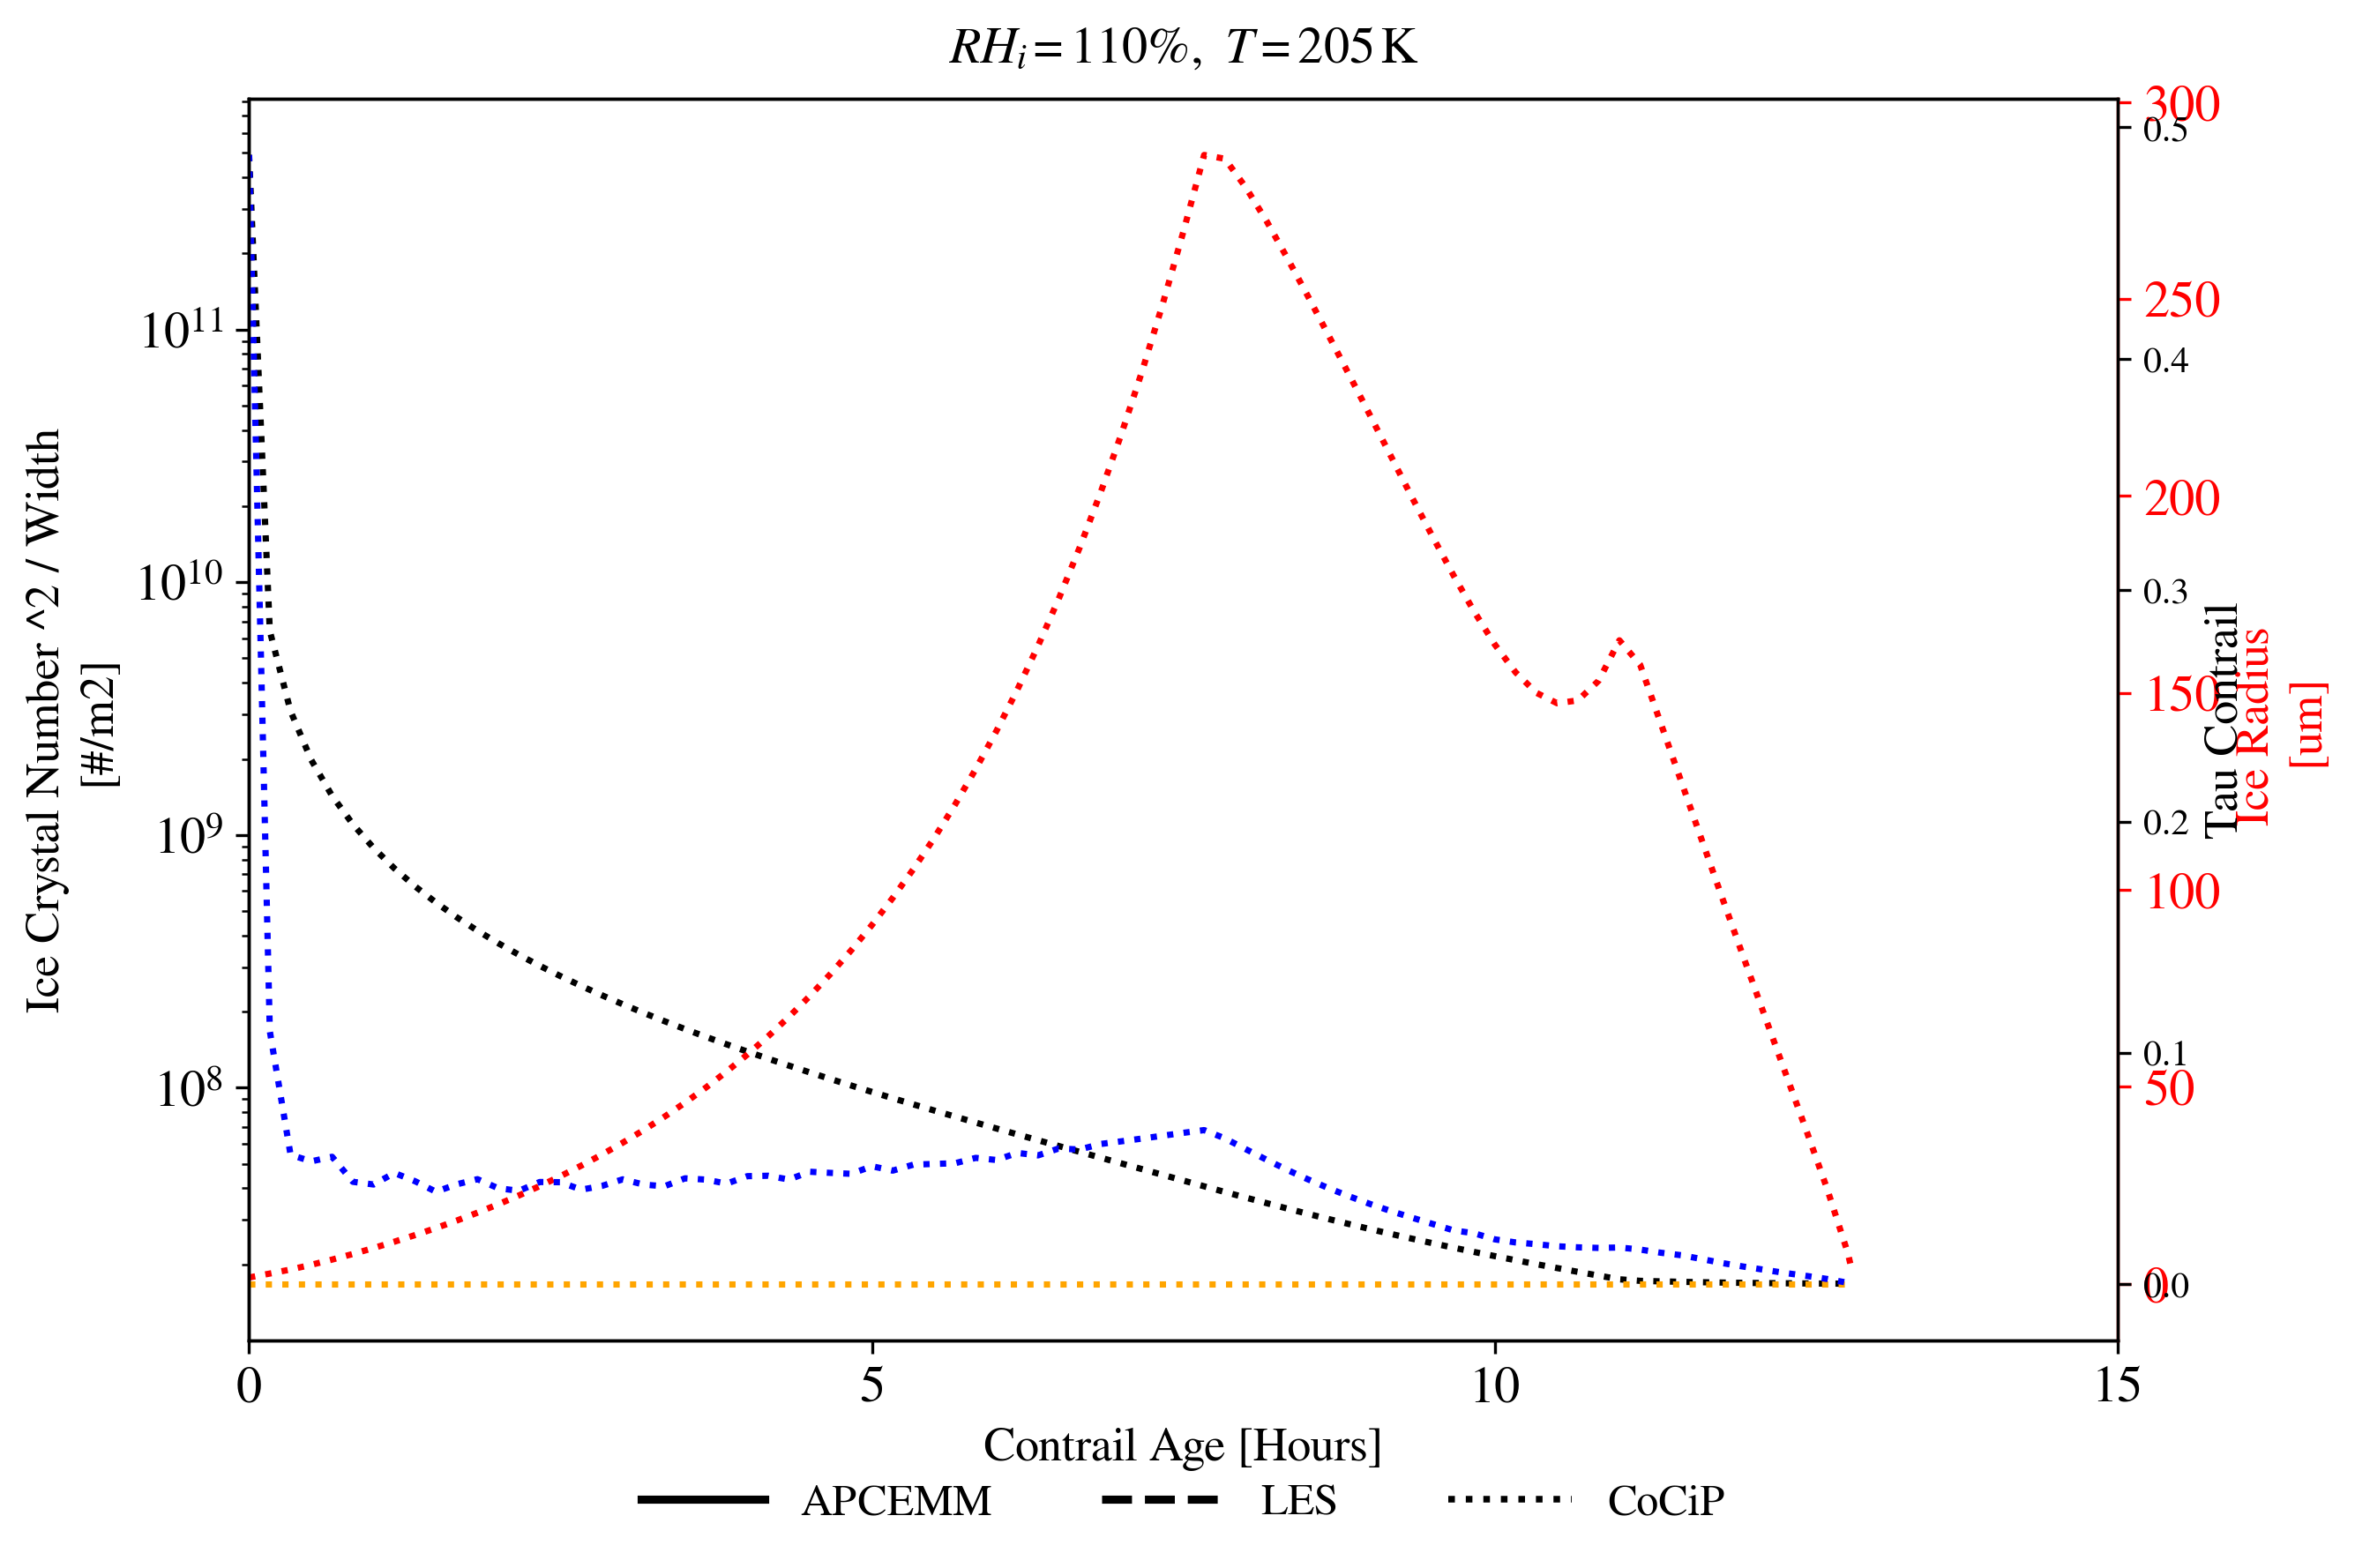

In [27]:
key = ('130T205L25', 0, 'ghm')

# ── Ice Crystal Number [#/m] — left axis (black) ─────────────────────────────

# CoCiP (dotted black)
t_co = cocip_data[key]['age_hours'].values
N_cocip = cocip_data[key]["n_ice_per_m"].values
NW_cocip = N_cocip / cocip_data[key]["width"].values

# ── Ice Mass [kg/m] — right axis (red) ───────────────────────────────────────
# CoCiP (dotted red) 
r_co_m = cocip_data[key]["r_ice_vol"].values
r_co_um = cocip_data[key]["r_ice_vol"].values * 1e6
M_cocip = (4.0 / 3.0) * np.pi * rho_ice * (r_co_m**3) * N_cocip

tau_cocip = cocip_data[key]["tau_contrail"].values

# ── Figure ────────────────────────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(9, 6), dpi=300)
ax2 = ax1.twinx()
ax3 = ax1.twinx()

lw = 2.0
c_alpha = 1

# — Ice crystal number (left, black/grey) —
ax1.plot(t_co, NW_cocip,  color='black',   lw=lw - 0.3, ls=":",  zorder=3, alpha=c_alpha)

# — Ice radius (right, red) —
ax2.plot(t_co, r_co_um**2,  color='red', lw=lw - 0.3, ls=":",  zorder=2, alpha=c_alpha)

ax3.plot(t_co, tau_cocip,  color='blue', lw=lw - 0.3, ls=":",  zorder=2, alpha=c_alpha)

ax2.plot(t_co, r_co_um**2 / NW_cocip,  color='orange', lw=lw - 0.3, ls=":",  zorder=2, alpha=c_alpha)

# ── Axes formatting ───────────────────────────────────────────────────────────

ax1.set_yscale("log")
ax2.set_yscale("linear")
ax3.set_yscale("linear")

xmax = 15
ax1.set_xlim(0, xmax)

ax1.set_xlabel("Contrail Age [Hours]", fontsize=13)
ax1.set_ylabel("Ice Crystal Number ^2 / Width\n[#/m2]", fontsize=13)
ax2.set_ylabel("Ice Radius \n[um]", fontsize=13, color='red')
ax2.tick_params(axis="y", colors='red', labelsize=14)
ax2.spines["right"].set_edgecolor('red')
ax2.yaxis.label.set_color('red')

ax3.set_ylabel("Tau Contrail", fontsize=13)

ax1.tick_params(axis="both", labelsize=14)
ax1.set_xticks(np.arange(0, xmax+1, 5))

# log-decade gridlines on left axis only
ax1.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
ax1.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=50))

# right-axis ticks styled red, no grid
# ax2.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
ax2.tick_params(which="both", right=True, left=False)

# ── Title ─────────────────────────────────────────────────────────────────────

ax1.set_title(r"$RH_i = 110\%,\ T = 205\,\mathrm{K}$",
              fontsize=14, fontstyle="italic", pad=10)

# ── Legend ────────────────────────────────────────────────────────────────────

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='black', lw=2.2, ls="-",  label="APCEMM"),
    Line2D([0], [0], color='black',  lw=2.2, ls="--", label="LES"),
    Line2D([0], [0], color='black',  lw=1.8, ls=":",  label="CoCiP"),
]

ax1.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    fontsize=12,
    frameon=False,
    handlelength=2.8,
    columnspacing=2.5,
)

# ── Spines ────────────────────────────────────────────────────────────────────

for spine in ["top"]:
    ax1.spines[spine].set_visible(True)
    ax2.spines[spine].set_visible(True)

ax1.spines["left"].set_linewidth(0.8)
ax1.spines["bottom"].set_linewidth(0.8)
ax2.spines["right"].set_linewidth(0.8)

plt.tight_layout()
plt.show()

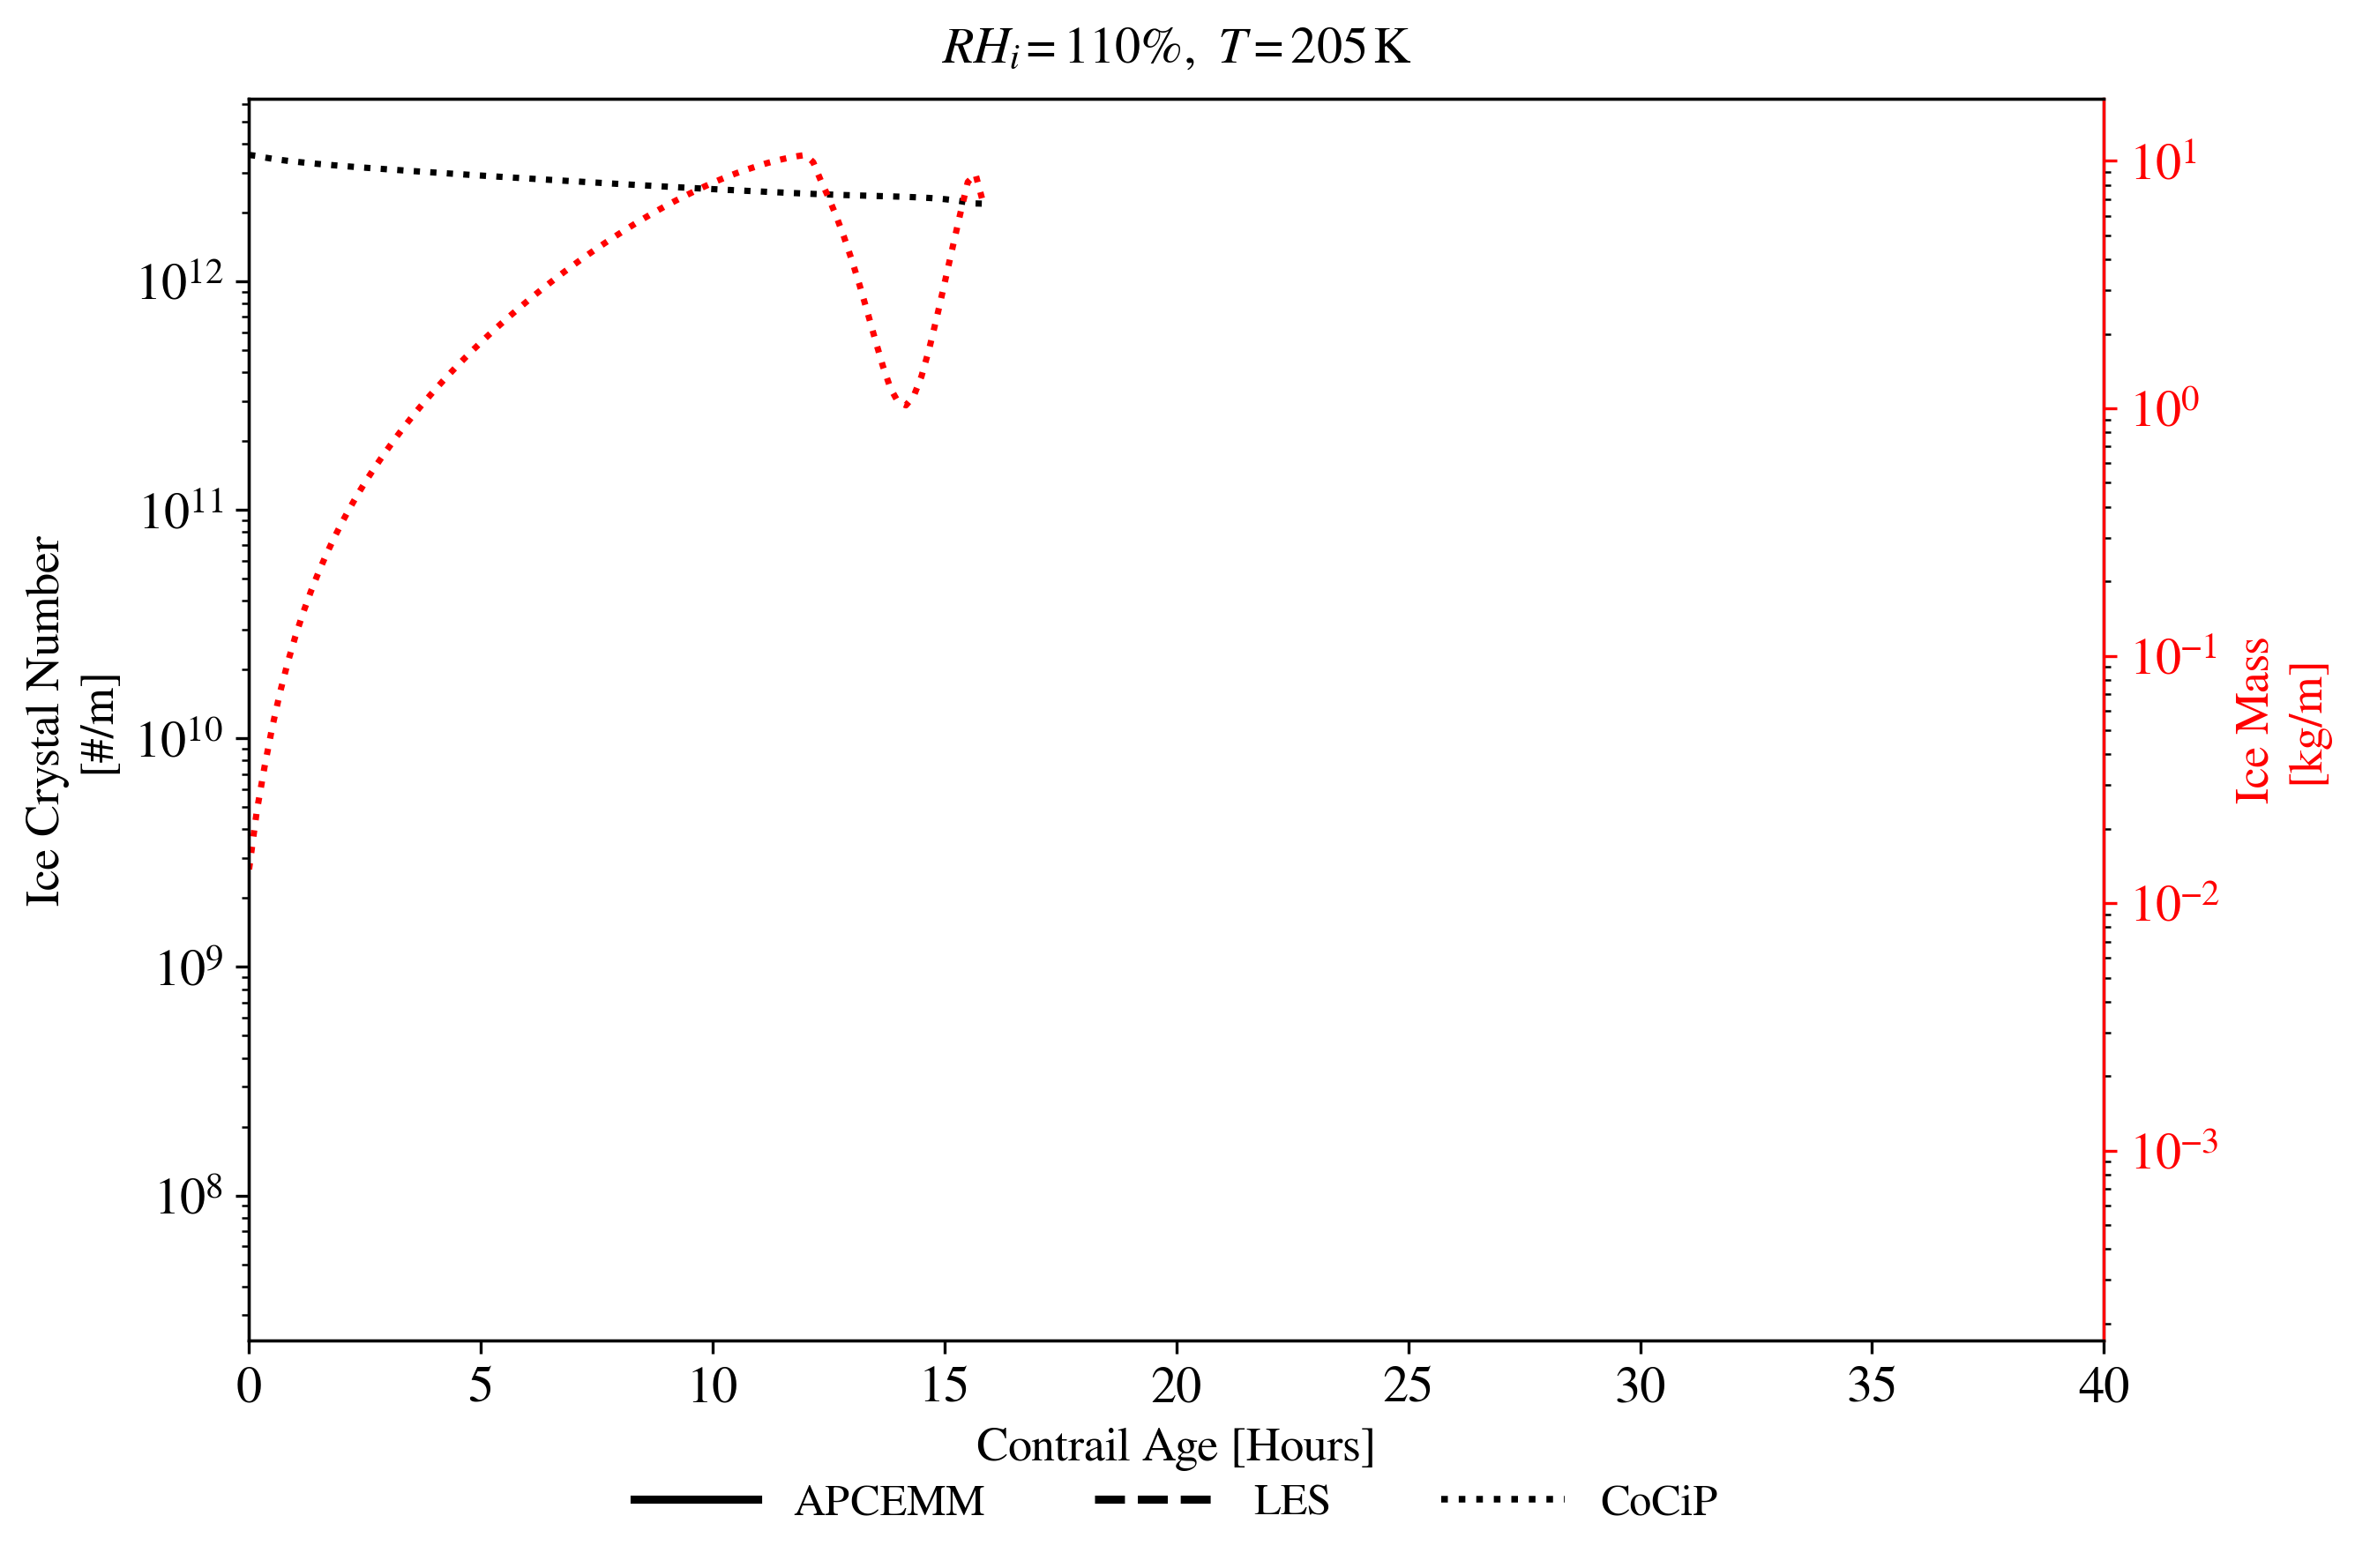

In [28]:
key = ('110T205L25', 0, 'ghm')

# ── Ice Crystal Number [#/m] — left axis (black) ─────────────────────────────

# APCEMM (solid black)
t_ap = apcemm_data[key]['t'].values
N_apcemm = apcemm_data[key]["Number Ice Particles"].values

# LES (dashed black)
t_les = les_data[key]["Time_hours"].values
N_les = les_data[key]["Ice_number"].values

# CoCiP (dotted black)
t_co = cocip_data[key]['age_hours'].values
N_cocip = cocip_data[key]["n_ice_per_m"].values

# ── Ice Mass [kg/m] — right axis (red) ───────────────────────────────────────

# APCEMM (solid red) 
M_apcemm = apcemm_data[key]["Ice Mass"].values

# LES (dashed red) 
M_les = les_data[key]["Ice_mass"].values

# CoCiP (dotted red) 
r_co_um = cocip_data[key]["r_ice_vol"].values
M_cocip = (4.0 / 3.0) * np.pi * rho_ice * (r_co_um**3) * N_cocip

# ── Figure ────────────────────────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(9, 6), dpi=300)
ax2 = ax1.twinx()

lw = 2.0

les_alpha = 0
a_alpha = 0
c_alpha = 1

# — Ice crystal number (left, black/grey) —
ax1.plot(t_ap, N_apcemm, color='black',  lw=lw,       ls="-",  zorder=3, alpha=a_alpha)
ax1.plot(t_les, N_les,    color='black',   lw=lw,       ls="--", zorder=3, alpha=les_alpha)
ax1.plot(t_co, N_cocip,  color='black',   lw=lw - 0.3, ls=":",  zorder=3, alpha=c_alpha)

# — Ice mass (right, red) —
ax2.plot(t_ap, M_apcemm, color='red', lw=lw,       ls="-",  zorder=2, alpha=a_alpha)
ax2.plot(t_les, M_les,    color='red', lw=lw,       ls="--", zorder=2, alpha=les_alpha)
ax2.plot(t_co, M_cocip,  color='red', lw=lw - 0.3, ls=":",  zorder=2, alpha=c_alpha)

# ── Axes formatting ───────────────────────────────────────────────────────────

ax1.set_yscale("log")
ax2.set_yscale("log")

xmax = 40
ax1.set_xlim(0, xmax)

ax1.set_xlabel("Contrail Age [Hours]", fontsize=13)
ax1.set_ylabel("Ice Crystal Number\n[#/m]", fontsize=13)
ax2.set_ylabel("Ice Mass\n[kg/m]", fontsize=13, color='red')
ax2.tick_params(axis="y", colors='red', labelsize=14)
ax2.spines["right"].set_edgecolor('red')
ax2.yaxis.label.set_color('red')

ax1.tick_params(axis="both", labelsize=14)
ax1.set_xticks(np.arange(0, xmax+1, 5))

# log-decade gridlines on left axis only
ax1.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
ax1.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=50))

# right-axis ticks styled red, no grid
ax2.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
ax2.tick_params(which="both", right=True, left=False)

# ── Title ─────────────────────────────────────────────────────────────────────

ax1.set_title(r"$RH_i = 110\%,\ T = 205\,\mathrm{K}$",
              fontsize=14, fontstyle="italic", pad=10)

# ── Legend ────────────────────────────────────────────────────────────────────

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='black', lw=2.2, ls="-",  label="APCEMM"),
    Line2D([0], [0], color='black',  lw=2.2, ls="--", label="LES"),
    Line2D([0], [0], color='black',  lw=1.8, ls=":",  label="CoCiP"),
]

ax1.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    fontsize=12,
    frameon=False,
    handlelength=2.8,
    columnspacing=2.5,
)

# ── Spines ────────────────────────────────────────────────────────────────────

for spine in ["top"]:
    ax1.spines[spine].set_visible(True)
    ax2.spines[spine].set_visible(True)

ax1.spines["left"].set_linewidth(0.8)
ax1.spines["bottom"].set_linewidth(0.8)
ax2.spines["right"].set_linewidth(0.8)

plt.tight_layout()
plt.show()

# Figure: 1000 bins vs 2 bins vs CoCiP

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────

TEST_ID    = '110T218L25'
GRID_RES   = 220
X_BUFFER   = 0.10
KEY_A = "Effective radius"
KEY_C = "r_ice_vol"
KEY_MASS = "Effective radius"  # mass-weighting field; set to None to use uniform weights
MASK_THRESHOLD = 5e-8          # values below this are masked in APCEMM rows

# ── Load datasets ─────────────────────────────────────────────────────────────

ds_cocip     = xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25/110T218L25-bypass_midnight.nc", decode_times=False)
ds_1000_bins = lib.read_apcemm_data(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/{TEST_ID}/outputs/").ds_t
ds_2_bins    = lib.read_apcemm_data(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/testing/2-bins-TP6-TT1/{TEST_ID}/outputs/").ds_t

# ── Helpers ───────────────────────────────────────────────────────────────────

def mass_weighted_centroid(ds, key_mass=None, threshold=None):
    """
    Returns (x_c, y_c) mass-weighted centroid.
    If key_mass is None or not present in ds, falls back to uniform weighting.
    Cells where the weight field is below threshold are excluded.
    """
    x_vals = ds["x"].values
    y_vals = ds["y"].values

    if key_mass is not None and key_mass in ds:
        weights = np.where(np.isnan(ds[key_mass].values), 0.0, ds[key_mass].values)
    else:
        weights = np.ones((len(y_vals), len(x_vals)))

    if threshold is not None:
        weights = np.where(weights < threshold, 0.0, weights)

    X, Y = np.meshgrid(x_vals, y_vals)

    total = weights.sum()
    if total == 0:
        x_c = x_vals.mean()
        y_c = y_vals.mean()
    else:
        x_c = (weights * X).sum() / total
        y_c = (weights * Y).sum() / total

    return x_c, y_c


def cocip_ellipse_plot(width, depth, shear_strain, center=(0, 0), ax=None, **ellipse_kwargs):
    sigma_yy = 0.125 * width ** 2
    sigma_zz = 0.125 * depth ** 2
    sigma_yz = shear_strain * sigma_zz

    cov = np.array([[sigma_yy, sigma_yz],
                    [sigma_yz, sigma_zz]])

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    eigvals = np.maximum(eigvals, 0)

    axis_lengths = 2 * np.sqrt(eigvals)
    angle_deg = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

    t = np.linspace(0, 2 * np.pi, 500)
    circle = np.array([np.cos(t), np.sin(t)])
    sheared = eigvecs @ np.diag(np.sqrt(eigvals)) @ circle

    x_ell = sheared[0] + center[0]
    y_ell = sheared[1] + center[1]

    if ax is not None:
        ellipse = Ellipse(
            xy=center,
            width=axis_lengths[0],
            height=axis_lengths[1],
            angle=angle_deg,
            facecolor="none",
            edgecolor=ellipse_kwargs.pop("edgecolor", "C3"),
            **ellipse_kwargs
        )
        ax.add_patch(ellipse)
        ax.plot(center[0], center[1], "kx", ms=8)

    return angle_deg, tuple(axis_lengths), x_ell, y_ell


def build_cocip_ellipse(time_idx):
    width = ds_cocip["width"].values[time_idx]
    area = ds_cocip["area_eff"].values[time_idx]
    depth = ds_cocip["depth"].values[time_idx]
    sigma_yz = ds_cocip["sigma_yz"].values[time_idx]
    bulk_property = ds_cocip[KEY_C].values[time_idx] * 1e6

    shear_strain = sigma_yz / (0.125 * depth ** 2)

    angle_deg, axis_lengths, x_ell, y_ell = cocip_ellipse_plot(
        width, depth, shear_strain, center=(0, 0), ax=None
    )


    current_area = np.pi * (axis_lengths[0] * axis_lengths[1]) / 4
    scale = np.sqrt(area / current_area)

    x_ell = x_ell * scale
    y_ell = y_ell * scale

    x_pad = (x_ell.max() - x_ell.min()) * X_BUFFER
    x_grid = np.linspace(x_ell.min() - x_pad, x_ell.max() + x_pad, GRID_RES)

    return dict(
        x_ell=x_ell,
        y_ell=y_ell,
        x_grid=x_grid,
        y_extent=np.abs(y_ell).max(),
        bulk_value=bulk_property,
        angle_deg=angle_deg,
        a_sol=None,
        b_sol=None,
        altitude=ds_cocip["altitude"].values[time_idx],
    )


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
PLOT_TIMES_MIN = [150]
DATASETS       = [ds_1000_bins, ds_2_bins]
ROW_LABELS     = ["APCEMM - 1000 Bins", "APCEMM - 1 Bin", "CoCiP"]
COLORMAP       = "viridis"
CBAR_MIN       = 1
CBAR_MAX       = 30
FONTSIZE       = 14

NCOLS  = len(PLOT_TIMES_MIN)
NROWS  = len(DATASETS) + 1  # +1 for CoCiP row

shared_norm = mcolors.Normalize(vmin=CBAR_MIN, vmax=CBAR_MAX)
cmap        = plt.cm.get_cmap(COLORMAP)

# ── Helper: get ax regardless of 1-col or multi-col layout ────────────────────
def get_ax(axes, row, col, ncols):
    return axes[row] if ncols == 1 else axes[row, col]

# ── Pre-compute CoCiP ellipses ────────────────────────────────────────────────
cocip_ellipse = {idx: build_cocip_ellipse(idx) for idx in PLOT_TIMES_MIN}

# ── Compute shared x/y limits across all datasets and CoCiP ──────────────────
all_xmins, all_xmaxs = [], []
all_ymins, all_ymaxs = [], []

for ds_list in DATASETS:
    for idx in PLOT_TIMES_MIN:
        if int(idx / 10) < len(ds_list):
            ds = ds_list[int(idx / 10)]
            all_xmins.append(ds["x"].values.min())
            all_xmaxs.append(ds["x"].values.max())

for idx in PLOT_TIMES_MIN:
    cd = cocip_ellipse[idx]
    all_xmins.append(cd["x_ell"].min());  all_xmaxs.append(cd["x_ell"].max())
    all_ymins.append(cd["y_ell"].min());  all_ymaxs.append(cd["y_ell"].max())

x_range = max(all_xmaxs) - min(all_xmins)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(8, 7), dpi=300)

# ── Plot ──────────────────────────────────────────────────────────────────────
for col, idx in enumerate(PLOT_TIMES_MIN):

    # — APCEMM rows —
    for row, ds_list in enumerate(DATASETS):
        ax = get_ax(axes, row, col, NCOLS)

        if int(idx / 10) >= len(ds_list):
            continue

        ds     = ds_list[int(idx / 10)]
        x_vals = ds["x"].values
        y_vals = ds["y"].values
        raw    = ds[KEY_A].values
        data   = raw * 1e6

        # Center x on mass-weighted centroid
        use_mass_key        = KEY_MASS if row == 0 else None
        x_c, y_c           = mass_weighted_centroid(ds, key_mass=use_mass_key, threshold=MASK_THRESHOLD)
        x_centered          = x_vals - x_c

        masked_data = np.ma.masked_where(raw < MASK_THRESHOLD, data)

        ax.imshow(
            masked_data, cmap=cmap, norm=shared_norm,
            origin="lower", aspect="auto",
            extent=[x_centered.min(), x_centered.max(), y_vals.min(), y_vals.max()]
        )
        ax.axhline(y=-500, color="red",   linestyle="-", linewidth=1)
        ax.plot(0, y_c,   marker="x",    ms=8, mew=1.5, color="black", zorder=5, label="Centroid")

        all_ymins.append(y_vals.min())
        all_ymaxs.append(y_vals.max())

    # — CoCiP row —
    ax_cocip = get_ax(axes, -1, col, NCOLS)
    cd       = cocip_ellipse[idx]

    x_ell_centered = cd["x_ell"] - cd["x_ell"].mean()

    ax_cocip.fill(x_ell_centered, cd["y_ell"], color=cmap(shared_norm(cd["bulk_value"])), zorder=2)
    ax_cocip.plot(x_ell_centered, cd["y_ell"], color="none", lw=0.8, zorder=3)
    ax_cocip.axhline(y=-500, color="red", linestyle="-", linewidth=1)
    ax_cocip.plot(0, cd["y_ell"].mean(), marker="x", ms=8, mew=1.5, color="black", zorder=5)

    # Column title (contrail age) on top row only
    get_ax(axes, 0, col, NCOLS).set_title(f"Contrail Age {idx} min", fontsize=10, fontweight="bold")

# ── Shared axis limits ────────────────────────────────────────────────────────
y_lo = min(all_ymins)
y_hi = np.abs(y_lo) - 250

print(f"DEBUG: x_range = {x_range}")
print(f"DEBUG: -x_range/2 + 250 = {-x_range / 2 + 250}")
print(f"DEBUG: x_range/2 - 250 = {x_range / 2 - 250}")

for row in range(NROWS):
    for col in range(NCOLS):
        ax = get_ax(axes, row, col, NCOLS)
        ax.set_xlim(-x_range / 2 + 2200, x_range / 2 - 900)
        ax.set_ylim(y_lo, y_hi)

# ── Axis labels and row titles ────────────────────────────────────────────────
for row, label in enumerate(ROW_LABELS):
    ax = get_ax(axes, row, 0, NCOLS)
    ax.set_ylabel("z [m]", fontsize=FONTSIZE)
    ax.set_title(label,    fontsize=FONTSIZE, fontweight="bold")

for col in range(NCOLS):
    get_ax(axes, NROWS - 1, col, NCOLS).set_xlabel("x [m]", fontsize=FONTSIZE)

# Hide x tick labels on all but the last row
for row in range(NROWS - 1):
    for col in range(NCOLS):
        get_ax(axes, row, col, NCOLS).tick_params(axis='x', labelbottom=False)

# ── Colorbar ──────────────────────────────────────────────────────────────────
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.05, 0.015, 0.88])
sm      = plt.cm.ScalarMappable(cmap=cmap, norm=shared_norm)
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label("Radius [μm]", fontsize=FONTSIZE)
cb.ax.tick_params(labelsize=FONTSIZE)

plt.tight_layout(rect=[0, 0, 0.89, 0.98])
plt.show()

In [ ]:
# ── Combined plot ─────────────────────────────────────────────────────────────
print(f"Number of time steps in CoCiP dataset: {len(ds_cocip['age_hours'])}")
plot_times_min = [150]

datasets = [ds_1000_bins]
labels   = ["APCEMM", "CoCiP"]

ncols    = len(plot_times_min)
nrows    = len(datasets) + 1
colormap = "viridis"
y_lo, y_hi = 10.100, 10.800

cbar_min, cbar_max = 1, 30
shared_norm = mcolors.Normalize(vmin=cbar_min, vmax=cbar_max)

cocip_ellipse = {idx: build_cocip_ellipse(idx) for idx in plot_times_min}

fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

cmap = plt.cm.get_cmap(colormap)

all_ymins, all_ymaxs = [], []

# ── collect CoCiP y extents up front so they feed into the shared limits ──────
for idx in plot_times_min:
    cd = cocip_ellipse[idx]
    all_ymins.append(cd["y_ell"].min())
    all_ymaxs.append(cd["y_ell"].max())

# ── Compute shared x-limits based on all datasets ────────────────────────────
all_x_mins, all_x_maxs = [], []

for ds_list in datasets:
    for idx in plot_times_min:
        if int(idx / 10) < len(ds_list):
            ds = ds_list[int(idx / 10)]
            x_vals = ds["x"].values/1000
            all_x_mins.append(x_vals.min())
            all_x_maxs.append(x_vals.max())

for idx in plot_times_min:
    cd = cocip_ellipse[idx]
    all_x_mins.append(cd["x_ell"].min()/1000)
    all_x_maxs.append(cd["x_ell"].max()/1000)

x_global_min, x_global_max = min(all_x_mins), max(all_x_maxs)
x_global_range = x_global_max - x_global_min

for col, (idx, t_min) in enumerate(zip(plot_times_min, plot_times_min)):

    # — rows 0 & 1: APCEMM datasets —
    for row, ds_list in enumerate(datasets):
        ax = axes[row] if ncols == 1 else axes[row, col]

        if int(idx / 10) < len(ds_list):
            ds     = ds_list[int(idx / 10)]
            x_vals = ds["x"].values/1000
            y_vals = ds["y"].values/1000
            data   = ds[KEY_A].values * 1e6

            x_offset  = x_vals.min()
            x_shifted = x_vals - x_offset

            raw = ds[KEY_A].values
            masked_data = np.ma.masked_where(raw < MASK_THRESHOLD, data)
            masked_data = masked_data

            # Center on centroid
            use_mass_key = KEY_MASS if row == 0 else None
            x_c, y_c = mass_weighted_centroid(ds, key_mass=use_mass_key,
                                              threshold=MASK_THRESHOLD)
            x_c_shifted = x_c/1000 - x_offset
            x_shifted_centered = x_shifted - x_c_shifted

            ax.imshow(
                masked_data, cmap=cmap, norm=shared_norm,
                origin="lower", aspect="auto",
                extent=[x_shifted_centered.min(), x_shifted_centered.max(), y_lo, y_hi]
            )

            ax.axhline(y=10.200, color="red", linestyle="-", linewidth=1)
            ax.plot(0, y_c/1000+10.700, marker="x", ms=8, mew=1.5,
                    color="black", zorder=5, label="Centroid")


    # — row 2: CoCiP ellipse —
    ax_cocip = axes[-1] if ncols == 1 else axes[2, col]
    cd = cocip_ellipse[idx]
    c_alt = (cd["altitude"] - 100) # convert m to km and shift so 100 m altitude is at 0 on the plot

    x_ell_shifted  = cd["x_ell"] - cd["x_ell"].min()

    ax_cocip.fill(x_ell_centered/1000, (cd["y_ell"]+c_alt)/1000, color=cmap(shared_norm(cd["bulk_value"])), zorder=2)
    ax_cocip.plot(x_ell_centered/1000, (cd["y_ell"]+c_alt)/1000, color="none", lw=0.8, zorder=3)

    ax_cocip.axhline(y=10.200, color="red", linestyle="-", linewidth=1)

    ax_cocip.plot(0, np.mean((cd["y_ell"]+c_alt)/1000), marker="x", ms=8, mew=1.5,
                  color="black", zorder=5)

# — unified y-limits across ALL rows including CoCiP ─────────────────────────
for col in range(ncols):
    for row in range(nrows):
        ax = axes[row] if ncols == 1 else axes[row, col]
        ax.set_ylim(y_lo, y_hi)
        ax.set_xlim(-x_global_range/2, x_global_range/2)
        ax.set_xlabel("x [km]", fontsize=14, fontweight="bold")

# — labels —
axes[0].set_ylabel("Altitude [km]", fontsize=14, fontweight="bold")
axes[0].set_title(f"APCEMM", fontsize=14, fontweight="bold")
axes[1].set_title(f"CoCiP", fontsize=14, fontweight="bold")

# Increase the font size of the x and y tick labels
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=14)

# — single shared colorbar —
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.05, 0.015, 0.88])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=shared_norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Effective Radius [μm]", size=14)

plt.tight_layout(rect=[0, 0, 0.89, 0.98])
plt.show()

# Figure 3: Energy Forcing Effects

In [ ]:
# ── color definitions ─────────────────────────────────────────────────────────
# Three shades per model: dark → mid → light for ghm → solid-column → rough-aggregate
model_habit_colors = {
    'CoCiP':  {'solid-column': '#1a7a1a', 'ghm': '#4caf4c', 'rough-aggregate': '#a8d5a2'},
    'LES':    {'solid-column': '#b85c00', 'ghm': '#e88c2a', 'rough-aggregate': '#ffd699'},
    'APCEMM': {'solid-column': '#1a4f8a', 'ghm': '#4a80c4', 'rough-aggregate': '#a8c4e8'},
}
model_edge_colors = {'CoCiP': 'tab:green', 'LES': 'tab:orange', 'APCEMM': 'tab:blue'}

# ── helper: age coordinate per model ─────────────────────────────────────────
def get_age_coord(ds, m):
    if m == 'APCEMM':
        return ds['t'].values.astype(float)
    elif m == 'LES':
        return ds['time'].values.astype(float)
    elif m == 'CoCiP':
        return ds['age_hours'].values.astype(float)
    else:
        raise ValueError(f"Unknown model: {m}")

def get_ds(m, tid, hour, habit):
    key = (tid, hour, habit)
    if m == 'APCEMM':
        return apcemm_data.get(key)
    elif m == 'CoCiP':
        return cocip_data.get(key)
    elif m == 'LES':
        return les_data.get(key)

def get_cocip_internal_point(tid, hour, target_h):
    cbd = get_ds('CoCiP', tid, hour, 'ghm')
    if cbd is None:
        return np.nan

    age_hours   = cbd['age_hours'].values.astype(float)
    ef_vals     = cbd['ef'].values.astype(float)
    seg_lengths = cbd['segment_length'].values.astype(float)

    max_contrail_age = age_hours[-1]

    if target_h is None:
        idx = len(age_hours) - 2
    elif target_h >= max_contrail_age:
        return np.nan
    else:
        idx = np.argmin(np.abs(age_hours - target_h))
        idx = max(0, idx - 1)

    ef_cocip_internal = np.cumsum(ef_vals[1:] / seg_lengths[1:])

    if idx >= len(ef_cocip_internal):
        return np.nan

    return ef_cocip_internal[idx]

def flush_temp_label(ax, T, bsx, bex):
    ax.text((bsx + bex) / 2, -0.12, f'{T} K',
            ha='center', va='top', fontsize=12, fontweight='bold',
            transform=ax.get_xaxis_transform(), clip_on=False)

def group_x_positions(groups, n_models):
    x0, positions, prev_T = 0.0, [], None
    for (T, tid) in groups:
        if prev_T is not None and T != prev_T:
            x0 += group_gap
        positions.append(x0)
        x0 += n_models * (model_cluster_w + model_gap) + 0.08
        prev_T = T
    return positions

# ── draw bars ─────────────────────────────────────────────────────────────────
def draw_bars(ax, hour, model_order, group_starts):
    for gi, (T, tid) in enumerate(groups):
        x_group = group_starts[gi]
        for mi, m in enumerate(model_order):
            x_model = x_group + mi * (model_cluster_w + model_gap)
            edge_col = model_edge_colors[m]

            for hi, habit in enumerate(habits):
                xc        = x_model + hi * sub_bar_w
                fill_col  = model_habit_colors[m][habit]

                # ---- full run bar ----
                yf = per_case[tid][m][hour][habit]
                if yf is not None:
                    ax.bar(xc, abs(yf), bottom=min(yf, 0), width=sub_bar_w,
                           align='edge', color=fill_col, edgecolor=edge_col,
                           linewidth=0.6, zorder=2, alpha=0.6)

                # ---- 4h truncated overlay (hatch, no fill) ----
                y4 = per_case_4h[tid][m][hour][habit]
                if y4 is not None:
                    ax.bar(xc, abs(y4), bottom=min(y4, 0), width=sub_bar_w,
                           align='edge', color='None', edgecolor=edge_col,
                           linewidth=0.6, hatch='///', zorder=3)

# ── CoCiP internal scatter ────────────────────────────────────────────────────
def draw_cocip_internal(ax, hour, model_order, group_starts):
    cocip_idx = model_order.index('CoCiP')
    for gi, (_, tid) in enumerate(groups):
        x_model = group_starts[gi] + cocip_idx * (model_cluster_w + model_gap)
        x = x_model + model_cluster_w / 2   # centre of the CoCiP cluster

        y_none = cocip_internal.get((tid, hour, 'none'), np.nan)
        if np.isfinite(y_none):
            ax.scatter(x, y_none, marker='s', s=12,
                       facecolors='black', edgecolors='black', zorder=6)

        y_4h = cocip_internal.get((tid, hour, '4h'), np.nan)
        if np.isfinite(y_4h):
            ax.scatter(x, y_4h, marker='s', s=12,
                       facecolors='none', edgecolors='black', zorder=6)


/tmp/ipykernel_844447/2035037577.py:75: RuntimeWarning: invalid value encountered in divide
  ef_cocip_internal = np.cumsum(ef_vals[1:] / seg_lengths[1:])


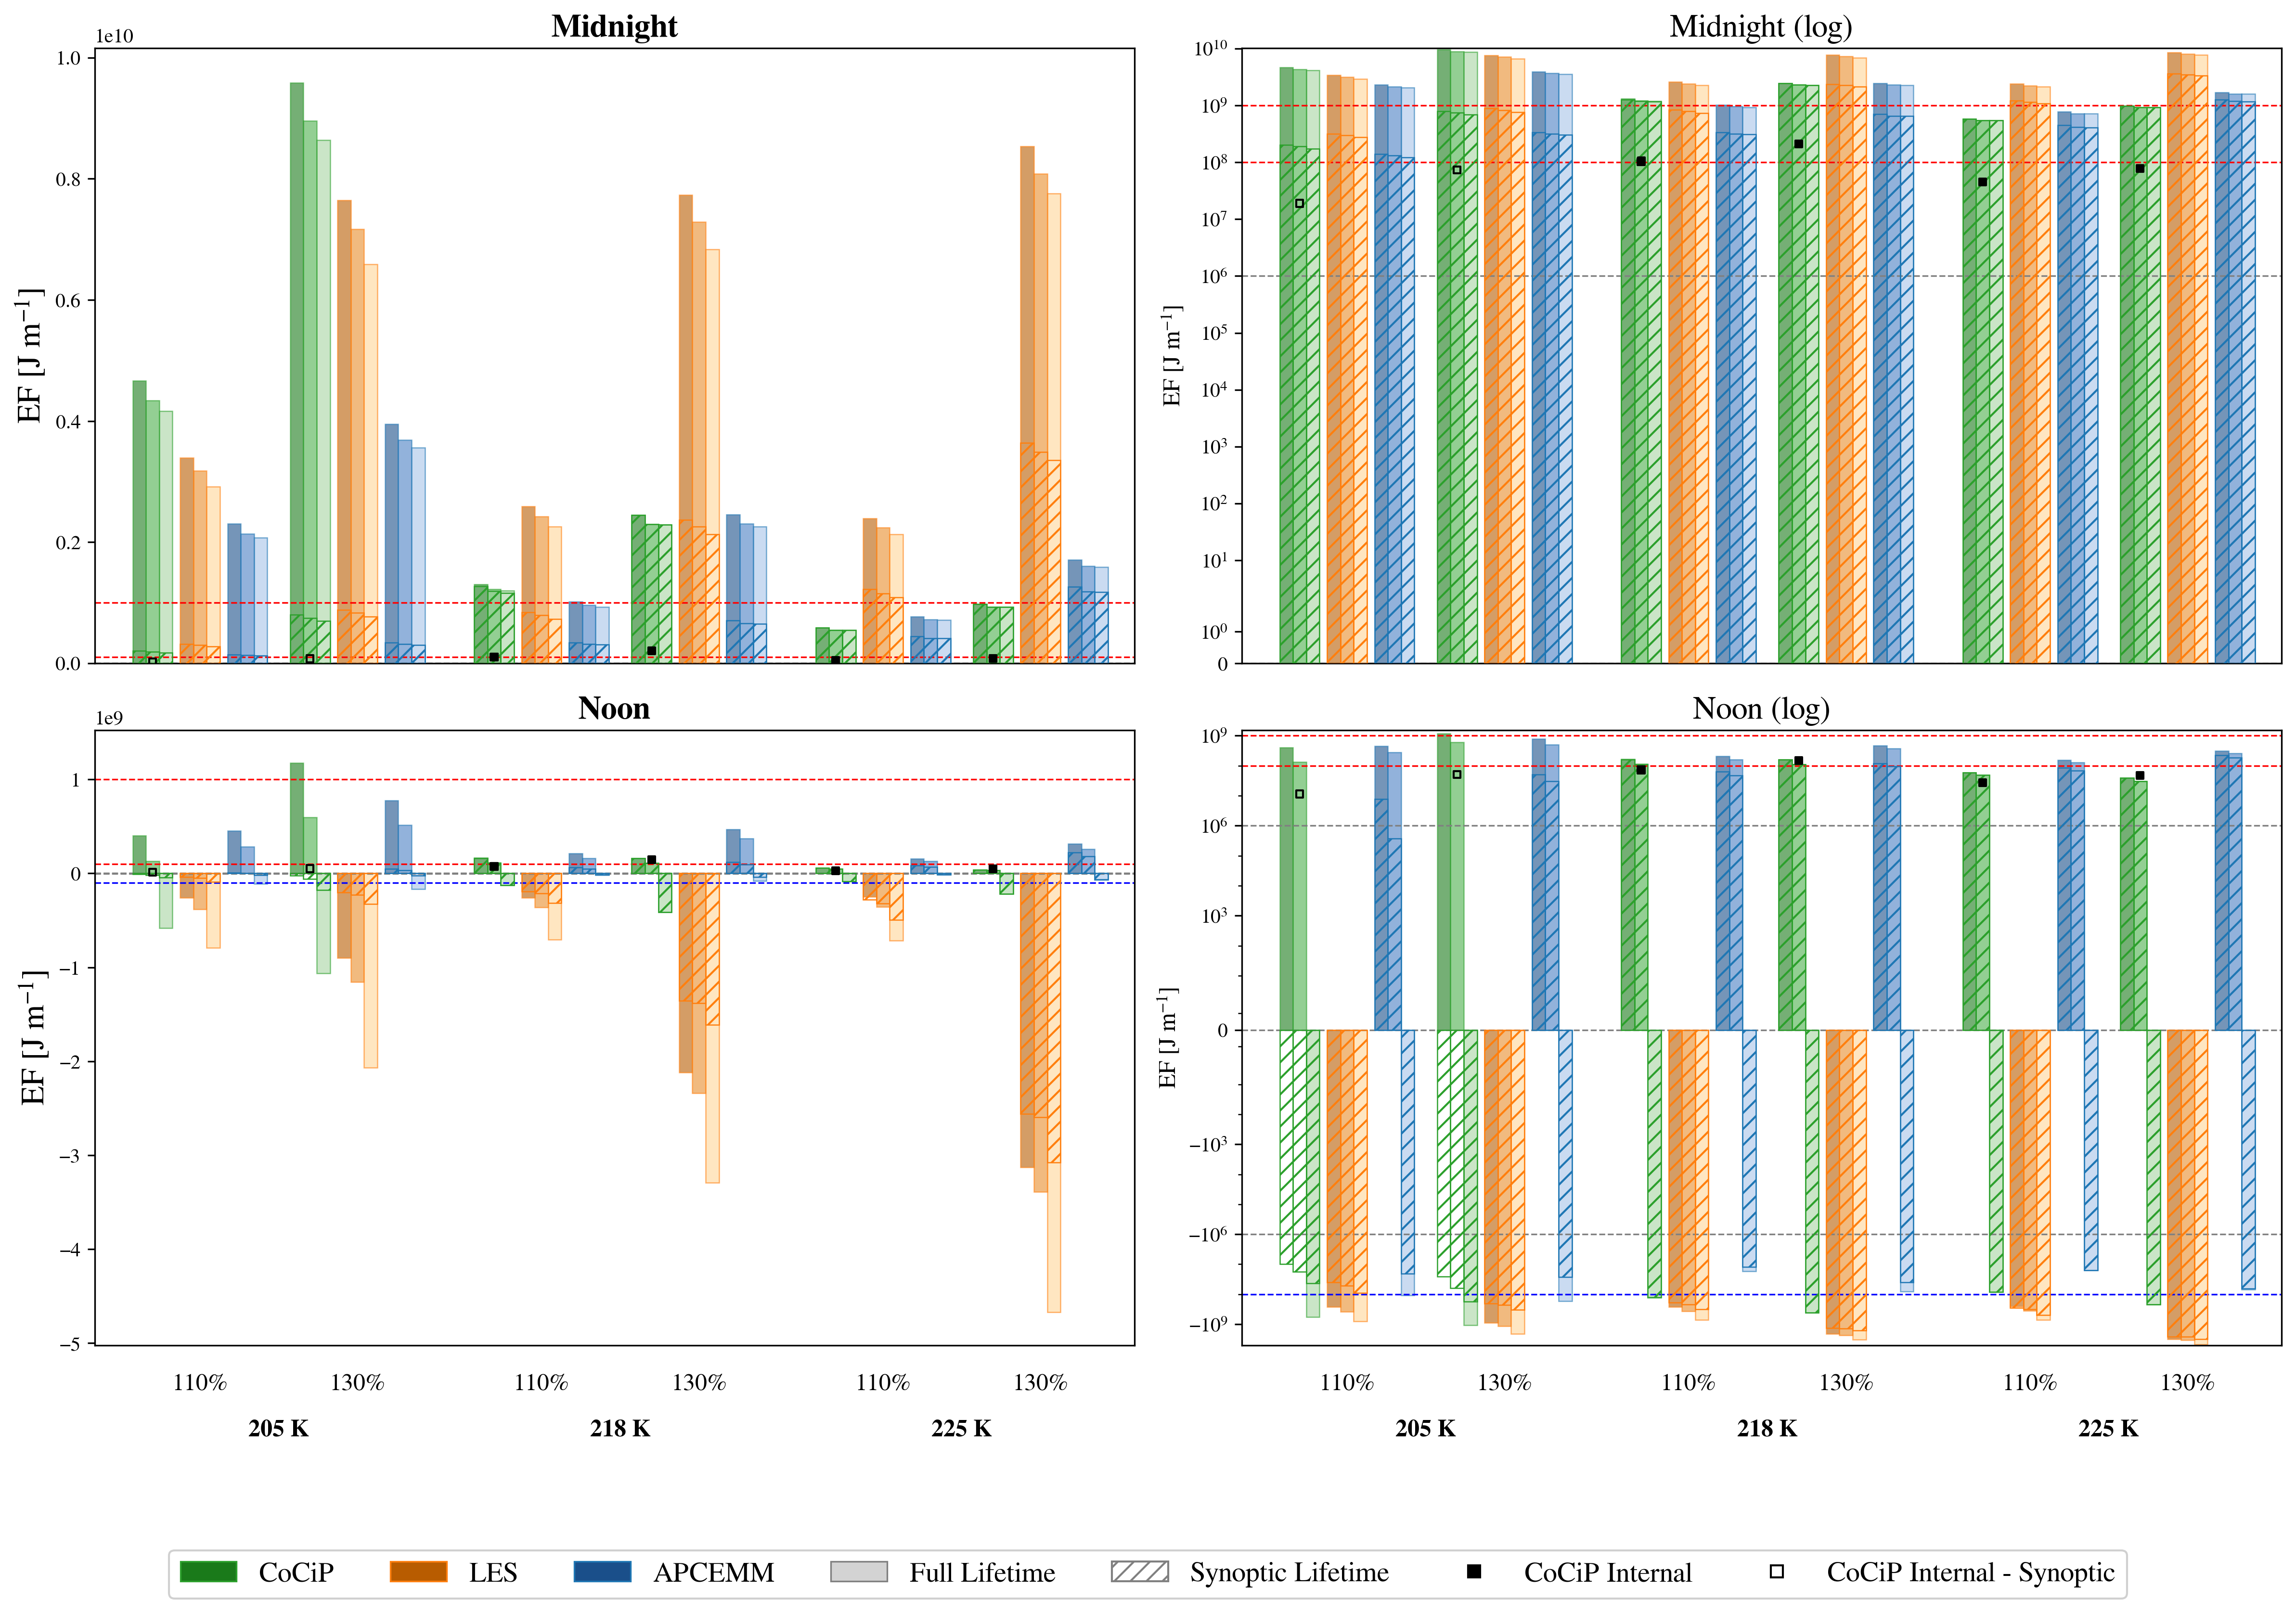

In [ ]:
# ── data paths & keys ────────────────────────────────────────────────────────
test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']
hours    = [0, 12]
habits   = ['solid-column', 'ghm', 'rough-aggregate']
base_dir = '/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results'

TARGET_AGE_H = 4.0

# ── accumulate per-habit EF values ───────────────────────────────────────────
# Keyed by (tid, model, hour, habit) — one scalar each
per_case    = {tid: {m: {h: {hab: None for hab in habits} for h in hours} for m in ['APCEMM', 'CoCiP', 'LES']} for tid in test_ids}
per_case_4h = {tid: {m: {h: {hab: None for hab in habits} for h in hours} for m in ['APCEMM', 'CoCiP', 'LES']} for tid in test_ids}

for m in ['APCEMM', 'CoCiP', 'LES']:
    for tid in test_ids:
        for hour in hours:
            for habit in habits:
                ds = get_ds(m, tid, hour, habit)
                if ds is None:
                    continue

                age     = get_age_coord(ds, m)
                ef_vals = ds['Energy Forcing'].values.astype(float)

                # full run: last EF value (remove index-0 for APCEMM)
                ef_full = (ef_vals[1:] - ef_vals[0]) if (m == 'APCEMM' and len(ef_vals) > 1) else ef_vals
                if len(ef_full) > 0:
                    per_case[tid][m][hour][habit] = float(ef_full[-1])

                # 4h truncated: last EF value at or before 4 h
                ef_4h = ef_vals[age <= TARGET_AGE_H]
                if len(ef_4h) > 0:
                    per_case_4h[tid][m][hour][habit] = float(ef_4h[-1])

# ── CoCiP internal EF (unchanged logic) ──────────────────────────────────────
cocip_internal = {}
for tid in test_ids:
    for hour in hours:
        cocip_internal[(tid, hour, 'none')] = get_cocip_internal_point(tid, hour, None)
        cocip_internal[(tid, hour, '4h')]   = get_cocip_internal_point(tid, hour, TARGET_AGE_H)

# ── layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=300, sharey=False)
# axes[0,0] = Midnight (full)      axes[0,1] = Midnight (zoomed, 0 < y < 2.5e9)
# axes[1,0] = Noon (full)          axes[1,1] = Noon (zoomed, -1e9 < y < 1e9)

temps_unique = sorted({int(tid.split('T')[1].split('L')[0]) for tid in test_ids})

groups = []
for T in temps_unique:
    for tid in sorted([t for t in test_ids if f"T{T}" in t],
                      key=lambda s: int(s[:3])):
        groups.append((T, tid))

model_order  = ['CoCiP', 'LES', 'APCEMM']
n_habits     = len(habits)
sub_bar_w    = 0.07   # width of each individual habit bar
model_gap    = 0.04   # gap between model clusters
group_gap    = 0.14   # extra gap between temperature groups

model_cluster_w = n_habits * sub_bar_w  # total width of one model's habit bars

group_starts = group_x_positions(groups, len(model_order))

x_left  = -0.2
x_right = group_starts[-1] + len(model_order) * (model_cluster_w + model_gap) + 0.1

# ── panel definitions ──────────────────────────────────────────────────────────
# (ax, hour, title, is_zoom_col, fixed_ylim_or_None)
panel_info = [
    (axes[0, 0], 0,  'Midnight',            False, None),
    (axes[0, 1], 0,  'Midnight (log)',   True,  None),
    (axes[1, 0], 12, 'Noon',                False, None),
    (axes[1, 1], 12, 'Noon (log)',       True,  None),
]

for ax, hour, title, is_zoom, fixed_ylim in panel_info:
    draw_bars(ax, hour, model_order, group_starts)
    draw_cocip_internal(ax, hour, model_order, group_starts)

    ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    ax.axhline(1e9, color='red', linestyle='--', lw=0.8)
    ax.axhline(1e8, color='red', linestyle='--', lw=0.8)
    ax.axhline(1e6, color='gray', linestyle='--', lw=0.8)
    ax.axhline(-1e6, color='gray', linestyle='--', lw=0.8)
    ax.axhline(-1e8, color='blue', linestyle='--', lw=0.8)

    ax.set_title(title, fontsize=16, fontweight='bold' if not is_zoom else 'normal')
    ax.set_xticks([])
    ax.set_xlim(x_left, x_right)

# ── y limits ──────────────────────────────────────────────────────────────────
# left column: autocomputed as before (per hour)
# right column: fixed to the requested ranges
for ax, hour, title, is_zoom, fixed_ylim in panel_info:
    if is_zoom:
        if hour == 0:
            ax.set_ylim(0, ymax + pad)
        else:
            ax.set_ylim(ymin - pad, ymax + pad)

        ax.set_yscale('symlog')

        if ax is axes[1, 1]:
            from matplotlib.ticker import FixedLocator, FuncFormatter
    
            ax.yaxis.set_major_locator(
                FixedLocator([-1e9, -1e6, -1e3, 0, 1e3, 1e6, 1e9])
            )
            def symlog_formatter(x, pos):
                if x == 0:
                    return '0'
                exponent = int(np.log10(abs(x)))
                sign = '-' if x < 0 else ''
                return rf'${sign}10^{{{exponent}}}$'
        
            ax.yaxis.set_major_formatter(FuncFormatter(symlog_formatter))
    
        continue

    ymins, ymaxs = [], []
    for tid in test_ids:
        for m in model_order:
            for habit in habits:
                for val_dict in [per_case, per_case_4h]:
                    v = val_dict[tid][m][hour][habit]
                    if v is not None:
                        ymins.append(v)
                        ymaxs.append(v)
        for mode in ['none', '4h']:
            y_int = cocip_internal.get((tid, hour, mode), np.nan)
            if np.isfinite(y_int):
                ymins.append(y_int)
                ymaxs.append(y_int)

    ymin = min(ymins) if ymins else -1
    ymax = max(ymaxs) if ymaxs else  1
    pad  = 0.06 * (ymax - ymin)

    if hour == 0:
        ax.set_ylim(0, ymax + pad)
    else:
        ax.set_ylim(ymin - pad, ymax + pad)

    ax.set_yscale('linear')

axes[0, 0].set_ylabel('EF [J m$^{-1}$]', fontsize=16)
axes[1, 0].set_ylabel('EF [J m$^{-1}$]', fontsize=16)
axes[0, 1].set_ylabel('EF [J m$^{-1}$]', fontsize=12)
axes[1, 1].set_ylabel('EF [J m$^{-1}$]', fontsize=12)

# ── x-tick labels (only on bottom row, both columns) ──────────────────────────
bottom_row_panels = [p for p in panel_info if p[0] in (axes[1, 0], axes[1, 1])]

for ax, hour, title, is_zoom, fixed_ylim in bottom_row_panels:

    for gi, (T, tid) in enumerate(groups):
        total_w = len(model_order) * (model_cluster_w + model_gap) - model_gap
        xc = group_starts[gi] + total_w / 2
        rhi_str = tid[:3] + '%'
        ax.text(xc, -0.045, rhi_str, ha='center', va='top', fontsize=12,
                transform=ax.get_xaxis_transform(), clip_on=False)

    prev_T, block_start_x = None, None

    for gi, (T, tid) in enumerate(groups):
        if T != prev_T:
            if prev_T is not None:
                flush_temp_label(ax, prev_T, block_start_x,
                                 group_starts[gi - 1] + len(model_order) * (model_cluster_w + model_gap) - model_gap)
            block_start_x = group_starts[gi]
            prev_T = T

    flush_temp_label(ax, prev_T, block_start_x,
                     group_starts[-1] + len(model_order) * (model_cluster_w + model_gap) - model_gap)

# ── legend ────────────────────────────────────────────────────────────────────
model_handles = [
    mpatches.Patch(facecolor=model_habit_colors[m]['solid-column'],
                   edgecolor=model_edge_colors[m], linewidth=0.8, label=m)
    for m in model_order
]

habit_labels = {'ghm': 'GHM', 'solid-column': 'Solid Column', 'rough-aggregate': 'Rough Aggregate'}
habit_handles = [
    mpatches.Patch(facecolor=model_habit_colors['APCEMM'][hab],
                   edgecolor=model_edge_colors['APCEMM'], linewidth=0.8,
                   label=habit_labels[hab])
    for hab in habits
]

full_patch = mpatches.Patch(facecolor='lightgray', edgecolor='gray',
                             linewidth=0.8, label='Full Lifetime')
trunc_patch = mpatches.Patch(facecolor='None', edgecolor='gray',
                              hatch='///', label='Synoptic Lifetime')

internal_none_handle = plt.Line2D([0], [0], marker='s', linestyle='None',
                                   color='black', markerfacecolor='black',
                                   markeredgecolor='black', markersize=6,
                                   label='CoCiP Internal')
internal_4h_handle = plt.Line2D([0], [0], marker='s', linestyle='None',
                                 color='black', markerfacecolor='none',
                                 markeredgecolor='black', markersize=6,
                                 label='CoCiP Internal - Synoptic')

fig.legend(
    handles=model_handles + [full_patch, trunc_patch,
                                              internal_none_handle, internal_4h_handle],
    loc='lower center',
    ncol=7,
    fontsize=14,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.02)
)

# ── final layout ──────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

/tmp/ipykernel_844447/2035037577.py:75: RuntimeWarning: invalid value encountered in divide
  ef_cocip_internal = np.cumsum(ef_vals[1:] / seg_lengths[1:])


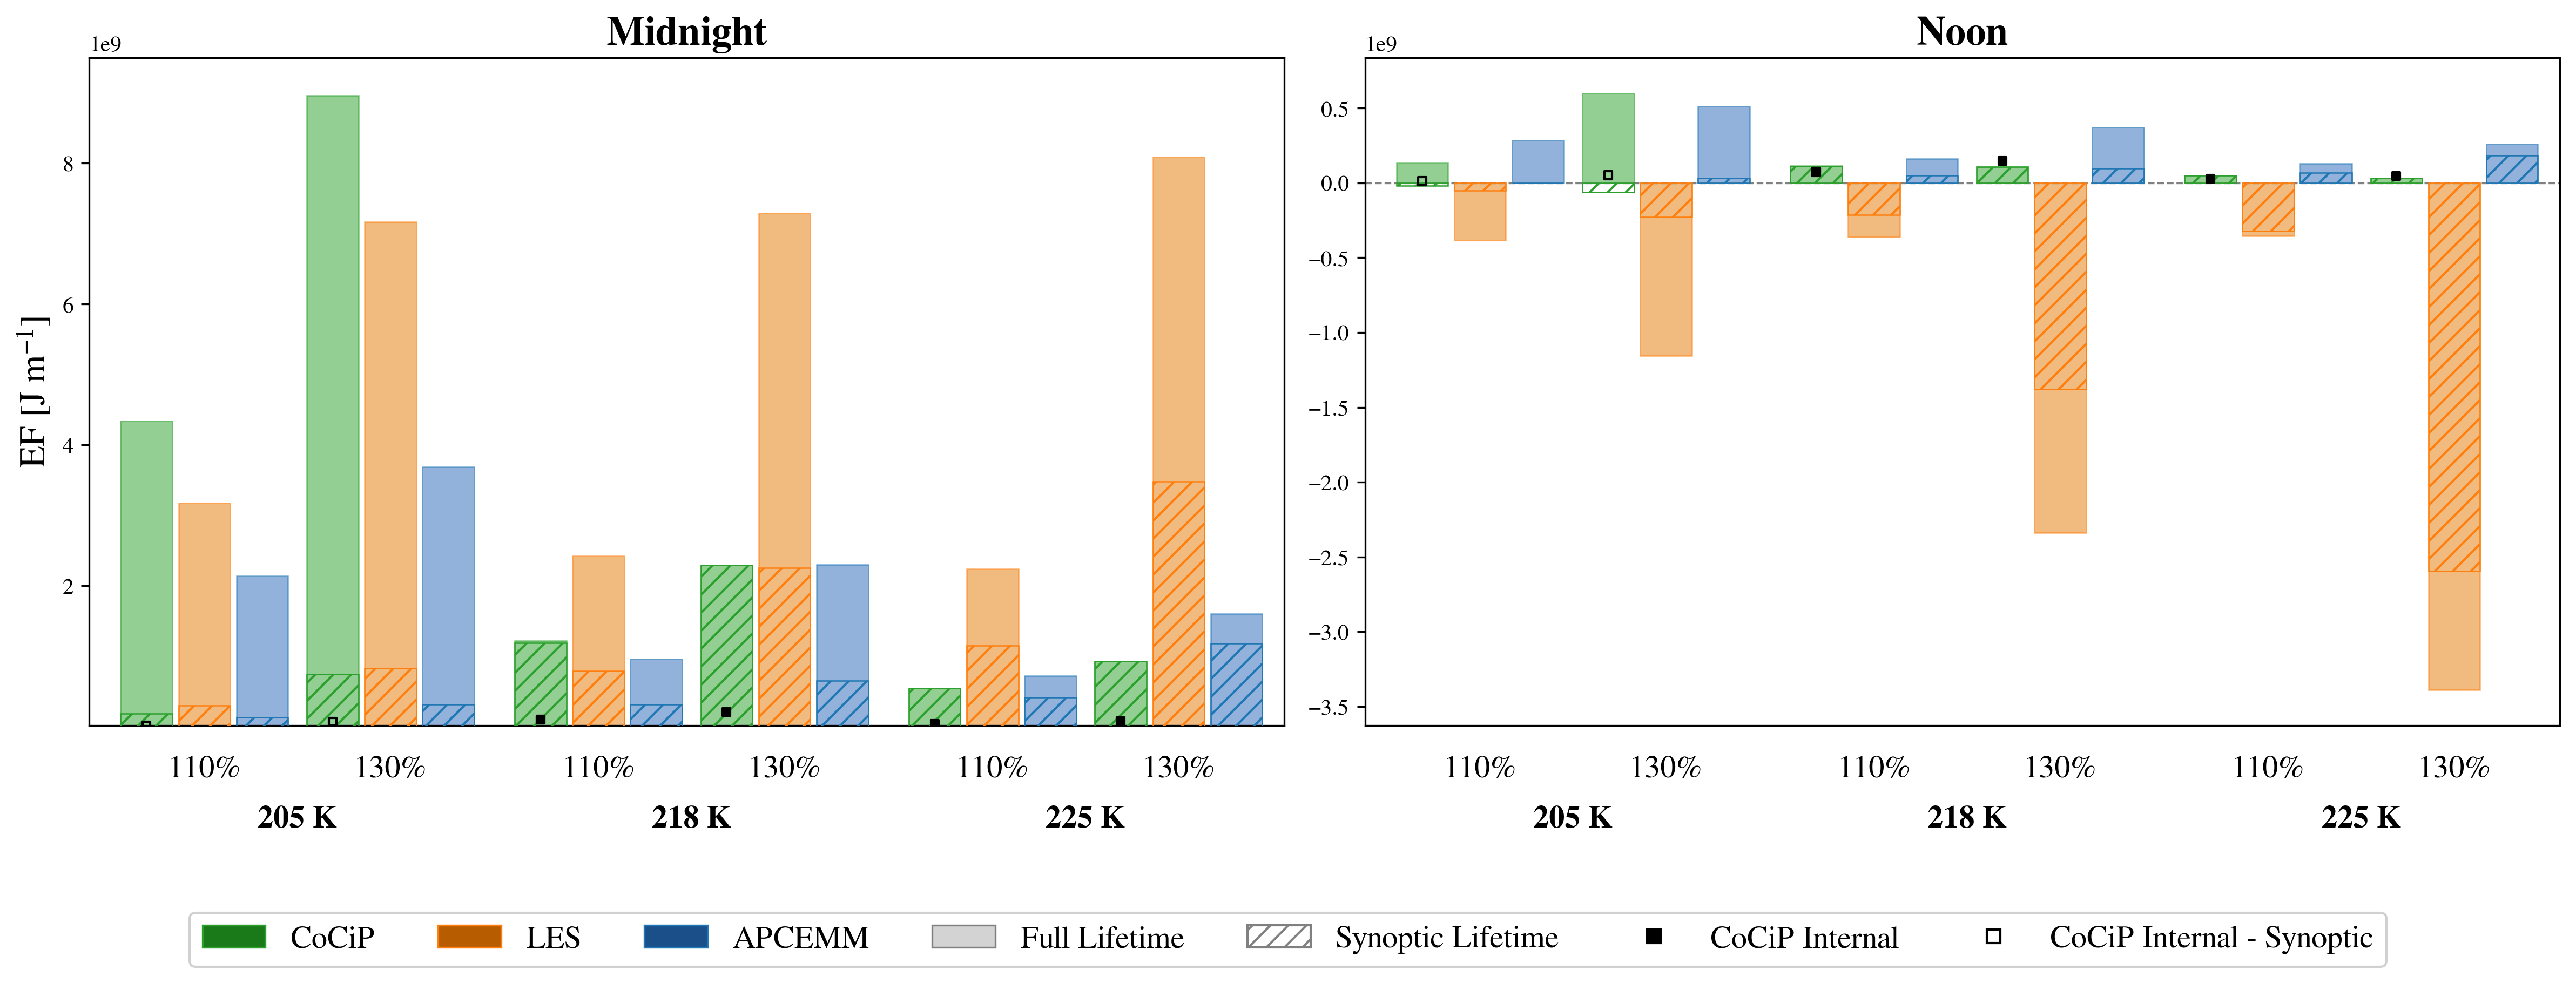

In [36]:
# ── data paths & keys ────────────────────────────────────────────────────────
test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']
hours    = [0, 12]
habits   = ['ghm']

TARGET_AGE_H = 4.0

# ── accumulate per-habit EF values ───────────────────────────────────────────
# Keyed by (tid, model, hour, habit) — one scalar each
per_case    = {tid: {m: {h: {hab: None for hab in habits} for h in hours} for m in ['APCEMM', 'CoCiP', 'LES']} for tid in test_ids}
per_case_4h = {tid: {m: {h: {hab: None for hab in habits} for h in hours} for m in ['APCEMM', 'CoCiP', 'LES']} for tid in test_ids}

for m in ['CoCiP', 'LES', 'APCEMM']:
    for tid in test_ids:
        for hour in hours:
            for habit in habits:
                ds = get_ds(m, tid, hour, habit)
                if ds is None:
                    continue

                age     = get_age_coord(ds, m)
                ef_vals = ds['Energy Forcing'].values.astype(float)

                # full run: last EF value (remove index-0 for APCEMM)
                ef_full = (ef_vals[1:] - ef_vals[0]) if (m == 'APCEMM' and len(ef_vals) > 1) else ef_vals
                if len(ef_full) > 0:
                    per_case[tid][m][hour][habit] = float(ef_full[-1])

                # 4h truncated: last EF value at or before 4 h
                ef_4h = ef_vals[age <= TARGET_AGE_H]
                if len(ef_4h) > 0:
                    per_case_4h[tid][m][hour][habit] = float(ef_4h[-1])

# ── CoCiP internal EF (unchanged logic) ──────────────────────────────────────
cocip_internal = {}
for tid in test_ids:
    for hour in hours:
        cocip_internal[(tid, hour, 'none')] = get_cocip_internal_point(tid, hour, None)
        cocip_internal[(tid, hour, '4h')]   = get_cocip_internal_point(tid, hour, TARGET_AGE_H)


# ── layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300, sharey=False)

temps_unique = sorted({int(tid.split('T')[1].split('L')[0]) for tid in test_ids})

groups = []
for T in temps_unique:
    for tid in sorted([t for t in test_ids if f"T{T}" in t],
                      key=lambda s: int(s[:3])):
        groups.append((T, tid))

model_order  = ['CoCiP', 'LES', 'APCEMM']
n_models     = len(model_order)
n_habits     = len(habits)
sub_bar_w    = 0.33   # width of each individual habit bar
model_gap    = 0.04   # gap between model clusters
group_gap    = 0.14   # extra gap between temperature groups

model_cluster_w = n_habits * sub_bar_w  # total width of one model's 3 bars

group_starts = group_x_positions(groups)

x_left  = -0.2
x_right = group_starts[-1] + n_models * (model_cluster_w + model_gap) + 0.1

# ── CoCiP internal scatter ────────────────────────────────────────────────────
# Place the scatter at the horizontal center of the CoCiP model cluster
cocip_idx = model_order.index('CoCiP')

# ── Input variable scatter ────────────────────────────────────────────────────
# Plot the max depth, lifetime, mass, and radius on top of each bar
# INCOMPLETE
def draw_property_vars(ax, hour):
    for gi, (_, tid) in enumerate(groups):
            x_model = group_starts[gi] + cocip_idx * (model_cluster_w + model_gap)
            x = x_model + model_cluster_w / 2   # centre of the cluster
    
            y_none = cocip_internal.get((tid, hour, 'none'), np.nan)
            if np.isfinite(y_none):
                ax.scatter(x, y_none, marker='o', s=12,
                           facecolors='black', edgecolors='black', zorder=6)
    
            y_4h = cocip_internal.get((tid, hour, '4h'), np.nan)
            if np.isfinite(y_4h):
                ax.scatter(x, y_4h, marker='o', s=12,
                           facecolors='none', edgecolors='black', zorder=6)


# ── main panels ───────────────────────────────────────────────────────────────
panel_info = list(zip(axes, hours, ['Midnight', 'Noon']))

for ax, hour, title in panel_info:
    draw_bars(ax, hour)
    draw_cocip_internal(ax, hour)
    # draw_property_vars(ax, hour)

    ax.axhline(0, color='gray', linestyle='--', lw=0.8)
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xticks([])
    ax.set_xlim(x_left, x_right)

# ── y limits ──────────────────────────────────────────────────────────────────
for ax, hour, title in panel_info:
    ymins, ymaxs = [], []
    for tid in test_ids:
        for m in model_order:
            for habit in habits:
                for val_dict in [per_case, per_case_4h]:
                    v = val_dict[tid][m][hour][habit]
                    if v is not None:
                        ymins.append(v)
                        ymaxs.append(v)
        for mode in ['none', '4h']:
            y_int = cocip_internal.get((tid, hour, mode), np.nan)
            if np.isfinite(y_int):
                ymins.append(y_int)
                ymaxs.append(y_int)

    ymin = min(ymins) if ymins else -1
    ymax = max(ymaxs) if ymaxs else  1
    pad  = 0.06 * (ymax - ymin)

    if hour == 0:
        ax.set_ylim(ymin, ymax + pad)
    else:
        ax.set_ylim(ymin - pad, ymax + pad)

    ax.set_yscale('linear')

axes[0].set_ylabel('EF [J m$^{-1}$]', fontsize=16)

# ── x-tick labels ─────────────────────────────────────────────────────────────
for ax, hour, title in panel_info:

    # RHI labels — centred on the full group of 3 model clusters
    for gi, (T, tid) in enumerate(groups):
        total_w = n_models * (model_cluster_w + model_gap) - model_gap
        xc = group_starts[gi] + total_w / 2
        rhi_str = tid[:3] + '%'
        ax.text(xc, -0.045, rhi_str, ha='center', va='top', fontsize=14,
                transform=ax.get_xaxis_transform(), clip_on=False)

    # Temperature labels
    prev_T, block_start_x = None, None

    for gi, (T, tid) in enumerate(groups):
        if T != prev_T:
            if prev_T is not None:
                flush_temp_label(ax, prev_T, block_start_x,
                                 group_starts[gi - 1] + n_models * (model_cluster_w + model_gap) - model_gap)
            block_start_x = group_starts[gi]
            prev_T = T

    flush_temp_label(ax, prev_T, block_start_x,
                     group_starts[-1] + n_models * (model_cluster_w + model_gap) - model_gap)

# ── legend ────────────────────────────────────────────────────────────────────
# Model patches (mid shade)
model_handles = [
    mpatches.Patch(facecolor=model_habit_colors[m]['solid-column'],
                   edgecolor=model_edge_colors[m], linewidth=0.8, label=m)
    for m in model_order
]

# Habit shade patches (using APCEMM palette as neutral reference)
habit_labels = {'ghm': 'GHM', 'solid-column': 'Solid Column', 'rough-aggregate': 'Rough Aggregate'}
habit_handles = [
    mpatches.Patch(facecolor=model_habit_colors['APCEMM'][hab],
                   edgecolor=model_edge_colors['APCEMM'], linewidth=0.8,
                   label=habit_labels[hab])
    for hab in habits
]

full_patch = mpatches.Patch(facecolor='lightgray', edgecolor='gray',
                             linewidth=0.8, label='Full Lifetime')
trunc_patch = mpatches.Patch(facecolor='None', edgecolor='gray',
                              hatch='///', label='Synoptic Lifetime')

internal_none_handle = plt.Line2D([0], [0], marker='s', linestyle='None',
                                   color='black', markerfacecolor='black',
                                   markeredgecolor='black', markersize=6,
                                   label='CoCiP Internal')
internal_4h_handle = plt.Line2D([0], [0], marker='s', linestyle='None',
                                 color='black', markerfacecolor='none',
                                 markeredgecolor='black', markersize=6,
                                 label='CoCiP Internal - Synoptic')

fig.legend(
    handles=model_handles + [full_patch, trunc_patch,
                                              internal_none_handle, internal_4h_handle],
    loc='lower center',
    ncol=7,
    fontsize=14,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.02)
)

# ── final layout ──────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

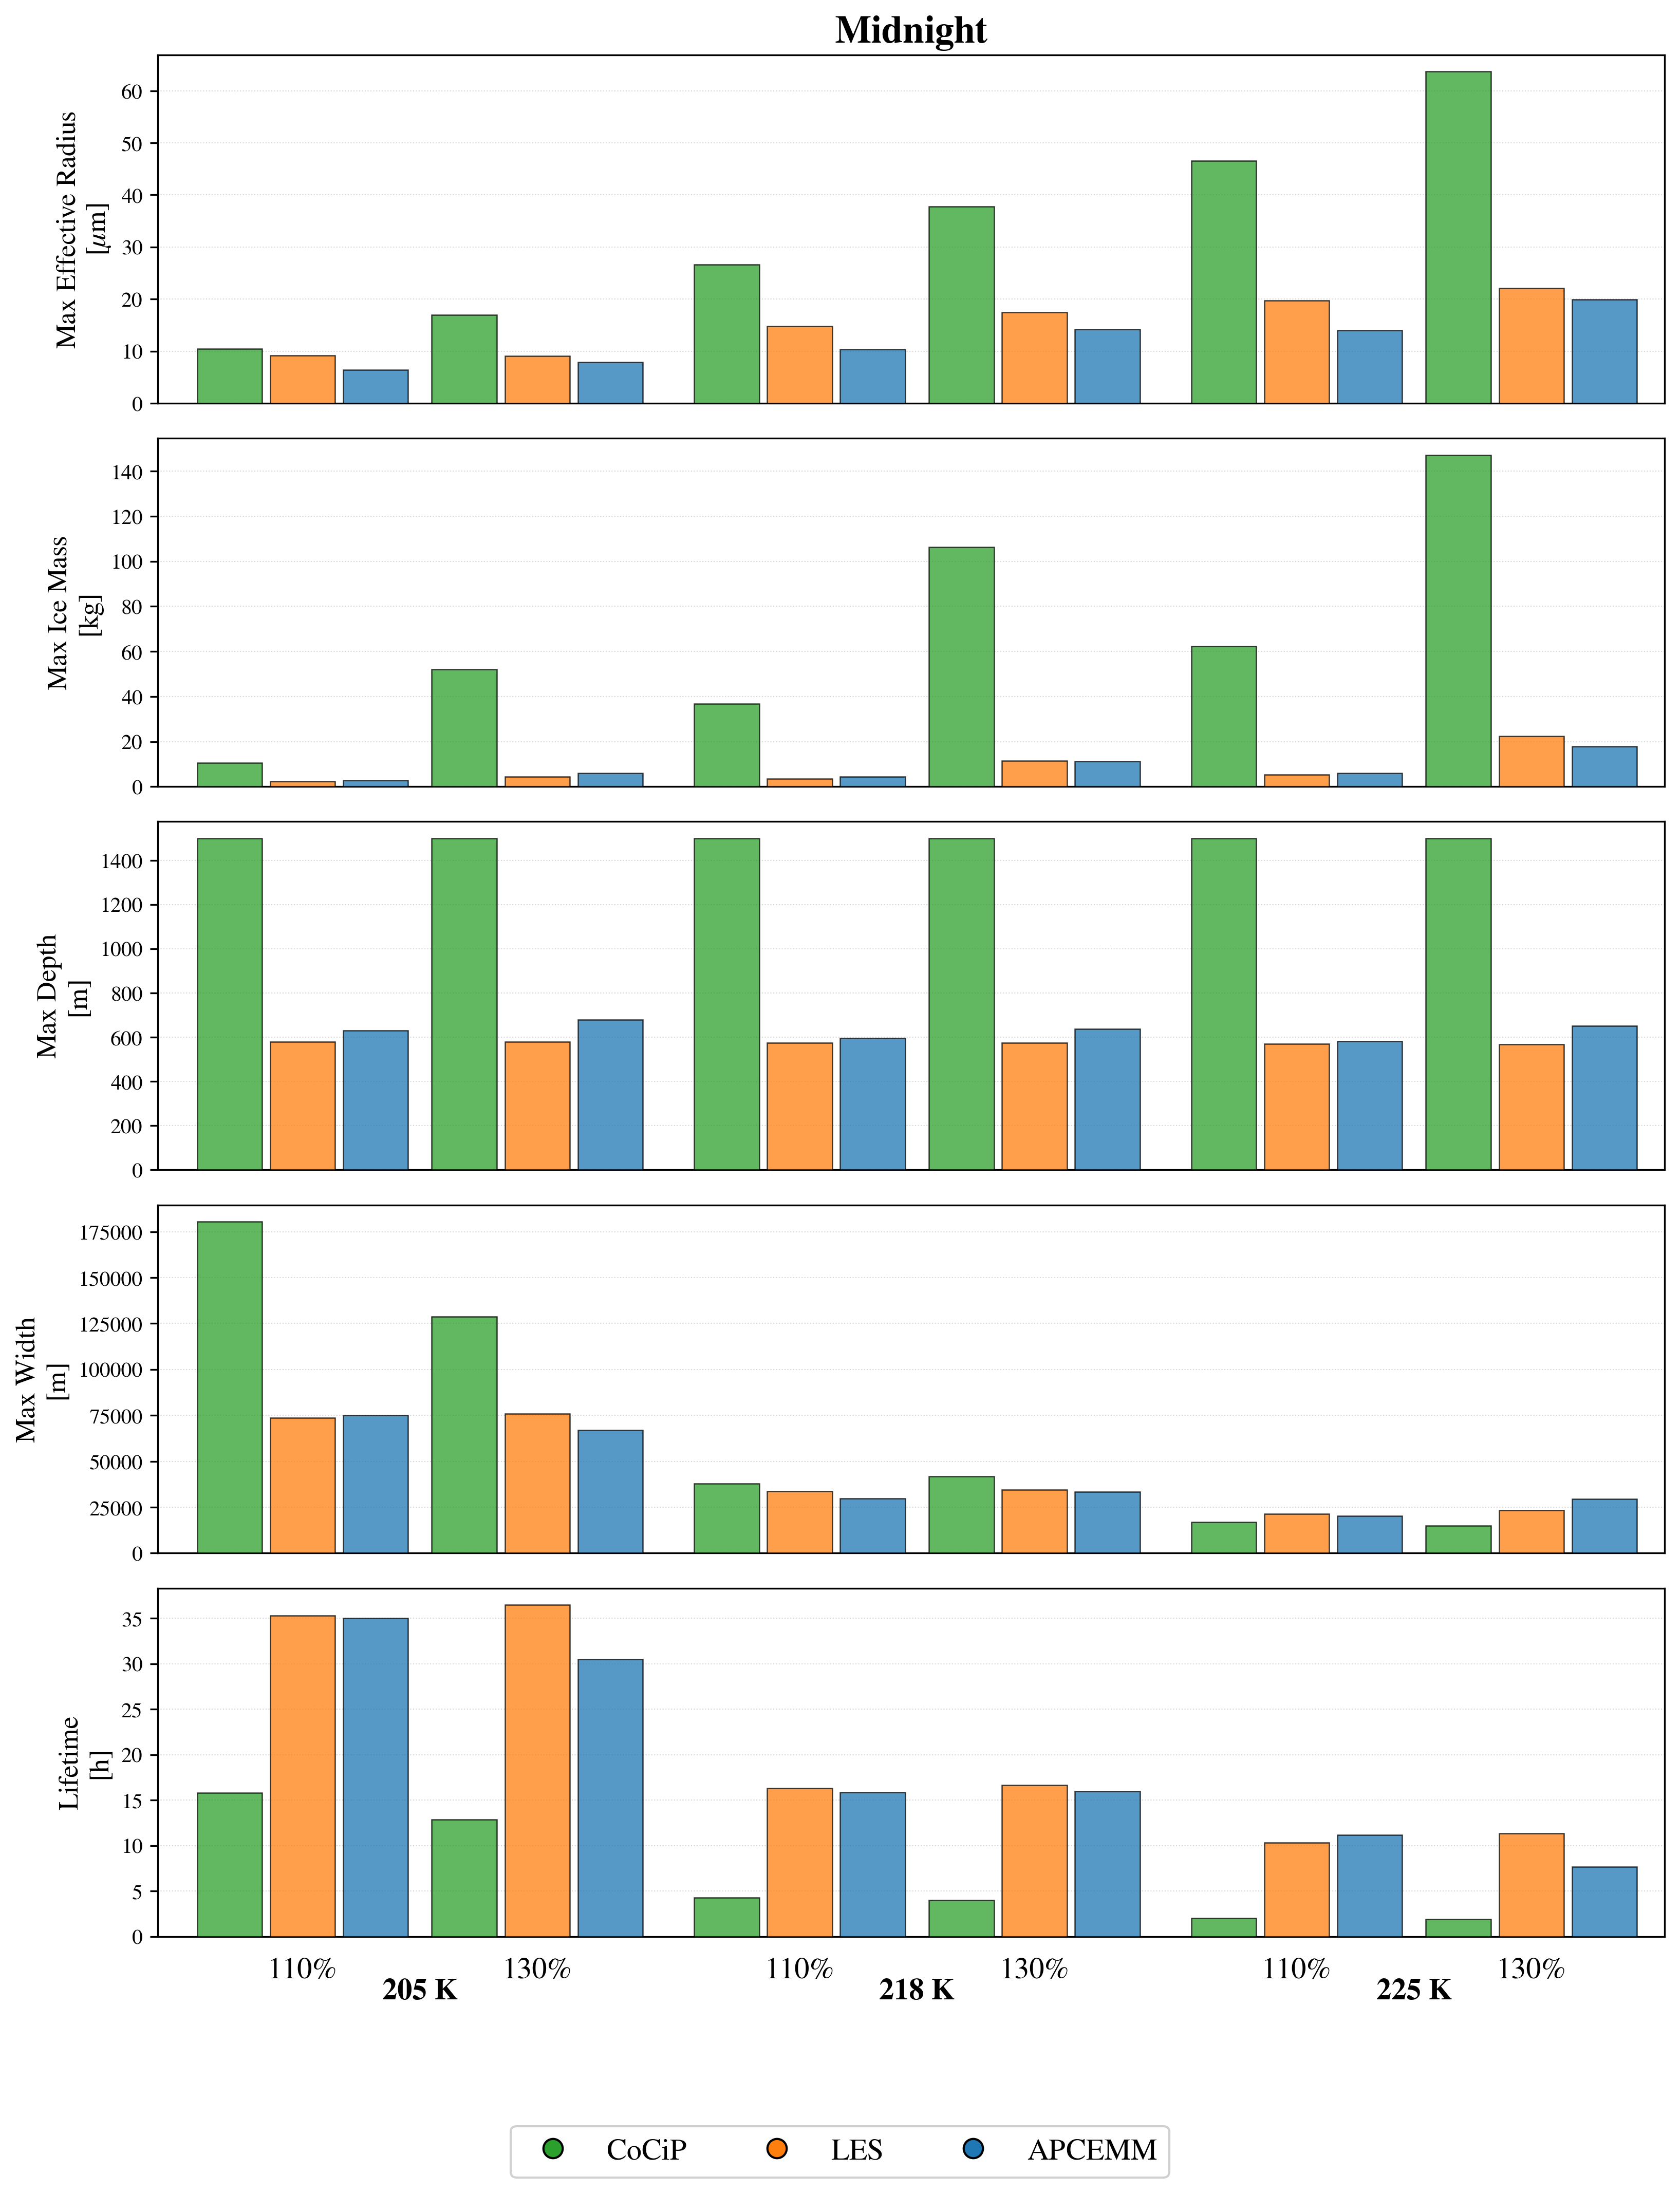

In [61]:
"""
Small-multiples bar chart of contrail properties (radius, mass, depth,
lifetime) at hour = 0 only, laid out identically to the EF bar chart's
x-axis (temperature/RHI groups, one cluster per model), but each variable
gets its own panel with real (native) units and its own y-axis.

    - rows: one panel per variable (radius, mass, depth, lifetime)
    - x-axis: same grouped T / RHI layout as the bar chart
    - bar color: model (CoCiP / LES / APCEMM)

Assumes the following already exist in the calling namespace (same as the
bar-chart script this mirrors):
    test_ids, hours, model_order, groups, group_starts,
    model_cluster_w, model_gap, group_gap, x_left, x_right,
    get_ds(m, tid, hour, habit), get_age_coord(ds, m),
    model_edge_colors, flush_temp_label
    rho_ice   (ice density, kg/m^3, needed for CoCiP mass calc)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

HOUR = 0  # only plotting midnight per current request

# ── variable / marker definitions ────────────────────────────────────────────
variables = ['radius', 'mass', 'depth', 'width', 'lifetime']
var_labels = {
    'radius':   'Max Effective Radius',
    'mass':     'Max Ice Mass',
    'depth':    'Max Depth',
    'width':    'Max Width',
    'lifetime': 'Lifetime',
}
var_units = {
    'radius':   r'$\mu$m',
    'mass':     'kg',
    'depth':    'm',
    'width':    'm',
    'lifetime': 'h',
}
var_markers = {
    'radius':   'o',
    'mass':     's',
    'depth':    'D',
    'width':    '^',
    'lifetime': '*',
}
var_marker_size = {
    'radius': 45, 'mass': 45, 'depth': 45, 'width': 45, 'lifetime': 80,
}

HABIT = 'ghm'  # matches the single habit used in the print snippet


# ── extract raw property values per (tid, model) at HOUR ────────────────────
def get_property_values(m, tid, hour):
    """Return dict of raw values for one model/tid/hour, or None if
    data is unavailable."""
    ds = get_ds(m, tid, hour, HABIT)
    if ds is None:
        return None

    age = get_age_coord(ds, m)
    if len(age) == 0:
        return None
    lifetime = float(age[-1])

    try:
        if m == 'CoCiP':
            r_um  = ds['r_ice_vol'].values.astype(float) * 1e6
            n     = ds['n_ice_per_m'].values.astype(float)
            mass  = (4.0 / 3.0) * np.pi * rho_ice * (ds['r_ice_vol'].values.astype(float) ** 3) * n
            depth = ds['depth'].values.astype(float)
            width = ds['width'].values.astype(float)

        elif m == 'APCEMM':
            r_um  = ds['Effective radius AI'].values.astype(float)
            # n     = ds['Number Ice Particles'].values.astype(float)
            mass  = ds['Ice Mass'].values.astype(float)
            depth = ds['Depth AI'].values.astype(float)
            width = ds['width'].values.astype(float)

        elif m == 'LES':
            r_um  = ds['Effective radius AI'].values.astype(float)
            # n     = ds['Ice_number'].values.astype(float)
            mass  = ds['Ice_mass'].values.astype(float)
            depth = ds['Depth_m'].values.astype(float)
            width = ds['Width_m'].values.astype(float)

        else:
            raise ValueError(f"Unknown model: {m}")

    except KeyError as e:
        print(f"Missing variable {e} for {m}/{tid}/{hour}h — skipping")
        return None

    if len(r_um) == 0 or len(mass) == 0 or len(depth) == 0:
        return None

    return {
        'radius':   float(np.nanmax(r_um)),
        'mass':     float(np.nanmax(mass)),
        'depth':    float(np.nanmax(depth)),
        'width':    float(np.nanmax(width)),  # alias for depth
        'lifetime': lifetime,
    }


# ── gather all raw values across models / tids at HOUR ───────────────────────
raw = {}  # raw[(tid, m)] = {var: value}
for tid in test_ids:
    for m in model_order:
        vals = get_property_values(m, tid, HOUR)
        if vals is not None:
            raw[(tid, m)] = vals


# ── figure layout: one row per variable, single column (hour=0 only) ─────────
fig, axes = plt.subplots(len(variables), 1, figsize=(11, 14), dpi=300, sharex=True)

for ax, v in zip(axes, variables):
    for gi, (T, tid) in enumerate(groups):
        x_group = group_starts[gi]
        for mi, m in enumerate(model_order):
            key = (tid, m)
            if key not in raw:
                continue

            x_model = x_group + mi * (model_cluster_w + model_gap)
            edge_col = model_edge_colors[m]

            ax.bar(
                x_model, raw[key][v],
                width=model_cluster_w,
                align='edge',
                color=edge_col,
                edgecolor='black',
                linewidth=0.6,
                zorder=5,
                alpha=0.75,
            )

    ax.set_ylabel(f"{var_labels[v]}\n[{var_units[v]}]", fontsize=13)
    ax.set_xlim(x_left, x_right)
    ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.5)

axes[0].set_title('Midnight', fontsize=18, fontweight='bold')

# ── x-tick labels (RHI + temperature), only on the bottom panel ─────────────
bottom_ax = axes[-1]
bottom_ax.set_xticks([])

for gi, (T, tid) in enumerate(groups):
    total_w = len(model_order) * (model_cluster_w + model_gap) - model_gap
    xc = group_starts[gi] + total_w / 2
    rhi_str = tid[:3] + '%'
    bottom_ax.text(xc, -0.06, rhi_str, ha='center', va='top', fontsize=14,
                    transform=bottom_ax.get_xaxis_transform(), clip_on=False)

prev_T, block_start_x = None, None
for gi, (T, tid) in enumerate(groups):
    if T != prev_T:
        if prev_T is not None:
            flush_temp_label(bottom_ax, prev_T, block_start_x,
                              group_starts[gi - 1] + len(model_order) * (model_cluster_w + model_gap) - model_gap)
        block_start_x = group_starts[gi]
        prev_T = T
flush_temp_label(bottom_ax, prev_T, block_start_x,
                  group_starts[-1] + len(model_order) * (model_cluster_w + model_gap) - model_gap)

# ── legend: model = color (marker shape is fixed per row, so just show model) ─
model_handles = [
    mlines.Line2D([0], [0], marker='o', linestyle='None',
                  markerfacecolor=model_edge_colors[m], markeredgecolor='black',
                  markersize=9, label=m)
    for m in model_order
]

fig.legend(
    handles=model_handles,
    loc='lower center',
    ncol=3,
    fontsize=14,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.02),
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

In [54]:
# Print max values for depth, lifetime, mass, and radius for each tid and model

for tid in test_ids:
    for m in model_order:
        for hour in [0]:
            ds = get_ds(m, tid, hour, 'ghm')

            if m == 'CoCiP':
                r_co_um = ds["r_ice_vol"].values * 1e6
                n_co = ds["n_ice_per_m"].values
                m_co = (4.0 / 3.0) * np.pi * rho_ice * (ds["r_ice_vol"].values**3) * n_co

                max_age = get_age_coord(ds, m)[-1]
                max_depth = ds['depth'].values.max()
                max_radius = r_co_um.max()
                max_mass = m_co.max()

            if m == 'APCEMM':
                r_ap_um = np.array(ds["Effective radius AI"].values, dtype=float)
                n_ap = np.array(ds["Number Ice Particles"].values, dtype=float)
                m_ap = np.array(ds["Ice Mass"].values, dtype=float)
    
                max_age = get_age_coord(ds, m)[-1]
                max_depth = ds['Depth AI'].values.max()
                max_radius = r_ap_um.max()
                max_mass = m_ap.max()

            if m == 'LES':
                r_les_um = np.array(ds["Effective radius AI"].values, dtype=float)
                n_les = np.array(ds["Ice_number"].values, dtype=float)
                m_les = np.array(ds["Ice_mass"].values, dtype=float)

                max_age = get_age_coord(ds, m)[-1]
                max_depth = ds['Depth_m'].values.max()
                max_radius = r_les_um.max()
                max_mass = m_les.max()

            print(f"TID: {tid}, Model: {m}, Hour: {hour}h, Max Age: {max_age:.2f}h, Max Depth: {max_depth:.2f}m, Max Radius: {max_radius:.2f}μm, Max Mass: {max_mass:.2e}kg")

            # Plot the max values for depth, lifetime, mass, and radius for each tid and model

TID: 110T205L25, Model: CoCiP, Hour: 0h, Max Age: 15.82h, Max Depth: 1500.00m, Max Radius: 10.43μm, Max Mass: 1.06e+01kg
TID: 110T205L25, Model: LES, Hour: 0h, Max Age: 35.33h, Max Depth: 578.12m, Max Radius: 9.16μm, Max Mass: 2.22e+00kg
TID: 110T205L25, Model: APCEMM, Hour: 0h, Max Age: 35.00h, Max Depth: 630.00m, Max Radius: 6.39μm, Max Mass: 2.74e+00kg
TID: 110T218L25, Model: CoCiP, Hour: 0h, Max Age: 4.25h, Max Depth: 1500.00m, Max Radius: 26.62μm, Max Mass: 3.67e+01kg
TID: 110T218L25, Model: LES, Hour: 0h, Max Age: 16.33h, Max Depth: 573.57m, Max Radius: 14.83μm, Max Mass: 3.52e+00kg
TID: 110T218L25, Model: APCEMM, Hour: 0h, Max Age: 15.83h, Max Depth: 595.00m, Max Radius: 10.33μm, Max Mass: 4.32e+00kg
TID: 110T225L25, Model: CoCiP, Hour: 0h, Max Age: 2.02h, Max Depth: 1500.00m, Max Radius: 46.54μm, Max Mass: 6.22e+01kg
TID: 110T225L25, Model: LES, Hour: 0h, Max Age: 10.33h, Max Depth: 570.77m, Max Radius: 19.71μm, Max Mass: 5.39e+00kg
TID: 110T225L25, Model: APCEMM, Hour: 0h, Max

### Normalized by width

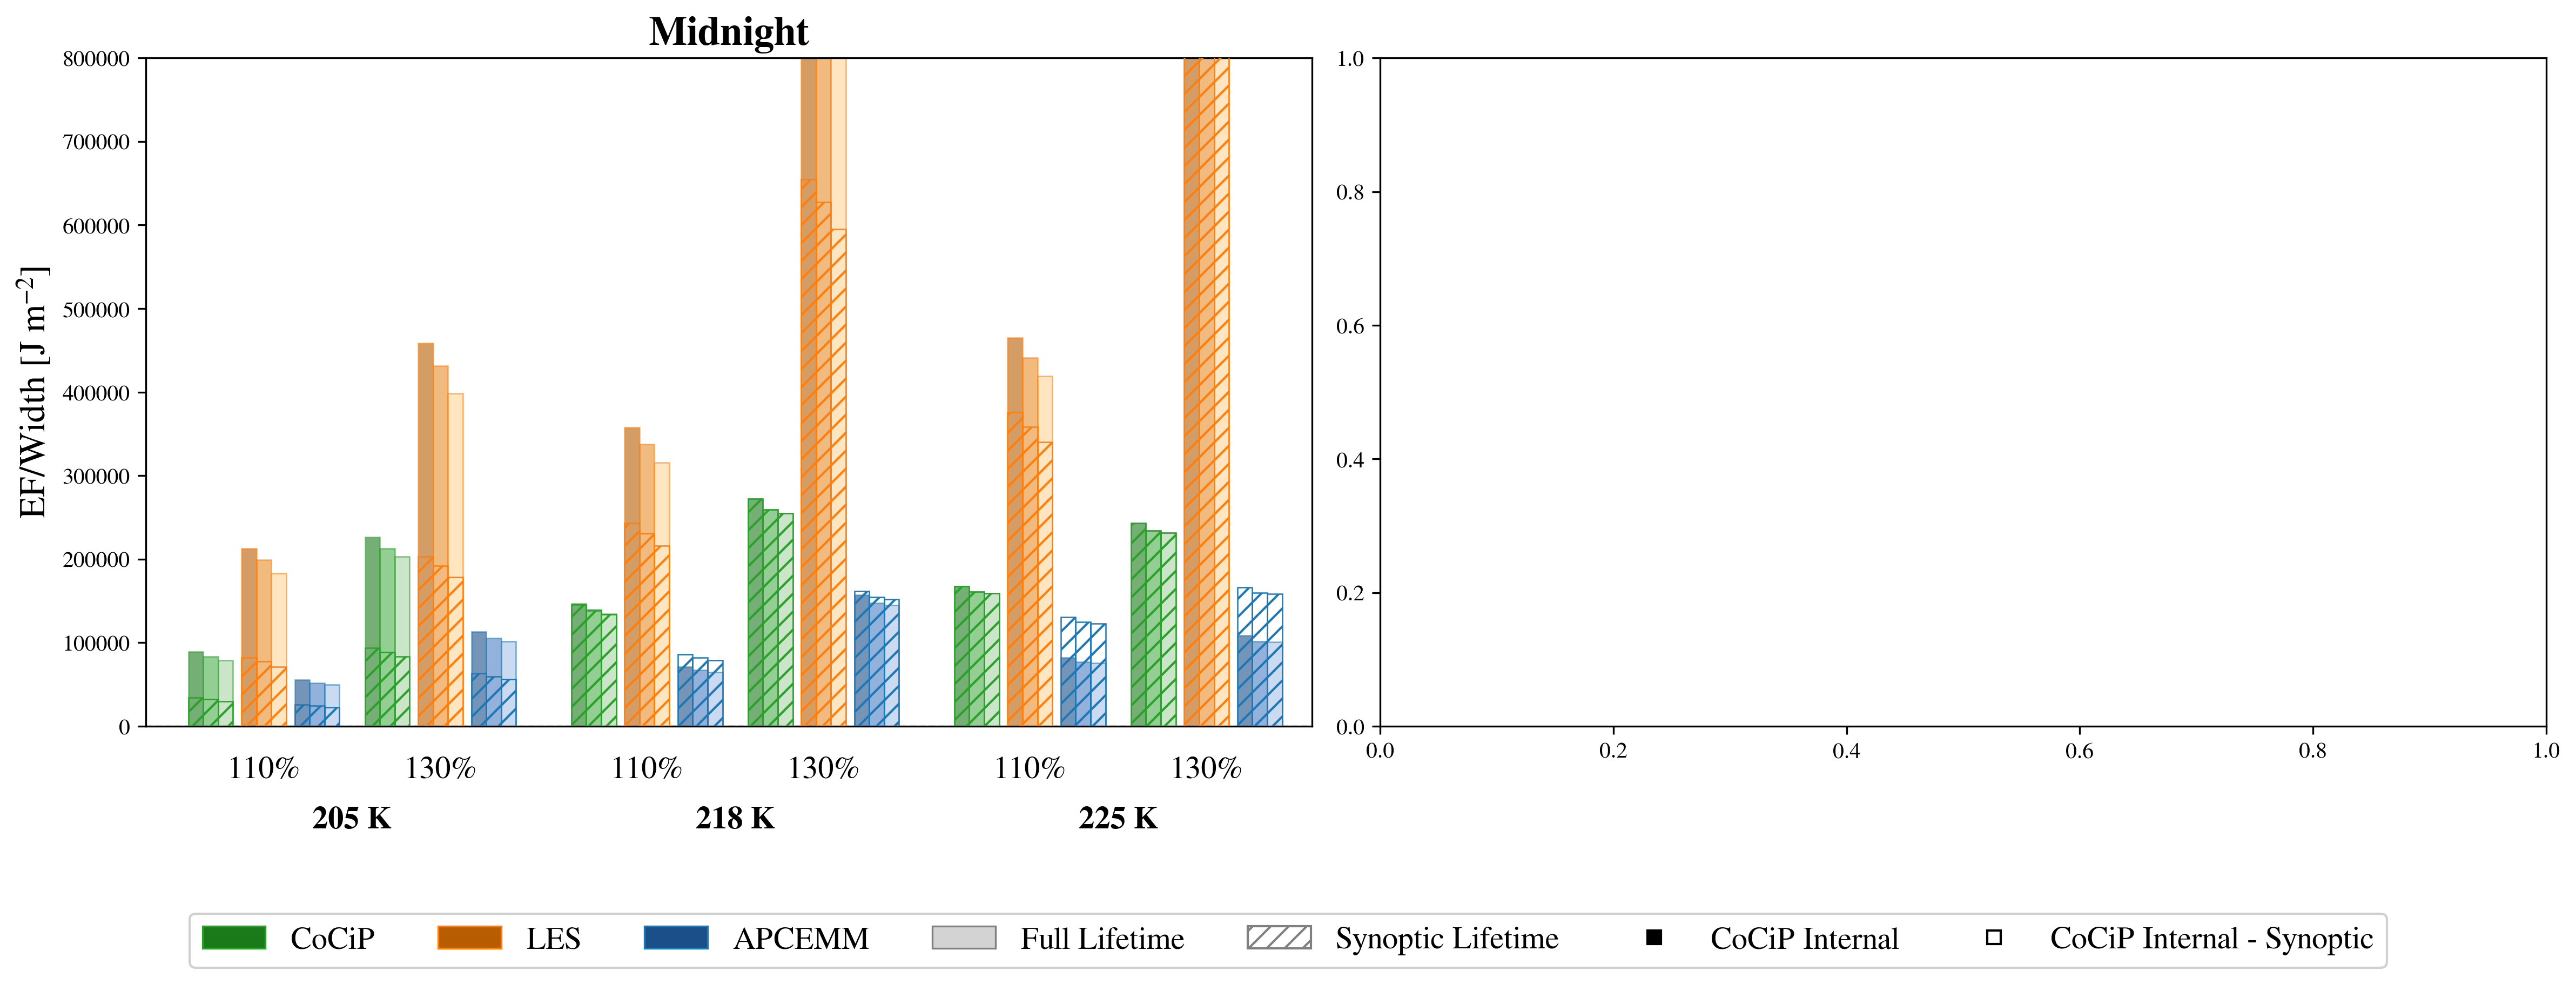

In [13]:
# ── data paths & keys ────────────────────────────────────────────────────────
test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']
hours    = [0]
habits   = ['solid-column', 'ghm', 'rough-aggregate']
base_dir = '/home/chinahg/GCresearch/contrailuncertainty/LRT/RF_EF_results'

TARGET_AGE_H = 4.0
DELTA_T = 10 * 60 # 10 minutes in seconds

# ── accumulate per-habit EF values ───────────────────────────────────────────
# Keyed by (tid, model, hour, habit) — one scalar each
per_case    = {tid: {m: {h: {hab: None for hab in habits} for h in hours} for m in ['APCEMM', 'CoCiP', 'LES']} for tid in test_ids}
per_case_4h = {tid: {m: {h: {hab: None for hab in habits} for h in hours} for m in ['APCEMM', 'CoCiP', 'LES']} for tid in test_ids}

for m in ['APCEMM', 'CoCiP', 'LES']:
    for tid in test_ids:
        for hour in hours:
            for habit in habits:
                ds = get_ds(m, tid, hour, habit)
                if ds is None:
                    continue

                age     = get_age_coord(ds, m)

                # Normalize by width
                if hour == 0:
                    ef_vals = np.cumsum(ds['LW RF midnight'].values.astype(float) * DELTA_T)
                elif hour == 12:
                    ef_vals = np.cumsum((ds['LW RF noon'].values.astype(float) + ds['SW RF noon'].values.astype(float)) * DELTA_T)
                else:
                    print('Hour but be 0 or 12')

                # full run: last EF value (remove index-0 for APCEMM)
                ef_full = (ef_vals[1:] - ef_vals[0]) if (m == 'APCEMM' and len(ef_vals) > 1) else ef_vals
                if len(ef_full) > 0:
                    per_case[tid][m][hour][habit] = float(ef_full[-1])

                # 4h truncated: last EF value at or before 4 h
                ef_4h = ef_vals[age <= TARGET_AGE_H]
                if len(ef_4h) > 0:
                    per_case_4h[tid][m][hour][habit] = float(ef_4h[-1])

# ── color definitions ─────────────────────────────────────────────────────────
# Three shades per model: dark → mid → light for ghm → solid-column → rough-aggregate
model_habit_colors = {
    'CoCiP':  {'solid-column': '#1a7a1a', 'ghm': '#4caf4c', 'rough-aggregate': '#a8d5a2'},
    'LES':    {'solid-column': '#b85c00', 'ghm': '#e88c2a', 'rough-aggregate': '#ffd699'},
    'APCEMM': {'solid-column': '#1a4f8a', 'ghm': '#4a80c4', 'rough-aggregate': '#a8c4e8'},
}
model_edge_colors = {'CoCiP': 'tab:green', 'LES': 'tab:orange', 'APCEMM': 'tab:blue'}

# ── layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300, sharey=False)

temps_unique = sorted({int(tid.split('T')[1].split('L')[0]) for tid in test_ids})

groups = []
for T in temps_unique:
    for tid in sorted([t for t in test_ids if f"T{T}" in t],
                      key=lambda s: int(s[:3])):
        groups.append((T, tid))

model_order  = ['CoCiP', 'LES', 'APCEMM']
n_models     = len(model_order)
n_habits     = len(habits)
sub_bar_w    = 0.07   # width of each individual habit bar
model_gap    = 0.04   # gap between model clusters
group_gap    = 0.14   # extra gap between temperature groups

model_cluster_w = n_habits * sub_bar_w  # total width of one model's 3 bars

def group_x_positions(groups):
    x0, positions, prev_T = 0.0, [], None
    for (T, tid) in groups:
        if prev_T is not None and T != prev_T:
            x0 += group_gap
        positions.append(x0)
        x0 += n_models * (model_cluster_w + model_gap) + 0.08
        prev_T = T
    return positions

group_starts = group_x_positions(groups)

x_left  = -0.2
x_right = group_starts[-1] + n_models * (model_cluster_w + model_gap) + 0.1

# ── draw bars ─────────────────────────────────────────────────────────────────
def draw_bars(ax, hour):
    for gi, (T, tid) in enumerate(groups):
        x_group = group_starts[gi]
        for mi, m in enumerate(model_order):
            x_model = x_group + mi * (model_cluster_w + model_gap)
            edge_col = model_edge_colors[m]

            for hi, habit in enumerate(habits):
                xc        = x_model + hi * sub_bar_w
                xc_center = xc + sub_bar_w / 2
                fill_col  = model_habit_colors[m][habit]

                # ---- full run bar ----
                yf = per_case[tid][m][hour][habit]
                if yf is not None:
                    ax.bar(xc, abs(yf), bottom=min(yf, 0), width=sub_bar_w,
                           align='edge', color=fill_col, edgecolor=edge_col,
                           linewidth=0.6, zorder=2, alpha=0.6)

                # ---- 4h truncated overlay (hatch, no fill) ----
                y4 = per_case_4h[tid][m][hour][habit]
                if y4 is not None:
                    ax.bar(xc, abs(y4), bottom=min(y4, 0), width=sub_bar_w,
                           align='edge', color='None', edgecolor=edge_col,
                           linewidth=0.6, hatch='///', zorder=3)

# ── main panels ───────────────────────────────────────────────────────────────
panel_info = list(zip(axes, hours, ['Midnight', 'Noon']))

for ax, hour, title in panel_info:
    draw_bars(ax, hour)

    ax.axhline(0, color='gray', linestyle='--', lw=0.8)
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xticks([])
    ax.set_xlim(x_left, x_right)

# ── y limits ──────────────────────────────────────────────────────────────────

ax.set_ylim(0, 8e5)

ax.set_yscale('linear')

axes[0].set_ylabel('EF/Width [J m$^{-2}$]', fontsize=16)

# ── x-tick labels ─────────────────────────────────────────────────────────────
for ax, hour, title in panel_info:

    # RHI labels — centred on the full group of 3 model clusters
    for gi, (T, tid) in enumerate(groups):
        total_w = n_models * (model_cluster_w + model_gap) - model_gap
        xc = group_starts[gi] + total_w / 2
        rhi_str = tid[:3] + '%'
        ax.text(xc, -0.045, rhi_str, ha='center', va='top', fontsize=14,
                transform=ax.get_xaxis_transform(), clip_on=False)

    # Temperature labels
    prev_T, block_start_x = None, None

    def flush_temp_label(ax, T, bsx, bex):
        ax.text((bsx + bex) / 2, -0.12, f'{T} K',
                ha='center', va='top', fontsize=14, fontweight='bold',
                transform=ax.get_xaxis_transform(), clip_on=False)

    for gi, (T, tid) in enumerate(groups):
        if T != prev_T:
            if prev_T is not None:
                flush_temp_label(ax, prev_T, block_start_x,
                                 group_starts[gi - 1] + n_models * (model_cluster_w + model_gap) - model_gap)
            block_start_x = group_starts[gi]
            prev_T = T

    flush_temp_label(ax, prev_T, block_start_x,
                     group_starts[-1] + n_models * (model_cluster_w + model_gap) - model_gap)

# ── legend ────────────────────────────────────────────────────────────────────
# Model patches (mid shade)
model_handles = [
    mpatches.Patch(facecolor=model_habit_colors[m]['solid-column'],
                   edgecolor=model_edge_colors[m], linewidth=0.8, label=m)
    for m in model_order
]

# Habit shade patches (using APCEMM palette as neutral reference)
habit_labels = {'ghm': 'GHM', 'solid-column': 'Solid Column', 'rough-aggregate': 'Rough Aggregate'}
habit_handles = [
    mpatches.Patch(facecolor=model_habit_colors['APCEMM'][hab],
                   edgecolor=model_edge_colors['APCEMM'], linewidth=0.8,
                   label=habit_labels[hab])
    for hab in habits
]

full_patch = mpatches.Patch(facecolor='lightgray', edgecolor='gray',
                             linewidth=0.8, label='Full Lifetime')
trunc_patch = mpatches.Patch(facecolor='None', edgecolor='gray',
                              hatch='///', label='Synoptic Lifetime')

fig.legend(
    handles=model_handles + [full_patch, trunc_patch,
                                              internal_none_handle, internal_4h_handle],
    loc='lower center',
    ncol=7,
    fontsize=14,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.02)
)

# ── final layout ──────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

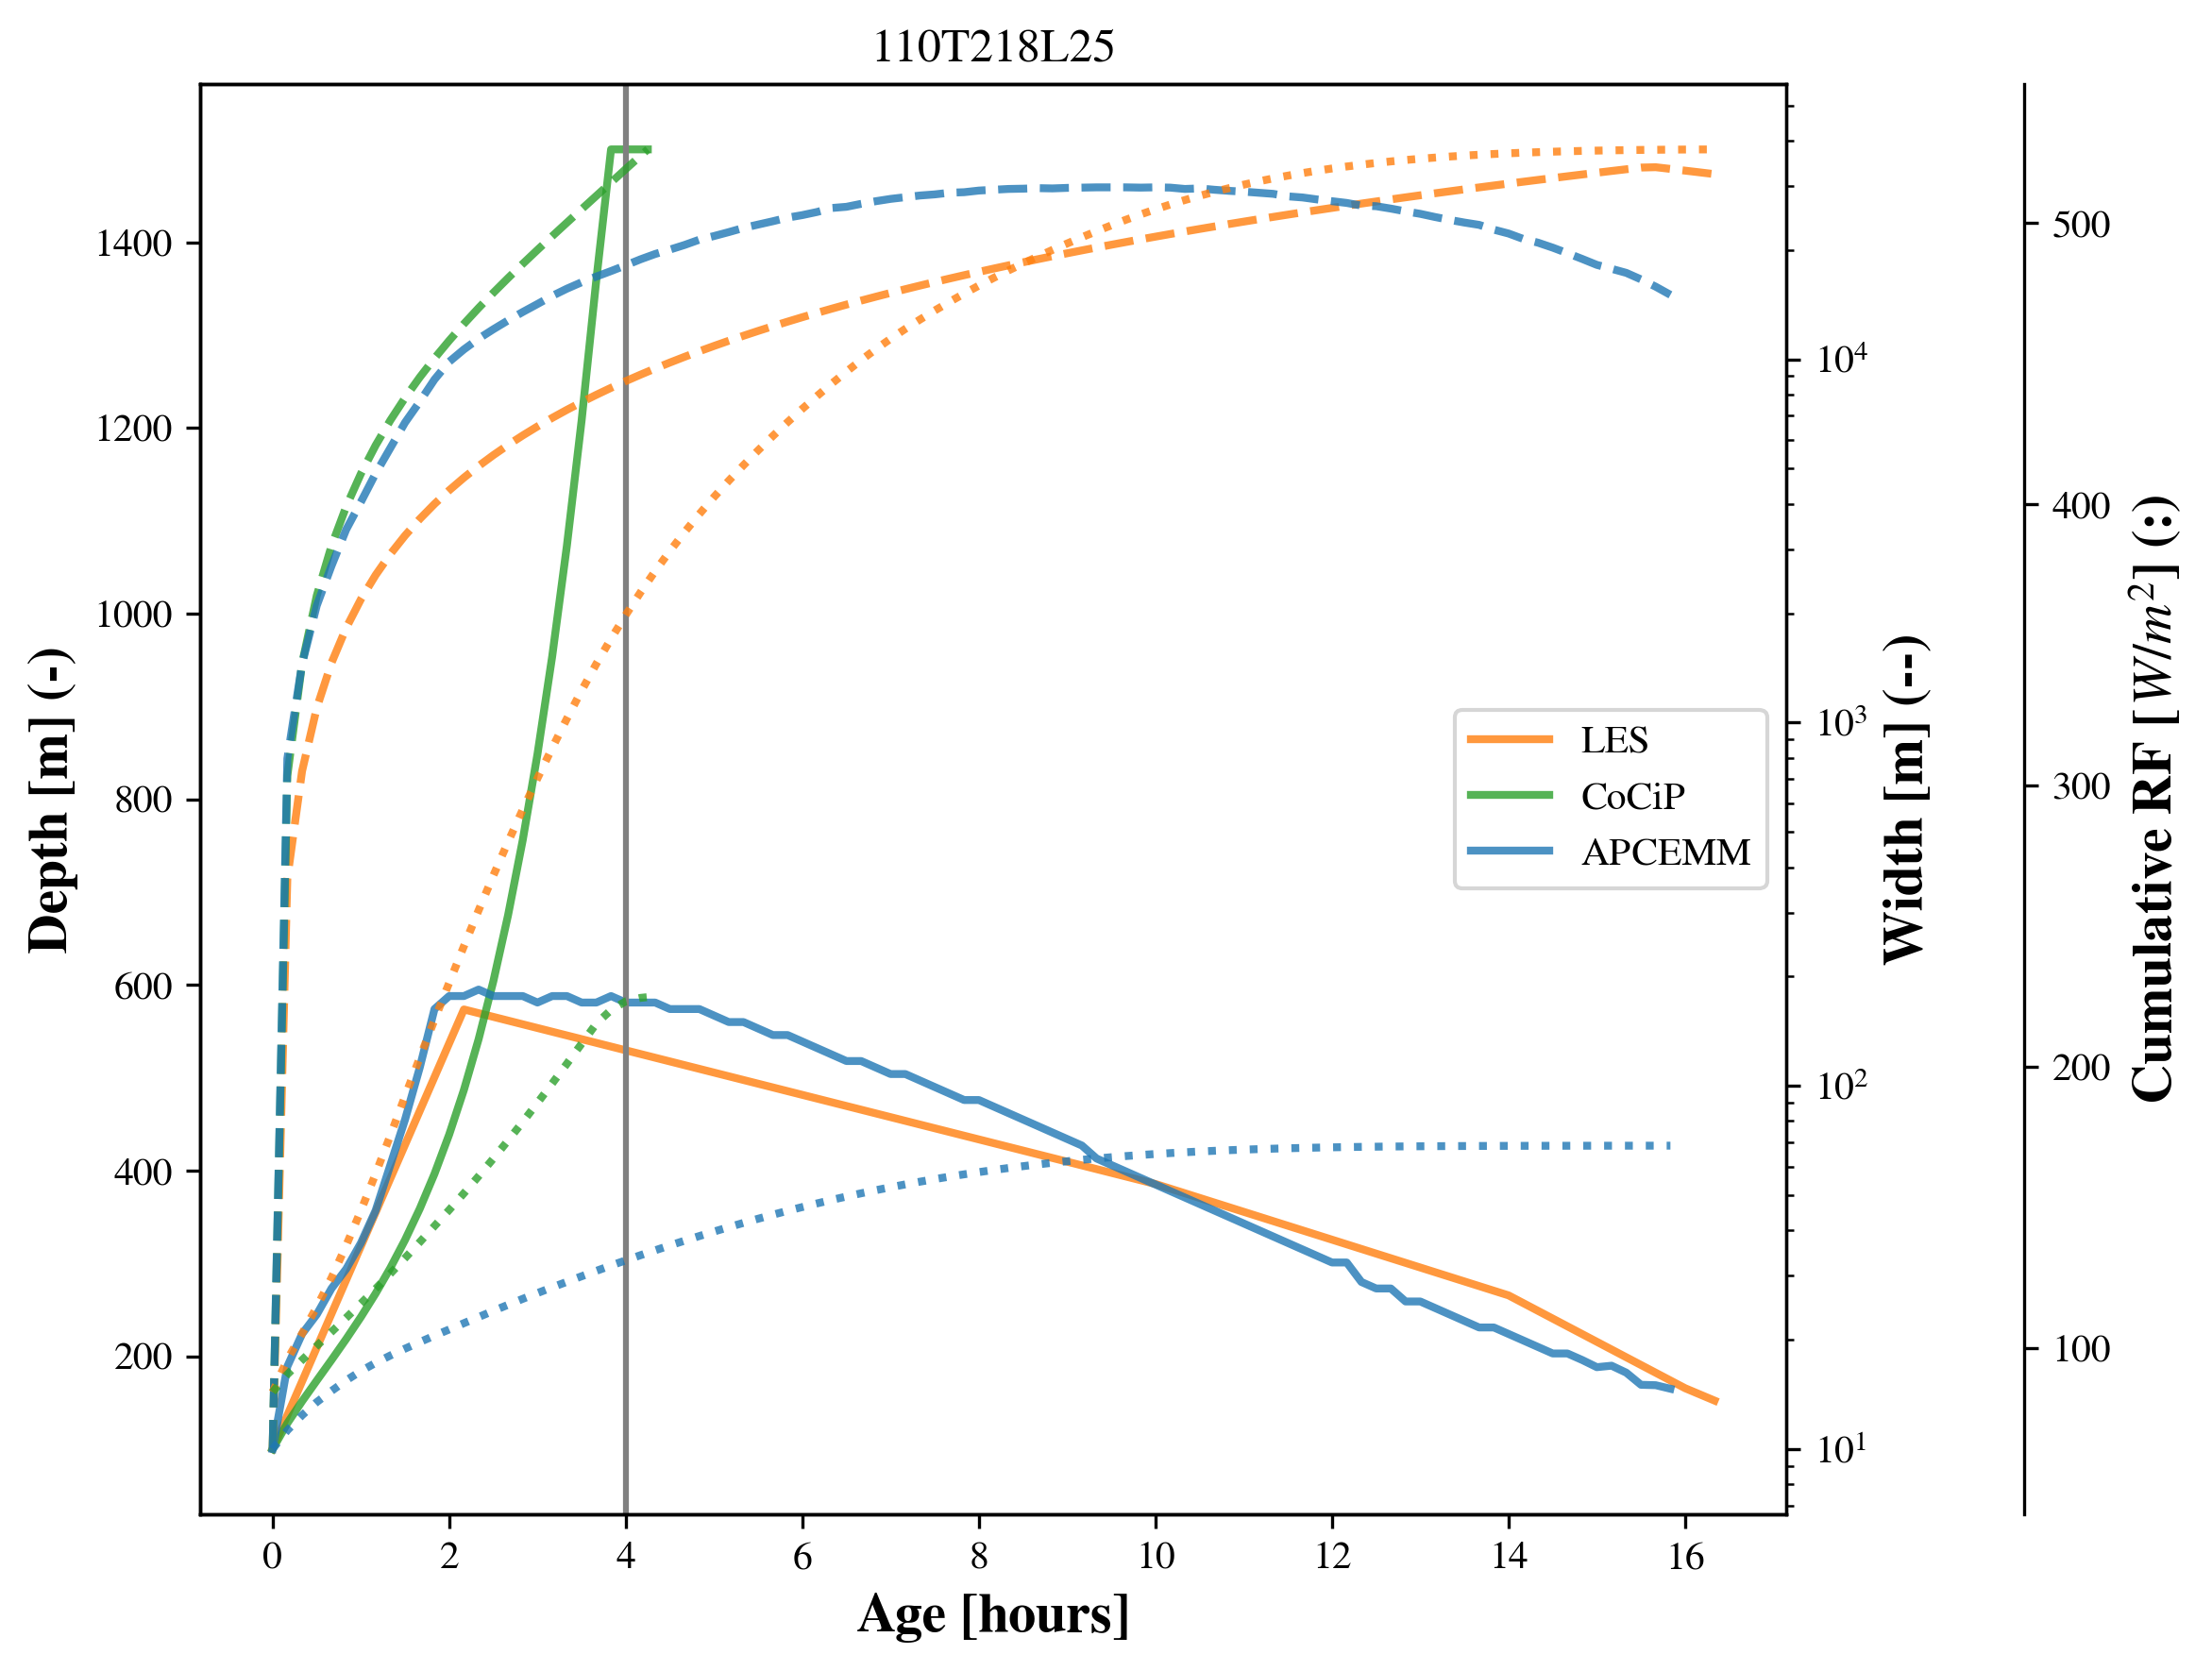

In [14]:
cases = ['110T218L25']
fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.15))

habit = 'rough-aggregate' # Plotted data is habit independent
tod = '0'
models = ['LES', 'CoCiP', 'APCEMM']
case_ls = {'110T205L25': '-', '130T205L25': '--'}

LES_var_names = ['Depth_m', 'Width_m', 'cs RF']
cocip_var_names = ['depth', 'width', 'cs RF']
APCEMM_var_names = ['depth', 'width', 'cs RF']

var_ls = {'Depth_m': '-', 
          'Width_m': '--',
          'depth': '-',
          'width': '--', 
          'cs RF': ':'
        }

axes_map = {0: ax1, 1: ax2, 2: ax3}

for model in models:
    for case in cases:
        if model == 'APCEMM':
            ds = apcemm_data.get((case, int(tod), habit))
            time_name = 't'
            vars = APCEMM_var_names
        elif model == 'LES':
            ds = les_data.get((case, int(tod), habit))
            time_name = 'time'
            vars = LES_var_names
        elif model == 'CoCiP':
            ds = cocip_data.get((case, int(tod), habit))
            time_name = 'age_hours'
            vars = cocip_var_names
            
        for i, var in enumerate(vars):
            ax = axes_map[i]
        
            times = ds[time_name].values

            if var == 'cs RF':
                if tod == '0':
                    var_vals = np.cumsum(ds['LW RF midnight'].values.astype(float))
                else:
                    if model == 'APCEMM' and (case == '110T205L25' or case == '130T205L25'):
                        var_vals = np.cumsum(ds['LW RF midnight'].values.astype(float) + ds['SW RF noon'].values.astype(float))
                    else:
                        var_vals = np.cumsum(ds['LW RF noon'].values.astype(float) + ds['SW RF noon'].values.astype(float))
            else:
                var_vals = ds[var].values.astype(float)
            if model == 'APCEMM' and var == 'Effective radius slices':
                var_vals = var_vals.mean(axis=1)
            if model == 'CoCiP' and var == 'r_ice_vol':
                var_vals = var_vals * 1e6
            if model == 'APCEMM' and var == 'IWC slices':
                var_vals = var_vals.mean(axis=1)
            if model == 'CoCiP' and var == 'iwc':
                var_vals = ds[var].values * ds["rho_air"].values * 1e3

            ax.plot(times, var_vals, label=model, lw=2, color=model_colors[model], alpha=0.8, linestyle=var_ls[var])
    

ax1.set_ylabel('Depth [m] (-)', fontsize=14, fontweight="bold")
ax2.set_ylabel('Width [m] (--)', fontsize=14, fontweight="bold")
ax3.set_ylabel('Cumulative RF [$W/m^{2}$] (:)', fontsize=14, fontweight="bold")
ax1.set_xlabel("Age [hours]", fontsize=14, fontweight="bold")
ax2.set_yscale("log")

handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='center right')

ax1.set_title(cases[0])

ax1.axvline(x=4, color='gray')

plt.tight_layout()
plt.show()

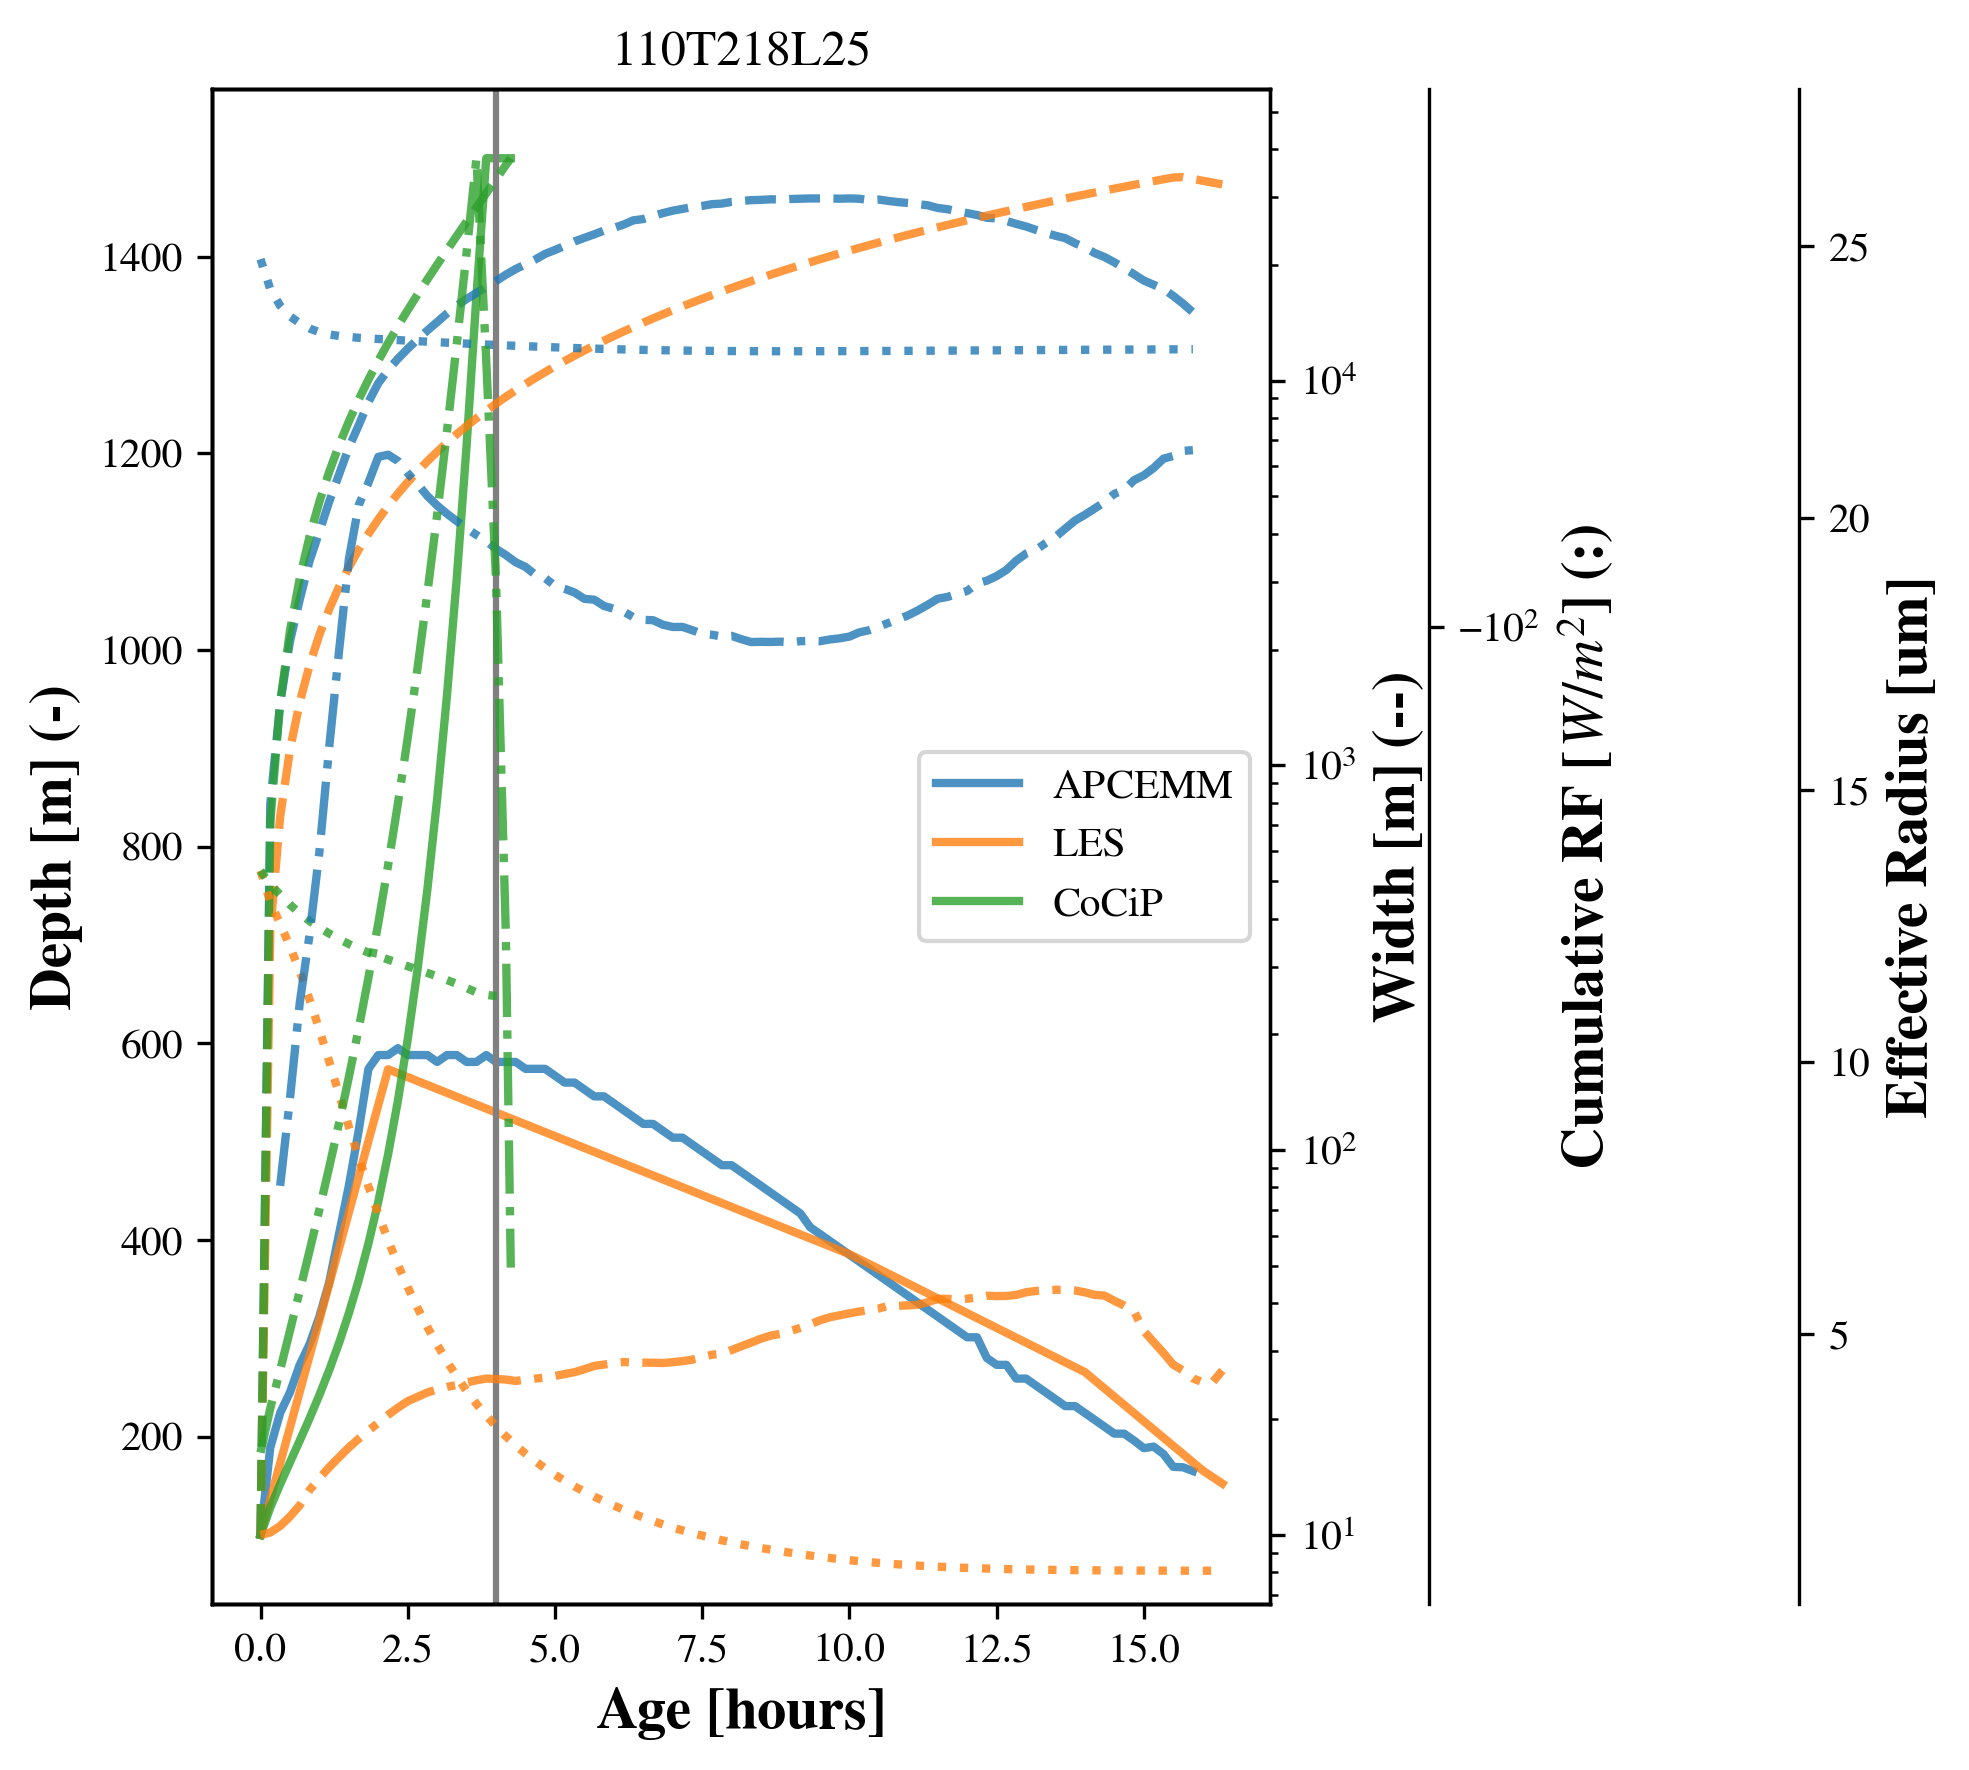

In [15]:
cases = ['110T218L25']
fig, ax1 = plt.subplots(figsize=(8, 6), dpi=300)
ax2 = ax1.twinx()
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.15))
ax4 = ax1.twinx()
ax4.spines['right'].set_position(('axes', 1.5))

habit = 'rough-aggregate' # Plotted data is habit independent
tod = '12' # Plotted data is time of day independent
models = ['APCEMM', 'LES', 'CoCiP']

LES_var_names = ['Depth_m', 'Width_m', 'cs RF', 'Effective radius slices']
cocip_var_names = ['depth', 'width', 'cs RF', 'Effective radius slices']
APCEMM_var_names = ['depth', 'width', 'cs RF', 'Effective radius slices']

var_ls = {'Depth_m': '-', 
          'Width_m': '--',
          'depth': '-',
          'width': '--', 
          'cs RF': ':',
          'Effective radius slices': '-.',
        }

axes_map = {0: ax1, 1: ax2, 2: ax3, 3: ax4}

for model in models:
    for case in cases:
        if model == 'APCEMM':
            ds = apcemm_data.get((case, int(tod), habit))
            time_name = 't'
            vars = APCEMM_var_names
        elif model == 'LES':
            ds = les_data.get((case, int(tod), habit))
            time_name = 'time'
            vars = LES_var_names
        elif model == 'CoCiP':
            ds = cocip_data.get((case, int(tod), habit))
            time_name = 'age_hours'
            vars = cocip_var_names
            
        for i, var in enumerate(vars):
            ax = axes_map[i]
        
            times = ds[time_name].values

            if var == 'cs RF':
                if tod == '0':
                    var_vals = np.cumsum(ds['LW RF midnight'].values.astype(float))
                else:
                    var_vals = np.cumsum(ds['LW RF noon'].values.astype(float) + ds['SW RF noon'].values.astype(float))
            else:
                var_vals = ds[var].values.astype(float)
            if var == 'Effective radius slices':
                var_vals = var_vals.mean(axis=1)
            if var == 'IWC slices':
                var_vals = var_vals.mean(axis=1)

            ax.plot(times, var_vals, label=model, lw=2, color=model_colors[model], alpha=0.8, linestyle=var_ls[var])
    

ax1.set_ylabel('Depth [m] (-)', fontsize=14, fontweight="bold")
ax2.set_ylabel('Width [m] (--)', fontsize=14, fontweight="bold")
ax3.set_ylabel('Cumulative RF [$W/m^{2}$] (:)', fontsize=14, fontweight="bold")
ax1.set_xlabel("Age [hours]", fontsize=14, fontweight="bold")
ax2.set_yscale("log")
ax3.set_yscale("symlog")
ax4.set_ylabel("Effective Radius [um]", fontsize=14, fontweight="bold")

handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='center right')

ax1.set_title(cases[0])

ax1.axvline(x=4, color='gray')

plt.tight_layout()
plt.show()

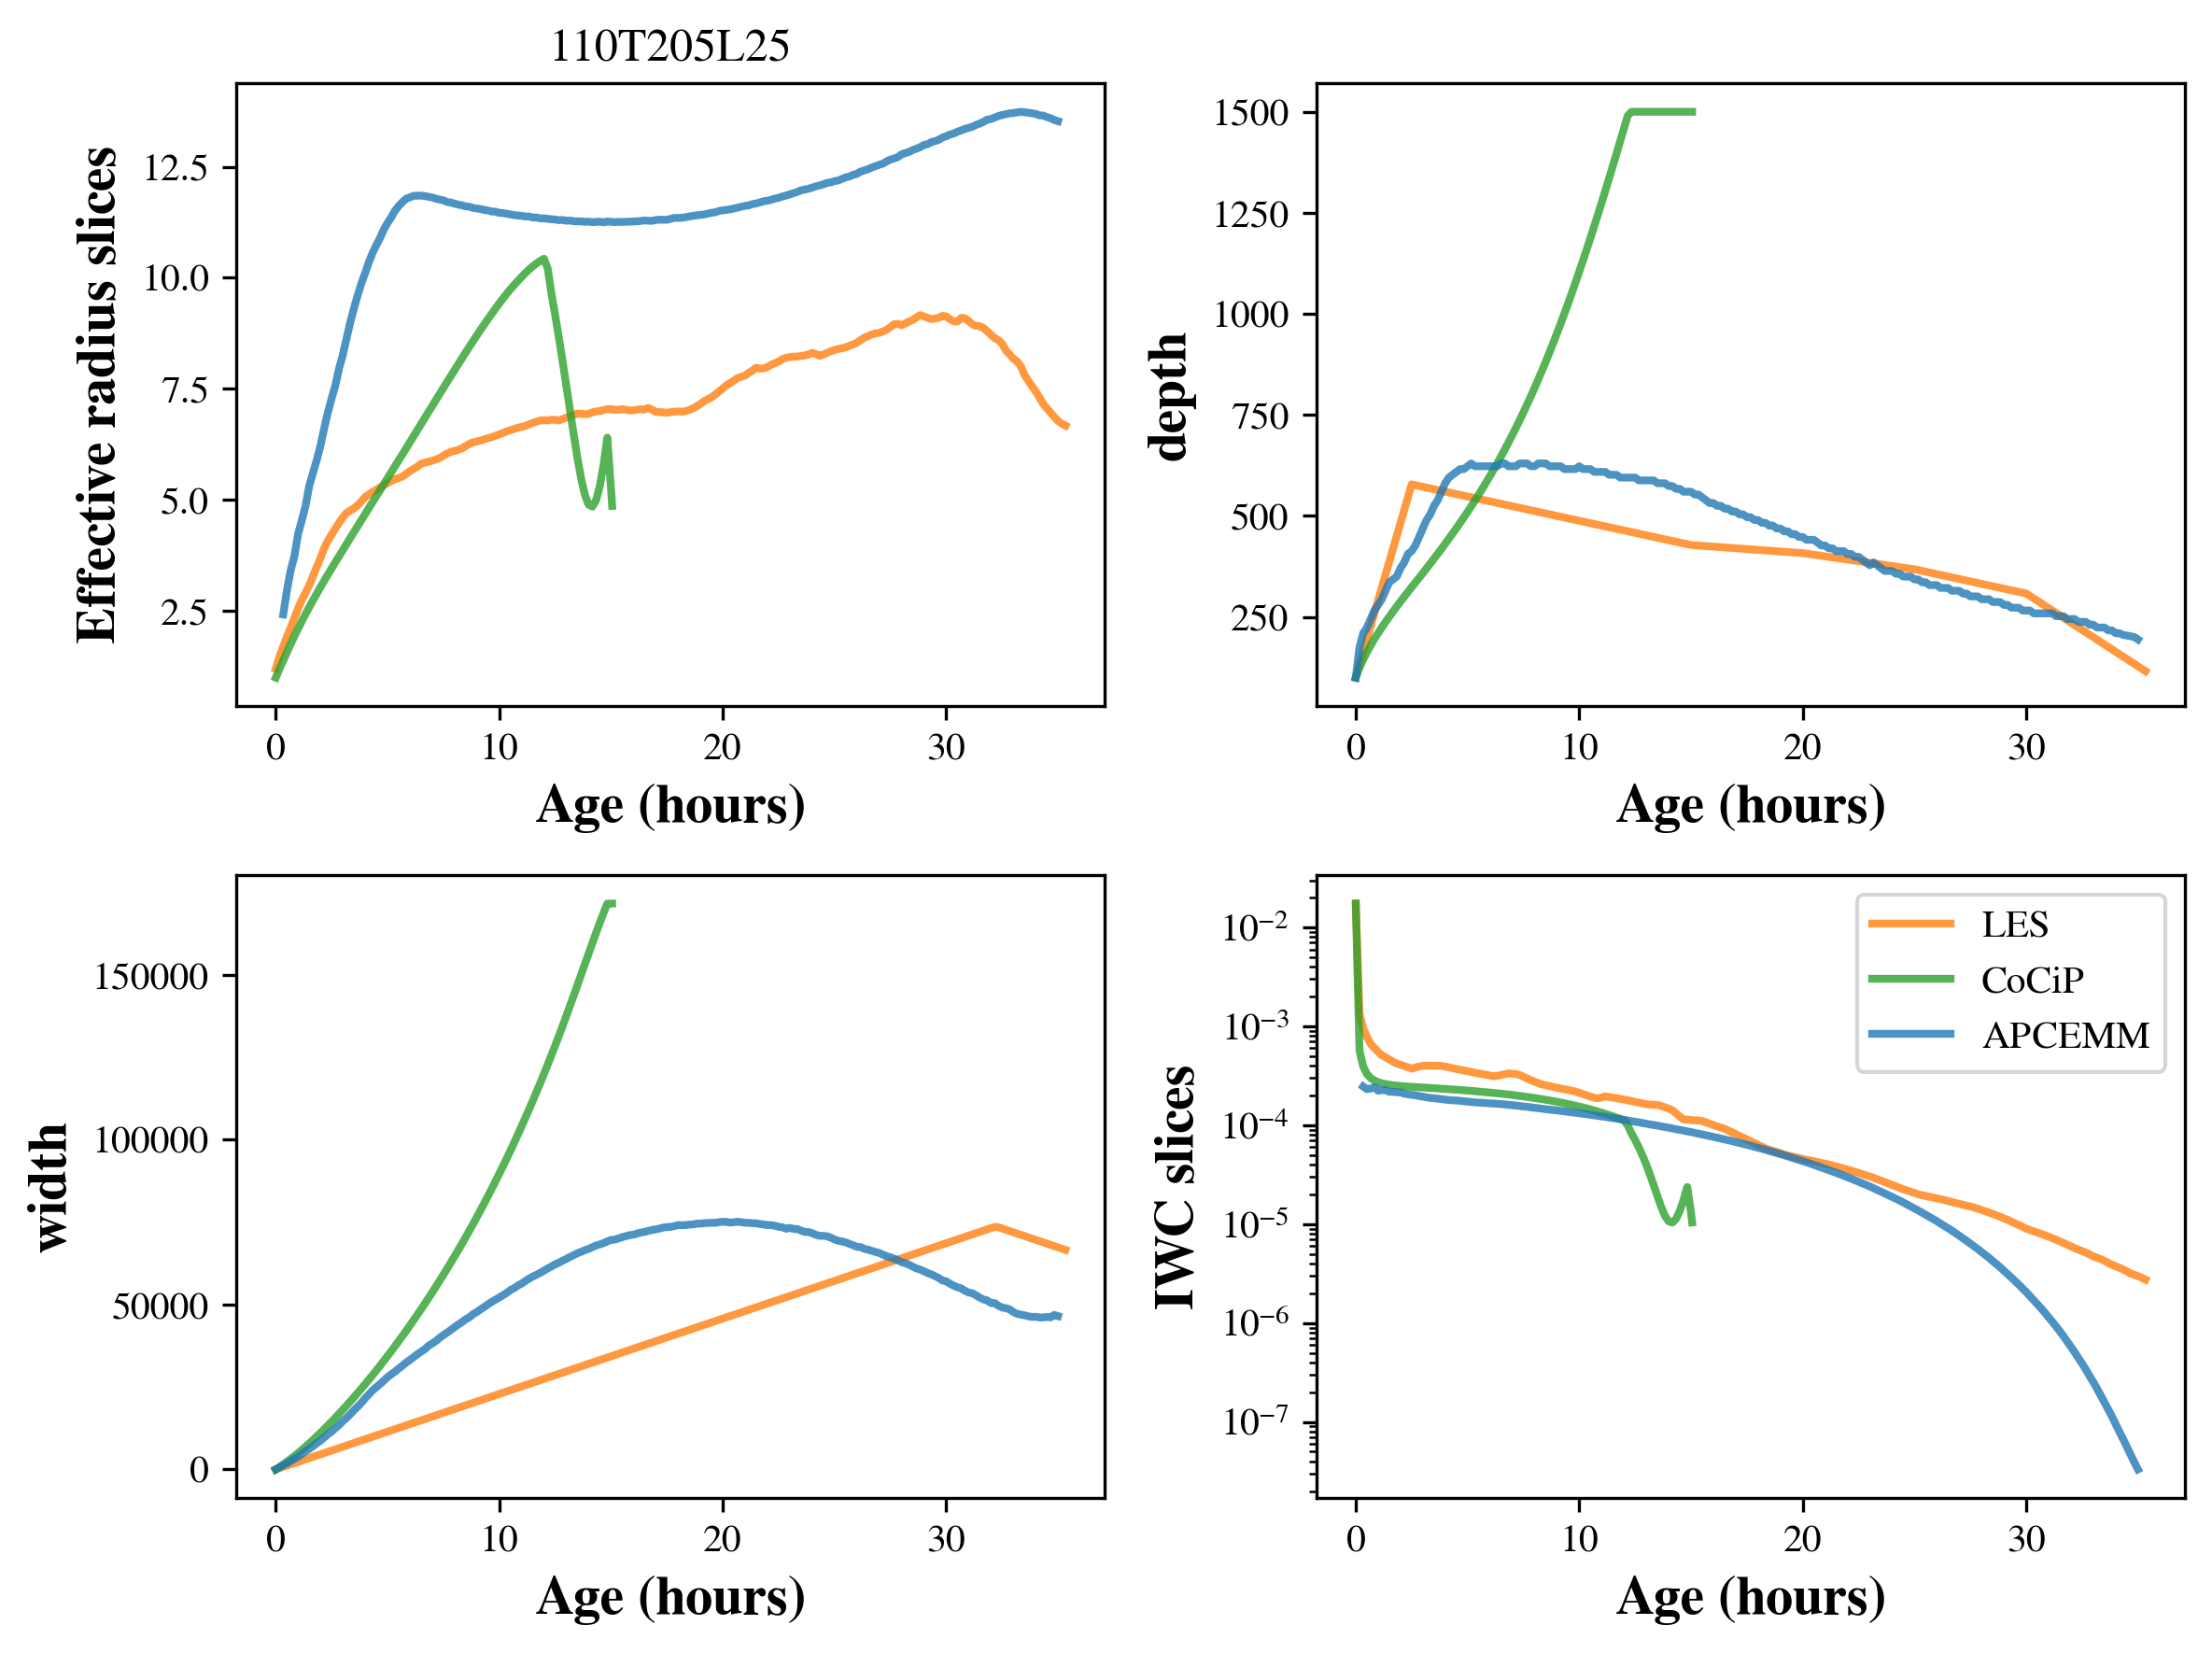

In [16]:
# Plot of average effective radius, depth, width, and ice water content vs age for the 110T205L25 case at noon, for APCEMM, for each habit, on a single plot with log y-axis and clear legend.
cases = ['110T205L25']
fig, axes = plt.subplots(2, 2, figsize=(8, 6), dpi=300)
habit = 'ghm' # Plotted data is habit independent
tod = '12' # Plotted data is time of day independent
models = ['LES', 'CoCiP', 'APCEMM']

LES_var_names = ['Effective_radius_um', 'Depth_m', 'Width_m', 'IWC_g_per_m3']
cocip_var_names = ['r_ice_vol', 'depth', 'width', 'iwc']
APCEMM_var_names = ['Effective radius slices', 'depth', 'width', 'IWC slices']  

for model in models:
    for case in cases:
        if model == 'APCEMM':
            ds = apcemm_data.get((case, int(tod), habit))
            time_name = 't'
            vars = APCEMM_var_names
        elif model == 'LES':
            ds = les_data.get((case, int(tod), habit))
            time_name = 'time'
            vars = LES_var_names
        elif model == 'CoCiP':
            ds = cocip_data.get((case, int(tod), habit))
            time_name = 'age_hours'
            vars = cocip_var_names
            
        for i, var in enumerate(vars):
            ax = axes[i//2, i%2]
        
            times = ds[time_name].values
            var_vals = ds[var].values.astype(float)
            if model == 'APCEMM' and var == 'Effective radius slices':
                var_vals = var_vals.mean(axis=1)
            if model == 'CoCiP' and var == 'r_ice_vol':
                var_vals = var_vals * 1e6
            if model == 'APCEMM' and var == 'IWC slices':
                var_vals = var_vals.mean(axis=1)
            if model == 'CoCiP' and var == 'iwc':
                var_vals = ds[var].values * ds["rho_air"].values * 1e3
            ax.plot(times, var_vals, label=model, lw=2,color=model_colors[model], alpha=0.8, linestyle=case_ls[case])
            ax.set_ylabel(var, fontsize=14, fontweight="bold")
            ax.set_xlabel("Age (hours)", fontsize=14, fontweight="bold")
        
        ax.legend()
axes[0,0].set_title(cases[0])
axes[1,1].set_yscale("log")

plt.tight_layout()
plt.show()

# Experimental Data

In [ ]:
def calculate_ACCRI_IWC(RHi, T):
    # T is in Kelvin
    # RHi is in %

    # Empirical fit based on ACCRI report data
    a = 1.1168
    b = 0.05592
    c = -0.0006265
    iwc = (RHi/100 -1)*np.exp(a + b*(T-273.15) + c*(T-273.15)**2)
    return iwc  # in g/m3

In [ ]:
cocip_data_130_225 = xr.open_dataset(f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T225L25/130T225L25-bypass_midnight.nc')
cocip_data_110_205 = xr.open_dataset(f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T205L25/110T205L25-bypass_midnight.nc')

apcemm_data_130_225 = lib.read_apcemm_data(
    f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/130T225L25/outputs',
)
apcemm_data_110_205 = lib.read_apcemm_data(
    f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/1000-bins-optimized/110T205L25/outputs',
)
apcemm_data_110_205 = apcemm_data_110_205.ds_t
apcemm_data_130_225 = apcemm_data_130_225.ds_t

SUCCESS_IWC_data = pd.read_csv('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/experimental_campaigns/SUCCESS/SUCCESS_IWC.csv')
CF_IWC_data = pd.read_csv('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/experimental_campaigns/CRYSTAL-FACE/CRYSTAL-FACE_IWC.csv')

LLES_data_130_225 = pd.read_csv(f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/processed_data/all_data/130T225L25.csv')
LLES_data_110_205 = pd.read_csv(f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/processed_data/all_data/110T205L25.csv')


LLES_times_130_225 = LLES_data_130_225['Time_hours'].values
LLES_times_110_205 = LLES_data_110_205['Time_hours'].values

LLES_IWC_130_225 = LLES_data_130_225['IWC_g_per_m3'].values
LLES_IWC_110_205 = LLES_data_110_205['IWC_g_per_m3'].values

cocip_times_130_225 = cocip_data_130_225['age_hours'].values
cocip_times_110_205 = cocip_data_110_205['age_hours'].values

cocip_IWC_130_225 = cocip_data_130_225['iwc'].values*cocip_data_130_225['rho_air'].values*1e3  # Convert from kg/m3 to g/m3
cocip_IWC_110_205 = cocip_data_110_205['iwc'].values*cocip_data_110_205['rho_air'].values*1e3  # Convert from kg/m3 to g/m3

cocip_temperature_130_225 = cocip_data_130_225['air_temperature'].values # [K]
cocip_temperature_110_205 = cocip_data_110_205['air_temperature'].values # [K]

radius_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/raw_data_from_plots/ice_crystal_radius/**/*.csv', recursive=True) # Import LES radius data
# Sort LES files for this scenario
les_psd_files = sorted(
    [f for f in radius_LES_csv if '130T225L25' in f],
    key=lambda x: int(re.search(r'_(\d+)min\.csv$', x).group(1))
)

### Import reported SUCCESS penetration means and errors

In [ ]:
SUCCESS_IWC_PEN1 = 0.0086 # g/m3
SUCCESS_IWC_PEN1_ERR = 0.00023 # g/m3
SUCCESS_TEMP_PEN1 = -50.2 + 273.15  # K

SUCCESS_IWC_PEN2 = 0.0074 # g/m3
SUCCESS_IWC_PEN2_ERR = 0.003 # g/m3
SUCCESS_TEMP_PEN2 = -48 + 273.15  # K

# SUCCESS mission ran from 0 min to 2 hours
SUCCESS_max_time = 2.0  # hours
# CRYSTAL-FACE mission ran from 0 min to 25 minutes (0.4167 hours)
CF_max_time = 0.4167*2  # hours

SUCCESS_IWC = SUCCESS_IWC_data['IWC [g/m3]'] # IWC in g/m3
SUCCESS_temperature = SUCCESS_IWC_data['Temperature [K]'] # Temperature in K

CF_IWC = CF_IWC_data['IWC [g/m3]'] # IWC in g/m3
CF_temperature = CF_IWC_data['Temperature [K]'] # Temperature in K

### Calculate APCEMM IWC and Temperature arrays

##### SUCCESS matched data: 130% 225K

In [ ]:
# Calculate APCEMM IWC from epm_bypass_data
num_timesteps_130_225 = len(apcemm_data_130_225)
APCEMM_times_130_225 = np.arange(num_timesteps_130_225) * 10 / 60  # time in hours

# Calculate total contrail volume (IWC > 1e-3 kg/m^3) for each timestep in epm_bypass_data[test_id]
total_volumes = np.zeros(num_timesteps_130_225) # [m3]
APCEMM_IWC_130_225 = np.zeros(num_timesteps_130_225) # [g/m3]
APCEMM_centroid_altitudes = np.full(num_timesteps_130_225, np.nan)
APCEMM_temperature_at_centroid_130_225 = np.full(num_timesteps_130_225, np.nan)

for i in range(num_timesteps_130_225):
    iwc_2d = apcemm_data_130_225[i]["IWC"].values * 1e3  # Convert to g/m^3
    num_conc_2d = apcemm_data_130_225[i]["Ice aerosol particle number"].values # Only compute IWC for cells with a concentration above the contrail threshold of 1e-4 #/m3

    x = apcemm_data_130_225[i]["x"].values
    y = apcemm_data_130_225[i]["y"].values
    dx = np.abs(x[1] - x[0]) if len(x) > 1 else 1.0
    dy = np.abs(y[1] - y[0]) if len(y) > 1 else 1.0

    mask = num_conc_2d > 1e-4 # True False mask
    masked_iwc = np.array(iwc_2d[mask])
    
    if masked_iwc.size == 0:
        APCEMM_IWC_130_225[i] = 0.0
        continue

    APCEMM_IWC_130_225[i] = np.mean(masked_iwc) # Take the mean of the values associated with True in the mask (1D array) # [g/m3]

    # Create mesh for coordinates matching iwc shape
    X_map, Y_map = np.meshgrid(x, y)

    # Mass per cell (IWC [kg/m3] * cell volume [m * m * 1 m depth])
    mass_cell = iwc_2d * dx * dy * 1.0
    total_mass = np.nansum(mass_cell)

    if total_mass > 0:
        # centroid altitude (mass-weighted)
        centroid_y = np.nansum(mass_cell * Y_map) / total_mass
        APCEMM_centroid_altitudes[i] = centroid_y

        # Determine temperature at centroid:
        T = apcemm_data_130_225[i]["Temperature"].values
        # mass-weighted average temperature (consistent with centroid computation)
        APCEMM_temperature_at_centroid_130_225[i] = np.nansum(T * mass_cell) / total_mass

# map each LLES time to nearest APCEMM time and pick the corresponding APCEMM temperature
idx_nearest = np.array([np.abs(APCEMM_times_130_225 - t).argmin() for t in LLES_times_130_225])
LLES_temperature_130_225 = APCEMM_temperature_at_centroid_130_225[idx_nearest]


In [ ]:
# Calculate APCEMM IWC from epm_bypass_data
num_timesteps_110_205 = len(apcemm_data_110_205)
APCEMM_times_110_205 = np.arange(num_timesteps_110_205) * 10 / 60  # time in hours

# Calculate total contrail volume (IWC > 1e-3 kg/m^3) for each timestep in epm_bypass_data[test_id]
total_volumes = np.zeros(num_timesteps_110_205) # [m3]
APCEMM_IWC_110_205 = np.zeros(num_timesteps_110_205) # [g/m3]
APCEMM_centroid_altitudes = np.full(num_timesteps_110_205, np.nan)
APCEMM_temperature_at_centroid_110_205 = np.full(num_timesteps_110_205, np.nan)

for i in range(num_timesteps_110_205):
    iwc_2d = apcemm_data_110_205[i]["IWC"].values * 1e3  # Convert to g/m^3
    num_conc_2d = apcemm_data_110_205[i]["Ice aerosol particle number"].values # Only compute IWC for cells with a concentration above the contrail threshold of 1e-4 #/m3

    x = apcemm_data_110_205[i]["x"].values
    y = apcemm_data_110_205[i]["y"].values
    dx = np.abs(x[1] - x[0]) if len(x) > 1 else 1.0
    dy = np.abs(y[1] - y[0]) if len(y) > 1 else 1.0

    mask = num_conc_2d > 1e-4 # True False mask
    masked_iwc = np.array(iwc_2d[mask])
    
    if masked_iwc.size == 0:
        APCEMM_IWC_110_205[i] = 0.0
        continue

    APCEMM_IWC_110_205[i] = np.mean(masked_iwc) # Take the mean of the values associated with True in the mask (1D array) # [g/m3]

    # Create mesh for coordinates matching iwc shape
    X_map, Y_map = np.meshgrid(x, y)

    # Mass per cell (IWC [kg/m3] * cell volume [m * m * 1 m depth])
    mass_cell = iwc_2d * dx * dy * 1.0
    total_mass = np.nansum(mass_cell)

    if total_mass > 0:
        # centroid altitude (mass-weighted)
        centroid_y = np.nansum(mass_cell * Y_map) / total_mass
        APCEMM_centroid_altitudes[i] = centroid_y

        # Determine temperature at centroid:
        T = apcemm_data_110_205[i]["Temperature"].values
        # mass-weighted average temperature (consistent with centroid computation)
        APCEMM_temperature_at_centroid_110_205[i] = np.nansum(T * mass_cell) / total_mass

# map each LLES time to nearest APCEMM time and pick the corresponding APCEMM temperature
idx_nearest = np.array([np.abs(APCEMM_times_110_205 - t).argmin() for t in LLES_times_110_205])
LLES_temperature_110_205 = APCEMM_temperature_at_centroid_110_205[idx_nearest]

##### SUCCESS matched data: 110% 205K

### Plot

In [ ]:
fig = plt.figure(figsize=(14, 6), dpi=300)
plt.rcParams.update({'font.size': 15})

RHi_110_label = '110'
RHi_130_label = '130'

# ── Layout: main plot left (2/3 width), two stacked subplots right (1/3 width) ──
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[2, 1],
    hspace=0.45,
    wspace=0.18,
    left=0.07, right=0.97,
    top=0.92, bottom=0.10,
)

ax1    = fig.add_subplot(gs[:, 0])   # main plot spans both rows
ax_cf  = fig.add_subplot(gs[0, 1])   # upper right: CRYSTAL-FACE (205–208 K)
ax_suc = fig.add_subplot(gs[1, 1])   # lower right: SUCCESS (225–230 K)

# ════════════════════════════════════════════════════════════════════════════════
# ── Main plot ────────────────────────────────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════

# SUCCESS 130% 225K
ax1.scatter(SUCCESS_temperature.values, SUCCESS_IWC.values,
            marker='o', label='SUCCESS 120%–140%', edgecolor='plum', s=14, facecolor='none')
ax1.scatter(cocip_temperature_130_225, cocip_IWC_130_225,
            marker='^', label=f'CoCiP {RHi_130_label}%', color='blue', s=5)
ax1.scatter(LLES_temperature_130_225, LLES_IWC_130_225,
            marker='^', label=f'LLES {RHi_130_label}%', color='green', s=5)
ax1.scatter(APCEMM_temperature_at_centroid_130_225, APCEMM_IWC_130_225,
            marker='^', label=f'APCEMM {RHi_130_label}%', color='red', s=5)

# CRYSTAL-FACE 110% 205K
ax1.scatter(CF_temperature.values, CF_IWC.values,
            marker='o', label='CRYSTAL-FACE', edgecolor='gold', s=14, facecolor='none')
ax1.scatter(cocip_temperature_110_205, cocip_IWC_110_205,
            marker='x', label=f'CoCiP {RHi_110_label}%', color='blue', s=5)
ax1.scatter(APCEMM_temperature_at_centroid_110_205, APCEMM_IWC_110_205,
            marker='x', label=f'APCEMM {RHi_110_label}%', color='red', s=5)
ax1.scatter(LLES_temperature_110_205, LLES_IWC_110_205,
            marker='^', label=f'LLES {RHi_110_label}%', color='green', s=5)

# ax1.errorbar(SUCCESS_TEMP_PEN1, SUCCESS_IWC_PEN1, yerr=SUCCESS_IWC_PEN1_ERR,
#              marker='D', label='SUCCESS Mean IWC for PEN1',
#              color='darkblue', capsize=5)
# ax1.errorbar(SUCCESS_TEMP_PEN2, SUCCESS_IWC_PEN2, yerr=SUCCESS_IWC_PEN2_ERR,
#              marker='D', label='SUCCESS Mean IWC for PEN2',
#              color='pink', capsize=5)

# shaded bands showing the zoom regions
ax1.axvspan(205, 208, color='gold',  alpha=0.10, zorder=0)
ax1.axvspan(225, 230, color='plum',  alpha=0.10, zorder=0)

# ax1.set_title("IWC Reported from Experimental Campaigns")
ax1.set_xlim(195, 245)
ax1.set_ylim(1e-5, 4e-1)
ax1.set_yscale('log')
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('IWC [g m$^{-3}$]')
# ax1.legend(ncol=1, fontsize=14, loc='lower right')

# ════════════════════════════════════════════════════════════════════════════════
# ── Upper right: CRYSTAL-FACE range  205–208 K ───────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════

T_lo_cf, T_hi_cf = 205, 207

ax_cf.scatter(CF_temperature.values, CF_IWC.values,
              marker='o', edgecolor='gold', s=18, facecolor='none', zorder=3)
ax_cf.scatter(cocip_temperature_110_205, cocip_IWC_110_205,
              marker='x', color='blue', s=12, zorder=3)
ax_cf.scatter(APCEMM_temperature_at_centroid_110_205, APCEMM_IWC_110_205,
              marker='x', color='red', s=12, zorder=3)
ax_cf.scatter(LLES_temperature_110_205, LLES_IWC_110_205,
              marker='x', color='green', s=12, zorder=3)

ax_cf.set_xlim(T_lo_cf, T_hi_cf)
ax_cf.set_ylim(1e-5, 4e-1)
ax_cf.set_yscale('log')
# ax_cf.set_xlabel('Temperature [K]', fontsize=14)
ax_cf.set_ylabel('IWC [g m$^{-3}$]', fontsize=14)
ax_cf.set_title(f'CRYSTAL-FACE', fontsize=14)
ax_cf.tick_params(labelsize=14)
ax_cf.set_facecolor('#fffdf0')   # faint gold tint to match band


# ════════════════════════════════════════════════════════════════════════════════
# ── Lower right: SUCCESS range  225–230 K ────────────────────────────────────
# ════════════════════════════════════════════════════════════════════════════════

T_lo_suc, T_hi_suc = 225, 228

ax_suc.scatter(SUCCESS_temperature.values, SUCCESS_IWC.values,
               marker='o', edgecolor='plum', s=18, facecolor='none', zorder=3)
ax_suc.scatter(cocip_temperature_130_225, cocip_IWC_130_225,
               marker='^', color='blue', s=12, zorder=3)
ax_suc.scatter(LLES_temperature_130_225, LLES_IWC_130_225,
               marker='^', color='green', s=12, zorder=3)
ax_suc.scatter(APCEMM_temperature_at_centroid_130_225, APCEMM_IWC_130_225,
               marker='^', color='red', s=12, zorder=3)
# ax_suc.errorbar(SUCCESS_TEMP_PEN1, SUCCESS_IWC_PEN1, yerr=SUCCESS_IWC_PEN1_ERR,
#                 marker='D', color='darkblue', capsize=4, ms=5)
# ax_suc.errorbar(SUCCESS_TEMP_PEN2, SUCCESS_IWC_PEN2, yerr=SUCCESS_IWC_PEN2_ERR,
#                 marker='D', color='pink', capsize=4, ms=5)

ax_suc.set_xlim(T_lo_suc, T_hi_suc)
ax_suc.set_ylim(1e-5, 4e-1)
ax_suc.set_yscale('log')
ax_suc.set_xlabel('Temperature [K]', fontsize=14)
ax_suc.set_ylabel('IWC [g m$^{-3}$]', fontsize=14)
ax_suc.set_title(f'SUCCESS', fontsize=14)
ax_suc.tick_params(labelsize=14)
ax_suc.set_facecolor('#fff5ff')   # faint plum tint to match band

fig.show()

## PSD

### Import and organize data

In [ ]:
def removeLow(arr, cutoff = 1e-3):
    func = lambda x: (x > cutoff) * x
    vfunc = np.vectorize(func)
    return vfunc(arr)

In [ ]:
# Calculate APCEMM IWC from epm_bypass_data
APCEMM_num_timesteps_130_225 = len(apcemm_data_130_225)
APCEMM_times_130_225 = np.arange(APCEMM_num_timesteps_130_225) * 10 / 60  # time in hours

# Get the contrail area and number density for each timestep in epm_bypass_data[test_id]
APCEMM_area_130_225 = np.zeros(APCEMM_num_timesteps_130_225) # [m2]
APCEMM_num_130_225 = np.zeros(APCEMM_num_timesteps_130_225) # [#/m2]

for i in range(APCEMM_num_timesteps_130_225):
    iwc_2d = apcemm_data_130_225[i]["IWC"].values * 1e3  # Convert to g/m^3
    x = apcemm_data_130_225[i]["x"].values
    y = apcemm_data_130_225[i]["y"].values
    dx = np.abs(x[1] - x[0]) if len(x) > 1 else 1.0
    dy = np.abs(y[1] - y[0]) if len(y) > 1 else 1.0

    # Mask cells where IWC > 1e-4 (handles NaNs)
    valid_cells = (~np.isnan(iwc_2d)) & (iwc_2d > 1e-4)
    APCEMM_area_130_225[i] = np.count_nonzero(valid_cells) * dx * dy
    APCEMM_num_130_225[i] = apcemm_data_130_225[i]["Number Ice Particles"]  # [#/m]
    
# Import the CoCiP data
cocip_area_130_225 = cocip_data_130_225['area_eff'].values  # [m2]
cocip_num_130_225 = cocip_data_130_225['n_ice_per_m'].values  # [#/m3]
cocip_num_timesteps_130_225 = len(cocip_times_130_225)

# Import the PSD from the SUCCESS campaign
SUCCESS_PSD_30min = pd.read_csv('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/experimental_campaigns/SUCCESS/SUCCESS_PSD_Fig11b.csv')

SUCCESS_PSD_30min_conc = SUCCESS_PSD_30min['Conc [cm-3 miu-1]'].values # [cm-3 micron-1] Number of crystals per volume per radii
SUCCESS_PSD_30min_D = SUCCESS_PSD_30min['D [micron]'].values # [micron] Diameter

# Bin the PSD data by sorting the concentration points into diameter bins and taking the mean concentration in each bin
bin_edges = np.array([1, 1.02, 2.17, 4.42, 8.38, 14.01]) # microns
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
SUCCESS_PSD_30min_conc_binned = np.zeros(len(bin_centers))
for i in range(len(bin_centers)):
    in_bin = (SUCCESS_PSD_30min_D >= bin_edges[i]) & (SUCCESS_PSD_30min_D < bin_edges[i+1])
    if np.any(in_bin):
        SUCCESS_PSD_30min_conc_binned[i] = np.mean(SUCCESS_PSD_30min_conc[in_bin])
    else:
        SUCCESS_PSD_30min_conc_binned[i] = 0.0

SUCCESS_30min_area = APCEMM_area_130_225[3]  # m2 at 30 min
SUCCESS_PSD_30min_logr_binned = SUCCESS_PSD_30min_conc_binned * 1e6 * SUCCESS_30min_area * np.log(10) * bin_centers/2  # Get dN/dlog(r) [#/m/micron]

SUCCESS_PSD_100min = pd.read_csv('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/experimental_campaigns/SUCCESS/SUCCESS_PSD_Fig11c.csv')
SUCCESS_PSD_100min_conc = SUCCESS_PSD_100min['Conc [cm-3 miu-1]'].values # [cm-3 micron-1] Number of crystals per volume per radii
SUCCESS_PSD_100min_D = SUCCESS_PSD_100min['D [micron]'].values # [micron] Diameter

# Bin the PSD data by sorting the concentration points into diameter bins and taking the mean concentration in each bin
SUCCESS_PSD_100min_conc_binned = np.zeros(len(bin_centers))
for i in range(len(bin_centers)):
    in_bin = (SUCCESS_PSD_100min_D >= bin_edges[i]) & (SUCCESS_PSD_100min_D < bin_edges[i+1])
    if np.any(in_bin):
        SUCCESS_PSD_100min_conc_binned[i] = np.mean(SUCCESS_PSD_100min_conc[in_bin])
    else:
        SUCCESS_PSD_100min_conc_binned[i] = 0.0

SUCCESS_100min_area = APCEMM_area_130_225[6]  # m2 at 100 min

SUCCESS_PSD_100min_logr_binned = SUCCESS_PSD_100min_conc_binned * 1e6 * SUCCESS_100min_area * np.log(10) * bin_centers/2  # Get dN/dlog(r) [#/m/micron]


### Plot

In [ ]:
# Plot only the 30 and 90 minute subplots
selected_minutes = [30, 90]
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300, sharey=True)
axes = axes.flatten()
plt.rcParams.update({'font.size': 15})

cocip_ds = cocip_data_130_225
RHi = 130
scaling = None  # will set from the first LES we plot (30 min)
legend = False

for ax, t_min in zip(axes, selected_minutes):
    ax.set_xlim(5e-2,101)
    idx_apcemm = int(t_min / 10)
    t_hr = t_min / 60.0

    # APCEMM
    ds = apcemm_data_130_225[idx_apcemm]
    r_um = ds['r'].values * 1e6
    size_dist = removeLow(ds["Overall size distribution"].values, cutoff=1e-6)
    ax.plot(r_um, size_dist, label="APCEMM", color='blue', lw=2)

    # LES (find file for this minute)
    les_file = next((f for f in les_psd_files if f.endswith(f'_{t_min}min.csv')), None)
    if les_file is not None:
        df = pd.read_csv(les_file, header=None)
        if scaling is None:
            scaling = size_dist.max() / df.iloc[:, 1].max()
        ax.plot(df.iloc[:, 0], scaling * df.iloc[:, 1], label="LES", color='orange', lw=2)

    if t_min == 30:
        cocip_r = 3.6
        cocip_n = 1.4e12
    elif t_min == 90:
        cocip_r = 7.5
        cocip_n = 1e12

    ax.plot(cocip_r, cocip_n, marker='o', color='green', label='CoCiP', linestyle='None')


    if t_min == 30:
        ax.hist(
            bin_centers/2,
            bins=bin_edges/2,
            weights=SUCCESS_PSD_30min_logr_binned,
            histtype='step',
            color='purple',
            linewidth=1.8,
            label='SUCCESS'
        )
        ax.axvspan(ax.get_xlim()[0], 0.5, color='gray', alpha=0.15, zorder=0)
        ax.axvspan(7, ax.get_xlim()[1], color='gray', alpha=0.15, zorder=0)

    if t_min == 90:
        if 'SUCCESS_PSD_100min_D' in globals():
            ax.hist(
                bin_centers/2,
                bins=bin_edges/2,
                weights=SUCCESS_PSD_100min_logr_binned,
                histtype='step',
                color='purple',
                linewidth=2,
                label='SUCCESS'
            )
        ax.axvspan(ax.get_xlim()[0], 0.51, color='gray', alpha=0.15, zorder=0)
        ax.axvspan(7, ax.get_xlim()[1], color='gray', alpha=0.15, zorder=0)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e6, 9e13)
    ax.set_xlabel('Radius [$\\mu$m]')
    ax.set_title(f'Contrail Age = {t_min} min')
    if ax is axes[0]:
        ax.set_ylabel(r'$\frac{dN(t)}{d\log(r)}$ [m$^{-1}$]')
    handles, labels = ax.get_legend_handles_labels()
    if 'SUCCESS' in labels:
        success_idx = labels.index('SUCCESS')
        handles[success_idx] = plt.Line2D([0], [0], color='purple', lw=2)
    if not legend:
        ax.legend(handles, labels)
        legend = True

plt.suptitle(f'Ice Crystal Radius Distribution \n RH$_i$ = {RHi}% T = {temp}K')
plt.tight_layout()
plt.show()
